# Template 07: SHAP Analysis

**Purpose:** Generate residual + SHAP range plots for top features

**Inputs:**
- results/06_shap_train.parquet
- results/06_shap_test.parquet
- results/05c_predictions_train.parquet
- results/05c_predictions_test.parquet
- data/04c_train_encoded.parquet
- data/04c_test_encoded.parquet

**Outputs:**
- plots/{dataset}_{feature}_residual.png
- plots/{dataset}_{feature}_shap_range.png
- results/07_analysis_summary.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_liab/v1"


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yaml
import os
import sys
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from shap_utils import compute_shap_aggregate, create_residual_plot, create_shap_range_plot

print("########################################")
print("# STAGE 07: SHAP ANALYSIS")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 07: SHAP ANALYSIS
########################################


In [4]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

with open(f"{config_path}/config.yaml") as f:
    cfg = yaml.safe_load(f)
output_base = cfg["machines"][pc_id]["paths"]["output_path"]
shap_cfg = cfg.get("shap_analysis", {})
top_n = shap_cfg.get("top_n_features", 40)
datasets = shap_cfg.get("datasets", ["train", "test"])
resid_cfg = shap_cfg.get("residual_plot", {})
shap_range_cfg = shap_cfg.get("shap_range_plot", {})
print(f"\nConfig: top_n={top_n}")


Config: top_n=40


In [5]:
plots_dir = f"{output_base}/plots"
os.makedirs(plots_dir, exist_ok=True)
print(f"Plots: {plots_dir}")

Plots: output/car_liab/v1/plots


In [6]:
# Load ENCODED data (same data used for SHAP computation)
df_train = pd.read_parquet(f"{output_base}/data/04c_train_encoded.parquet")
df_test = pd.read_parquet(f"{output_base}/data/04c_test_encoded.parquet")

print(f"\n* Train encoded: {df_train.shape}")
print(f"* Test encoded: {df_test.shape}")


* Train encoded: (18709834, 200)
* Test encoded: (7483698, 200)


In [7]:
print("\nLoading...")
shap_train = pd.read_parquet(f"{output_base}/results/06_shap_train.parquet")
shap_test = pd.read_parquet(f"{output_base}/results/06_shap_test.parquet")
preds_train = pd.read_parquet(f"{output_base}/results/05c_predictions_train.parquet")
preds_test = pd.read_parquet(f"{output_base}/results/05c_predictions_test.parquet")

print(f"  SHAP train: {shap_train.shape}")
print(f"  SHAP test: {shap_test.shape}")
print(f"  Preds train: {preds_train.shape}")
print(f"  Preds test: {preds_test.shape}")


Loading...


  SHAP train: (10000, 201)
  SHAP test: (7483698, 201)
  Preds train: (18709834, 3)
  Preds test: (7483698, 3)


In [8]:
# Merge train data with predictions
# Use intersection of indices (SHAP is computed on sample)
common_idx = shap_train.index.intersection(preds_train.index)
data_tr = df_train.loc[common_idx].copy()
data_tr['actual'] = preds_train.loc[common_idx, 'actual']
data_tr['pred'] = preds_train.loc[common_idx, 'pred']
data_tr['weight'] = preds_train.loc[common_idx, 'exposure']

fc_tr = shap_train.loc[common_idx].copy()
fc_tr['weight'] = data_tr['weight']
out_tr = data_tr
print(f"Train: {out_tr.shape}")

Train: (7091, 203)


In [9]:
# Merge test data with predictions
# Use intersection of indices
common_idx = shap_test.index.intersection(preds_test.index)
data_te = df_test.loc[common_idx].copy()
data_te['actual'] = preds_test.loc[common_idx, 'actual']
data_te['pred'] = preds_test.loc[common_idx, 'pred']
data_te['weight'] = preds_test.loc[common_idx, 'exposure']

fc_te = shap_test.loc[common_idx].copy()
fc_te['weight'] = data_te['weight']
out_te = data_te
print(f"Test: {out_te.shape}")

Test: (2135604, 203)


In [10]:
print("\nSHAP aggregates...")
shagg, shagg_num, shagg2 = compute_shap_aggregate(fc_tr, weight_col="weight")
print(f"Features: {len(shagg2)}")
print(shagg2.head(10))


SHAP aggregates...
Features: 79
                        field   total_shap
48                 ee_bi_imps  2078.008034
54    cef_first_poten_dam_ind   651.351022
6                 married_ind   484.821303
51   cef_est_curr_mi_grp_imps   319.422333
4       multi_pol_unknown_cal   279.984132
92     vc_backup_camera_raw_0   273.175164
3           multi_pol_yes_cal   215.145449
159       vc_rear_wiper_raw_0   213.403781
56        cef_lien_holder_ind   163.976999
104              vc_doors_raw   134.567507


In [11]:
features = shagg2["field"].head(top_n).tolist()
print(f"\nPlotting {len(features)} features")


Plotting 40 features


In [12]:
summary = {"timestamp": datetime.now().isoformat(), "plots": 0}
plots_by_feature = {}

In [13]:
print("="*60)
print("GENERATING PLOTS")
print("="*60)
for i, f in enumerate(features, 1):
    print(f"[{i}/{len(features)}] {f}")
    plots_by_feature[f] = []
    if f not in out_tr.columns or f not in out_te.columns:
        print(f"  WARNING: Feature {f} not found, skipping")
        continue
    if "train" in datasets:
        try:
            fig, _ = create_residual_plot(out_tr, f, "weight", dataset_label="Train", **resid_cfg)
            path = f"{plots_dir}/train_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_tr, data_tr, f, "weight", dataset_label="Train", **shap_range_cfg)
            path = f"{plots_dir}/train_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train SHAP): {e}")
    if "test" in datasets:
        try:
            fig, _ = create_residual_plot(out_te, f, "weight", dataset_label="Test", **resid_cfg)
            path = f"{plots_dir}/test_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_te, data_te, f, "weight", dataset_label="Test", **shap_range_cfg)
            path = f"{plots_dir}/test_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test SHAP): {e}")
print(f"\n[OK] Generated summary")

GENERATING PLOTS
[1/40] ee_bi_imps

ee_bi_imps Summary:
   ee_bi_imps      weight    act_rate  pred_rate
(-0.001, 0.1]  515.745872    0.000000 353.384221
  (0.1, 0.21]  103.464661    0.000000 395.492564
 (0.21, 0.33]   92.133767    0.000000 453.878998
(0.33, 0.434]   61.532562    0.000000 276.335809
 (0.434, 0.5] 1949.943274  458.615547 386.883242
  (0.5, 0.56]   25.224373    0.000000 293.170168
  (0.56, 0.8]   72.295157    0.000000 367.739532
  (0.8, 0.99]  282.865656 4652.106130 360.092843
  (0.99, 1.0] 1253.643596  151.328102 365.371437
  (1.0, 1.68]    1.779916    0.000000 699.136741


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

  ERROR (Train SHAP): cannot reindex on an axis with duplicate labels

ee_bi_imps Summary:
    ee_bi_imps        weight    act_rate  pred_rate
(-0.001, 0.15] 158138.885306  287.707129 385.179622
  (0.15, 0.22]  20890.009350  228.465248 382.706483
  (0.22, 0.27]  14462.018774  329.494101 385.862139
  (0.27, 0.32]  10541.559937  499.962132 378.490591
  (0.32, 0.36]   7995.186533  211.650189 382.872618
   (0.36, 0.4]   8920.801377  502.180050 378.940003
   (0.4, 0.44]   7229.500823  364.394960 382.527483
  (0.44, 0.47]   7869.478090  293.908705 382.191133
   (0.47, 0.5] 579885.929561  407.158027 385.498824
   (0.5, 0.55]   5968.480478  206.395291 392.059128
  (0.55, 0.62]   7177.212029  491.291043 374.961334
  (0.62, 0.68]   2655.344277  381.070864 387.672447
  (0.68, 0.74]   6362.908047 1947.567792 390.718321
  (0.74, 0.79]   5536.151329  352.441415 375.995706
  (0.79, 0.84]   2402.866824  261.277531 408.188040
  (0.84, 0.88]   4638.734314  172.466994 372.795737
  (0.88, 0.92]   3256.474

/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

...

  ERROR (Test SHAP): cannot reindex on an axis with duplicate labels
[39/40] vc_camera_raw_5

vc_camera_raw_5 Summary:
 vc_camera_raw_5      weight   act_rate  pred_rate
             0.0 2533.106864 787.724529 375.528521
             1.0 1825.521970 221.589471 372.645440
  ERROR (Train SHAP): cannot reindex on an axis with duplicate labels

vc_camera_raw_5 Summary:
 vc_camera_raw_5        weight   act_rate  pred_rate
             0.0 773813.176615 412.357656 384.813504
             1.0 528560.275754 433.044418 385.221685


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

  ERROR (Test SHAP): 'c' argument has 182 elements, which is inconsistent with 'x' and 'y' with size 180.
[40/40] vc_surround_sound_raw_3

vc_surround_sound_raw_3 Summary:
 vc_surround_sound_raw_3      weight   act_rate  pred_rate
                     0.0 4063.723355 579.671756 375.279668
                     1.0  294.905479 150.153892 361.110512
  ERROR (Train SHAP): cannot reindex on an axis with duplicate labels


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


vc_surround_sound_raw_3 Summary:
 vc_surround_sound_raw_3       weight   act_rate  pred_rate
                     0.0 1.219213e+06 419.683013 384.833289
                     1.0 8.316067e+04 436.443945 387.117888
  ERROR (Test SHAP): cannot reindex on an axis with duplicate labels

[OK] Generated summary



DISPLAYING ALL PLOTS

FEATURE: ee_bi_imps


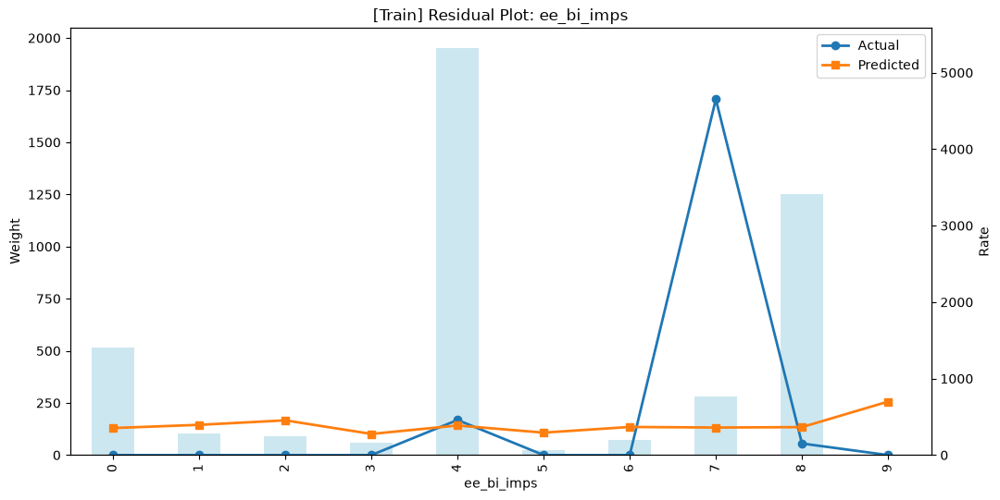

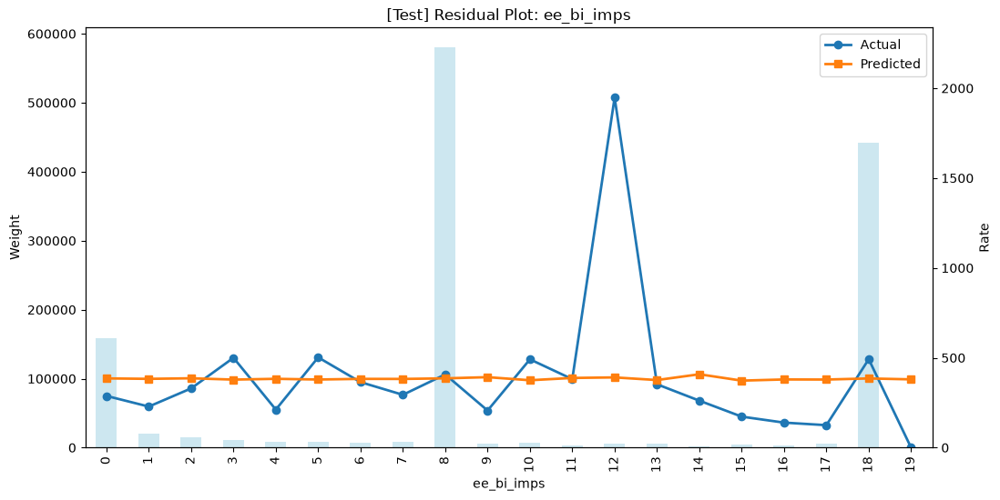


FEATURE: cef_first_poten_dam_ind


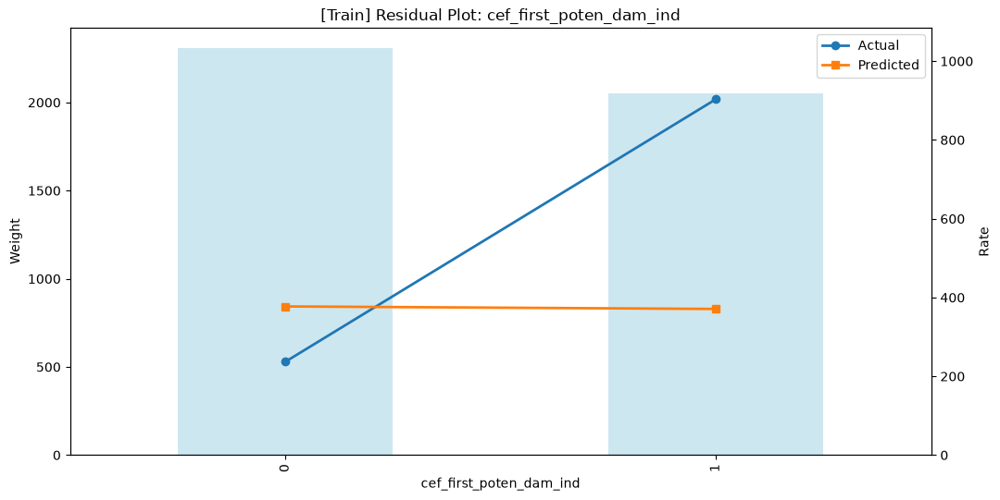

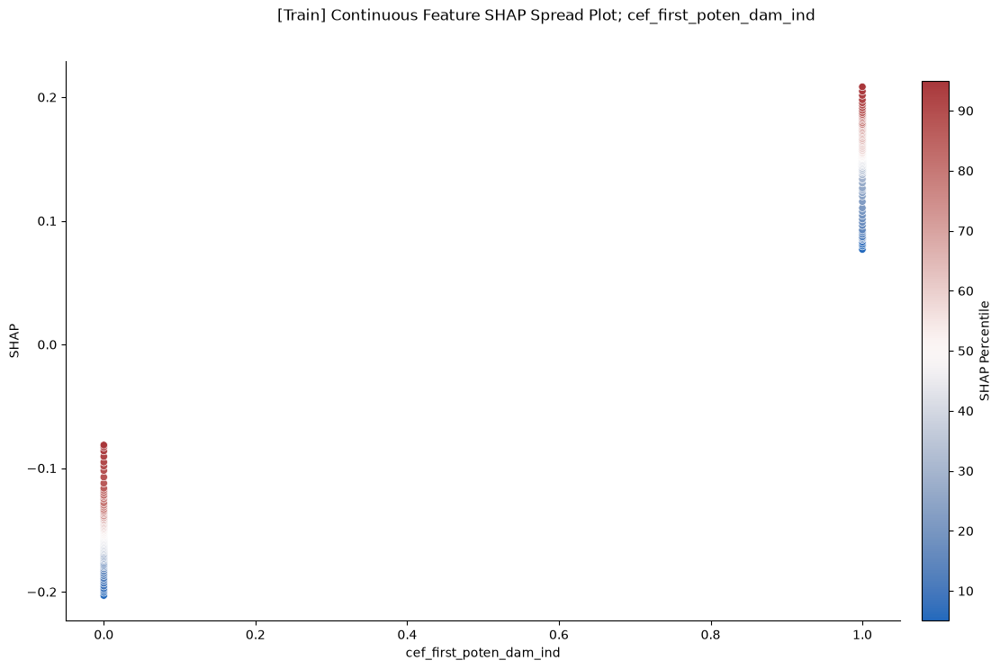

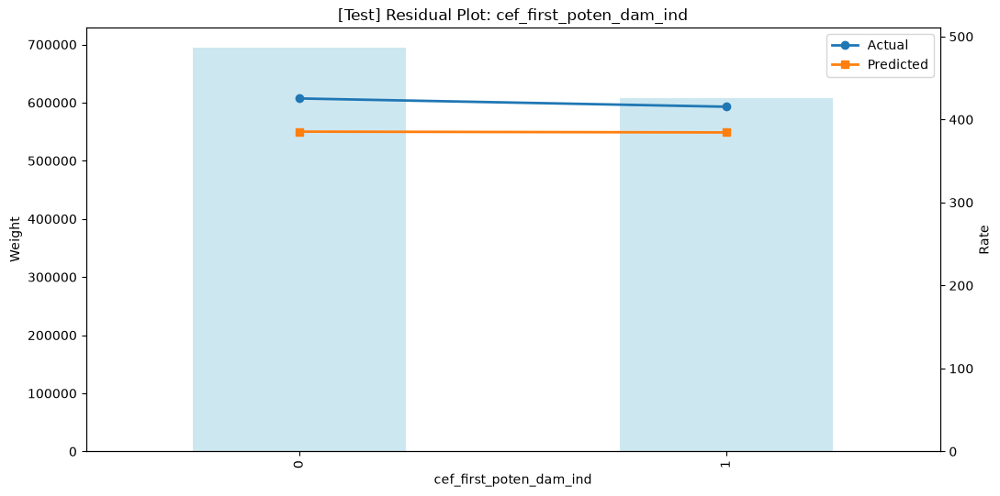

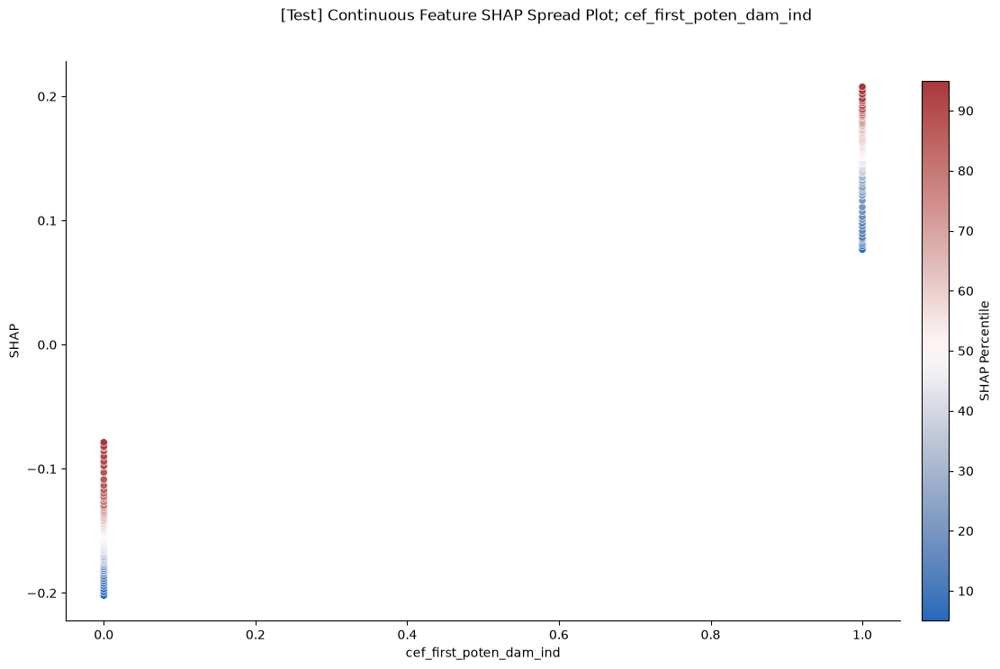


FEATURE: married_ind


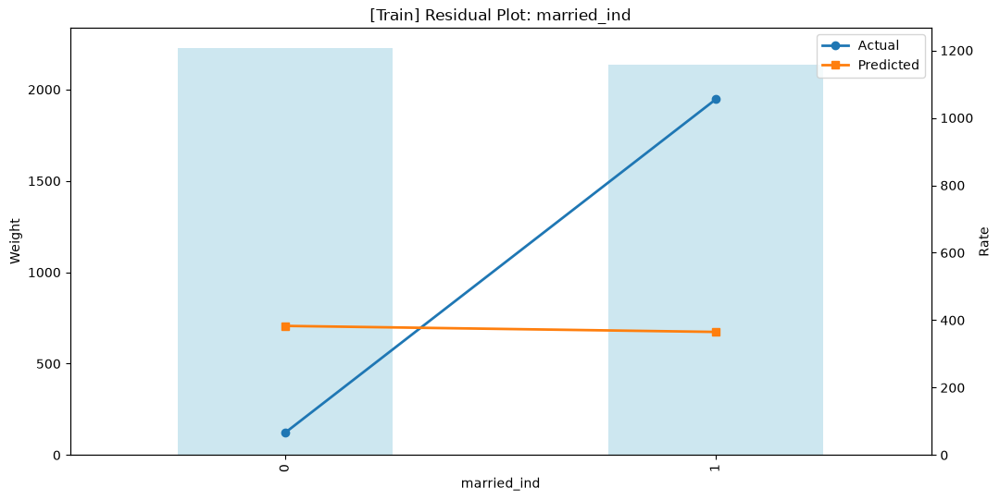

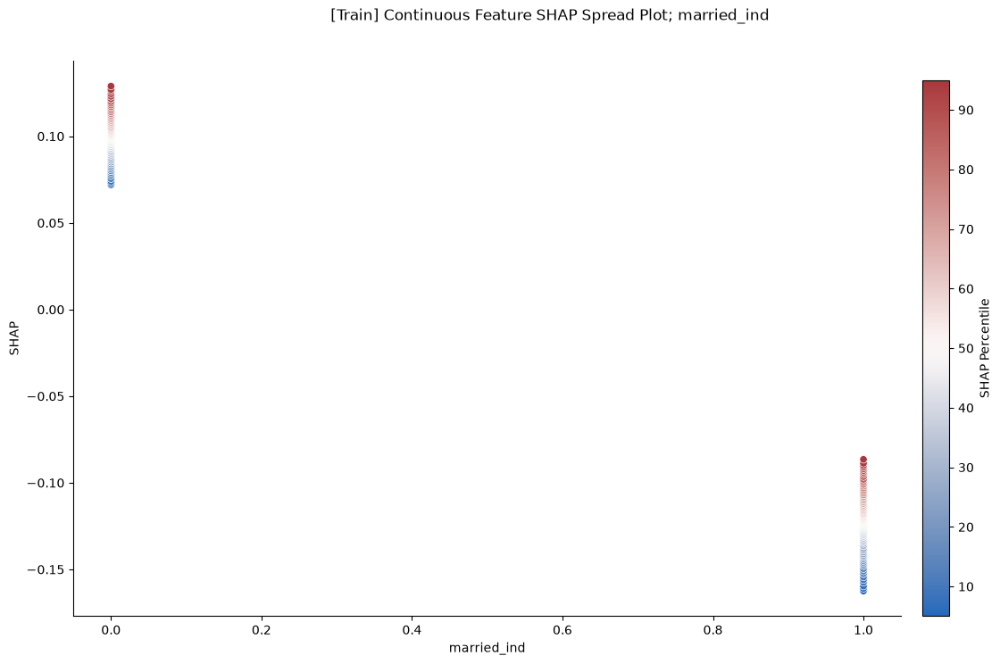

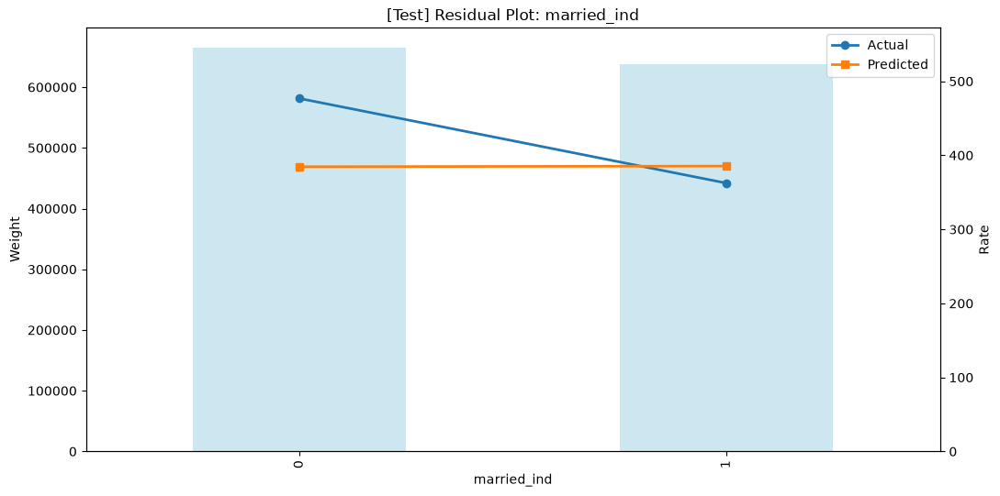

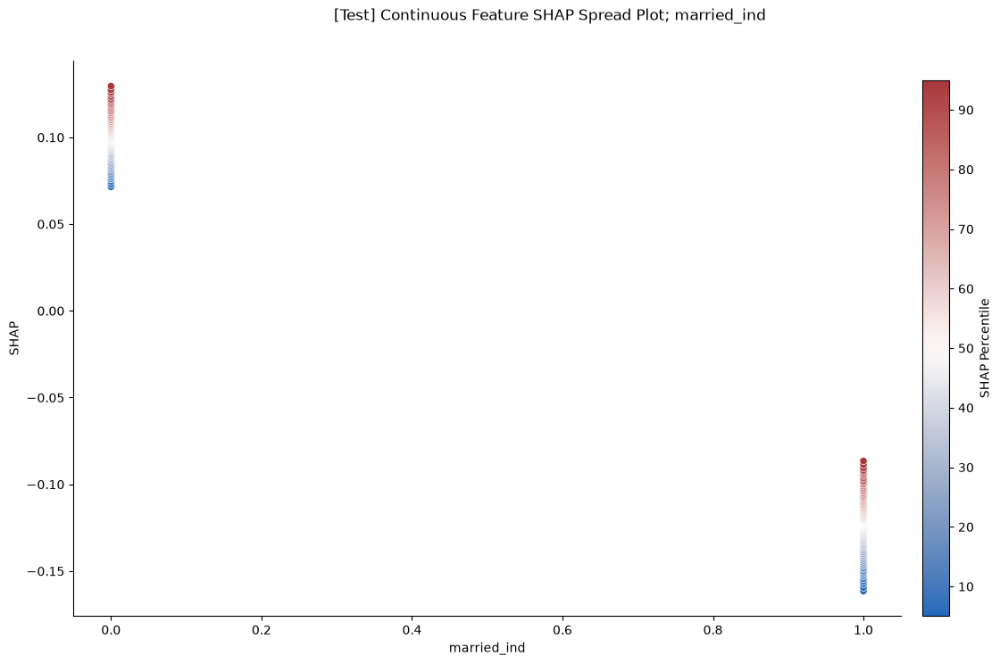


FEATURE: cef_est_curr_mi_grp_imps


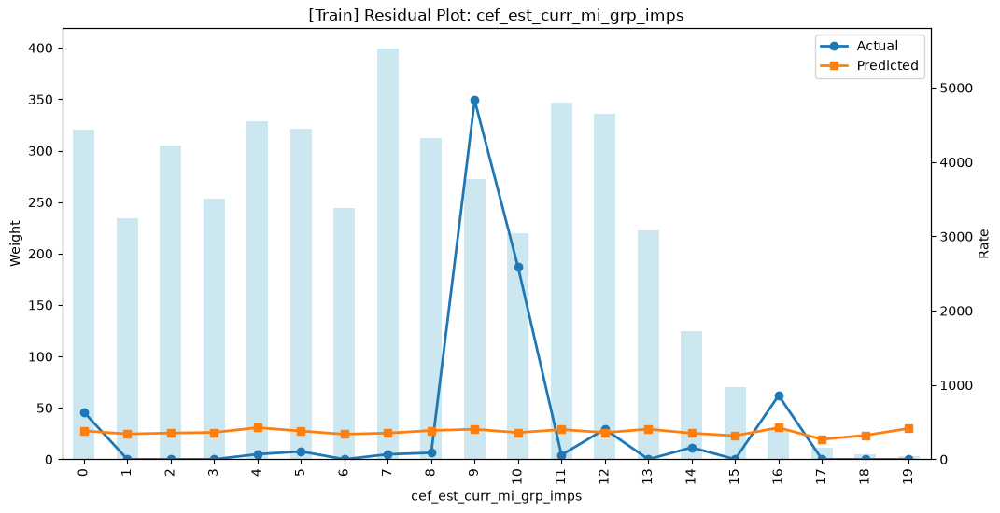

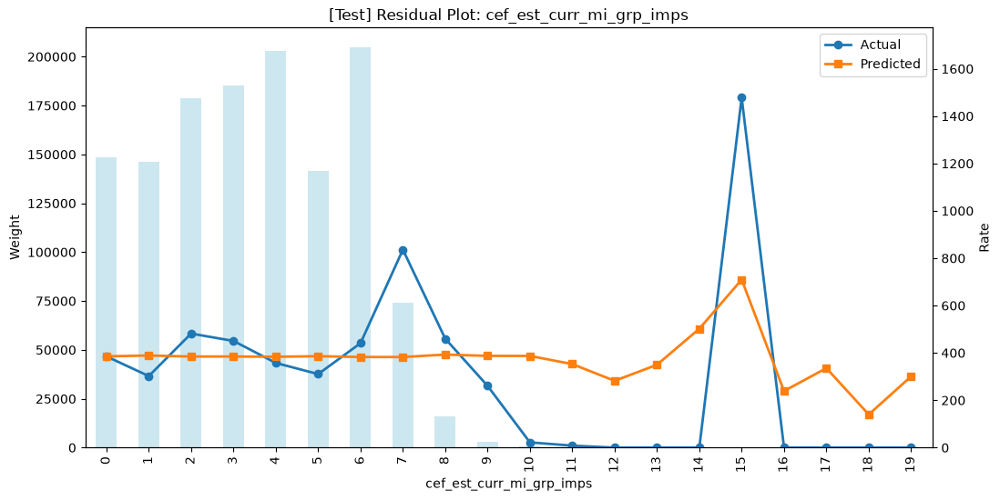


FEATURE: multi_pol_unknown_cal


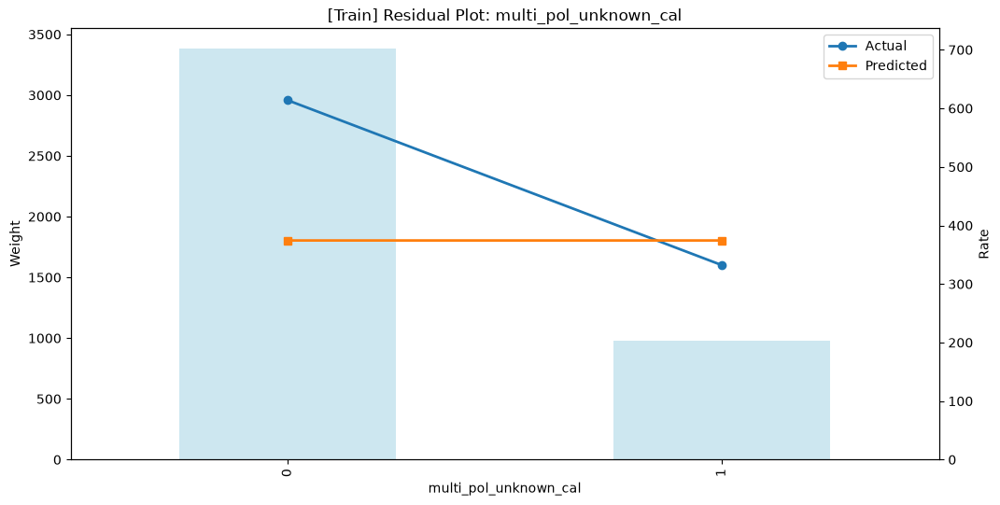

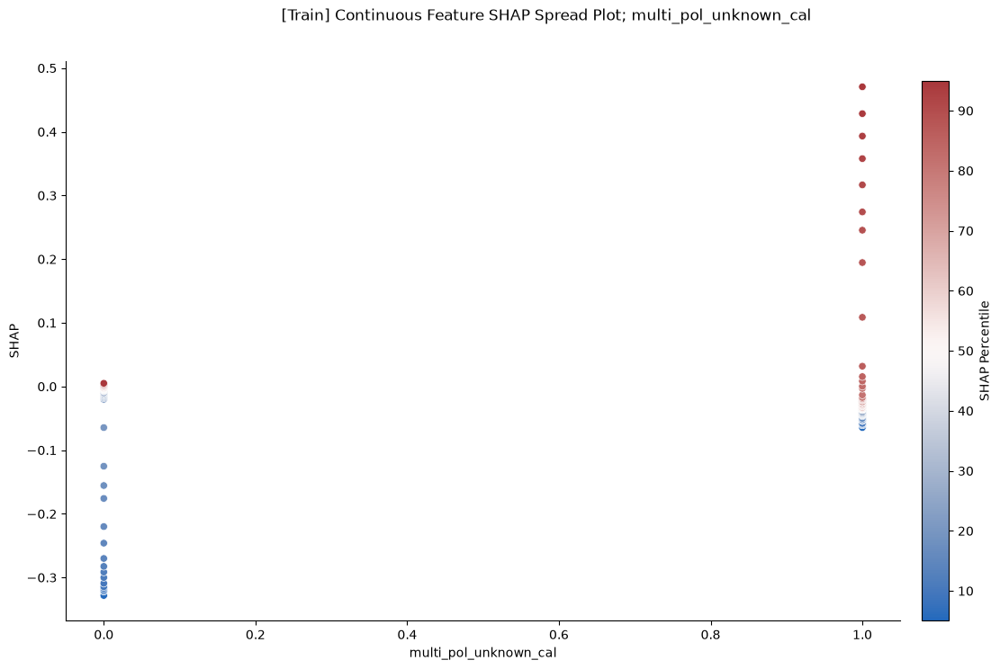

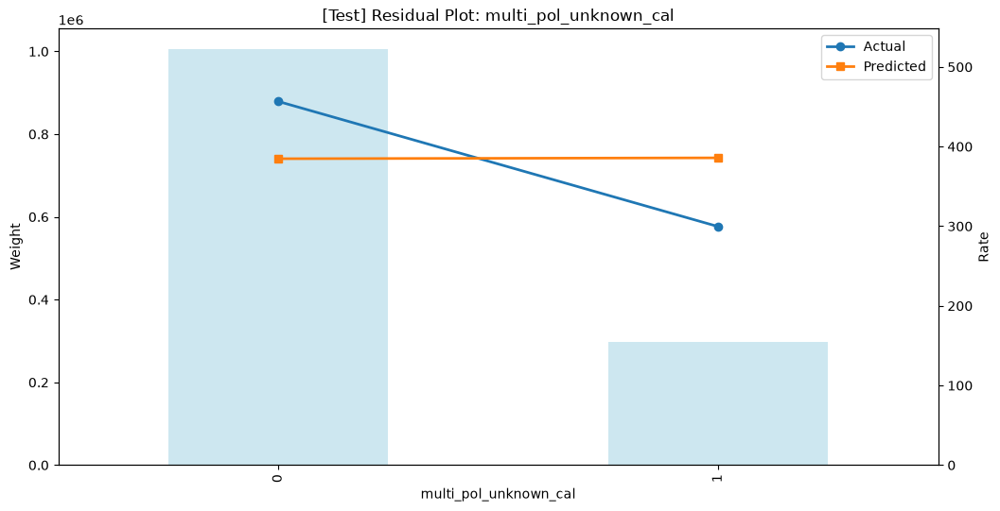

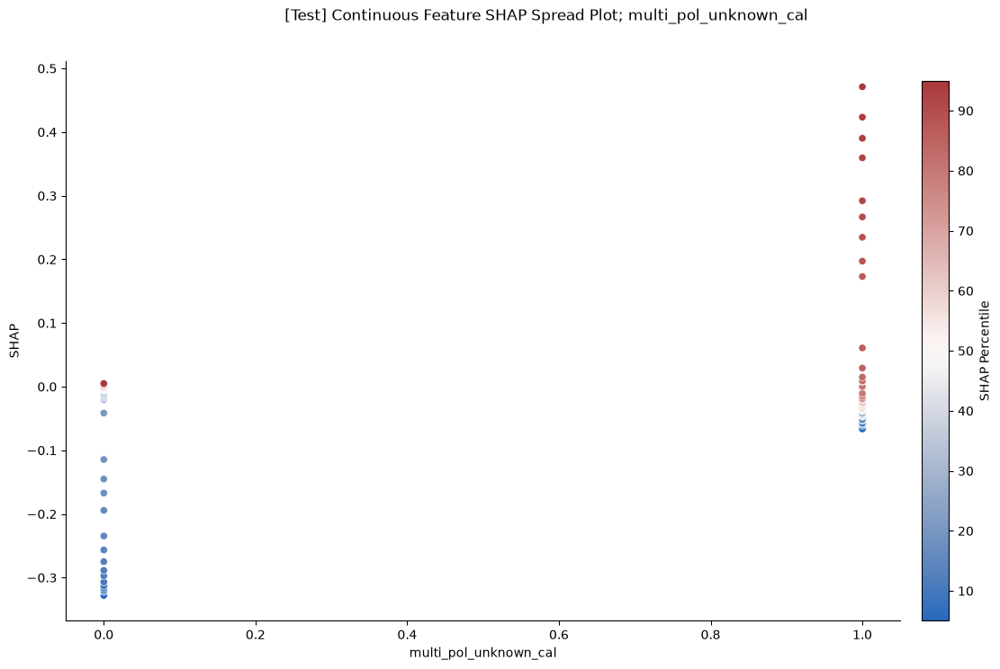


FEATURE: vc_backup_camera_raw_0


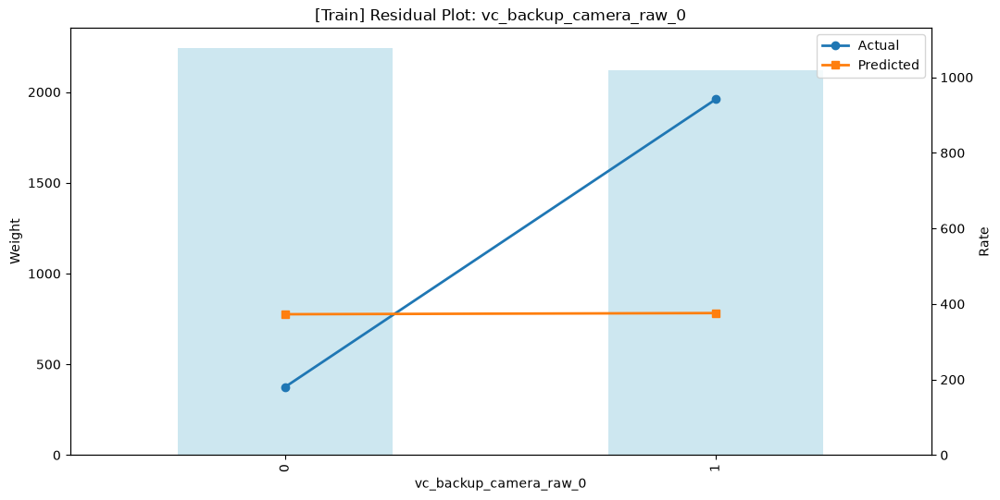

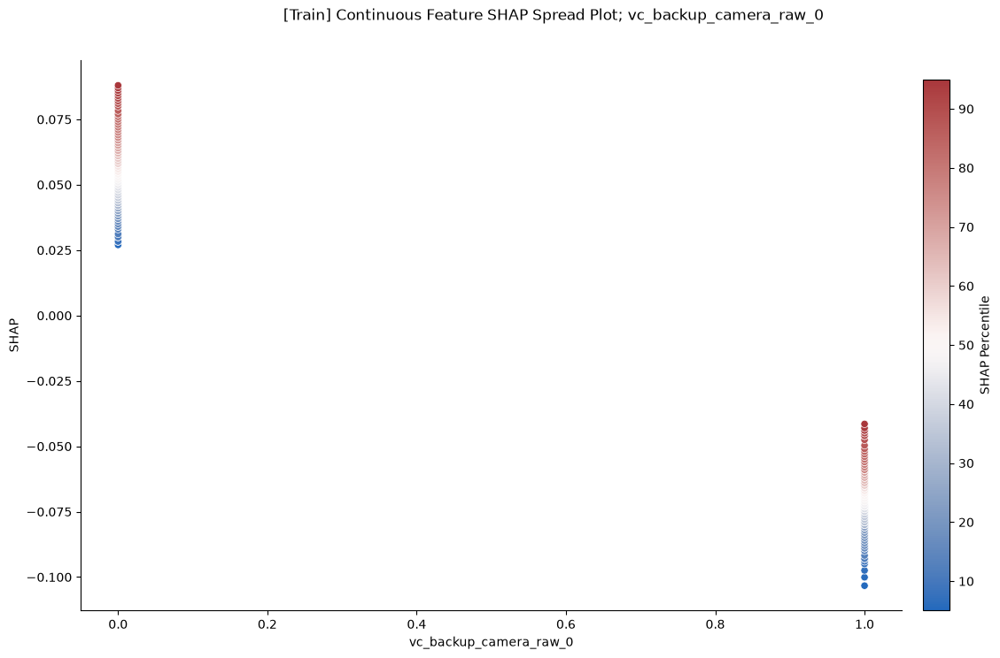

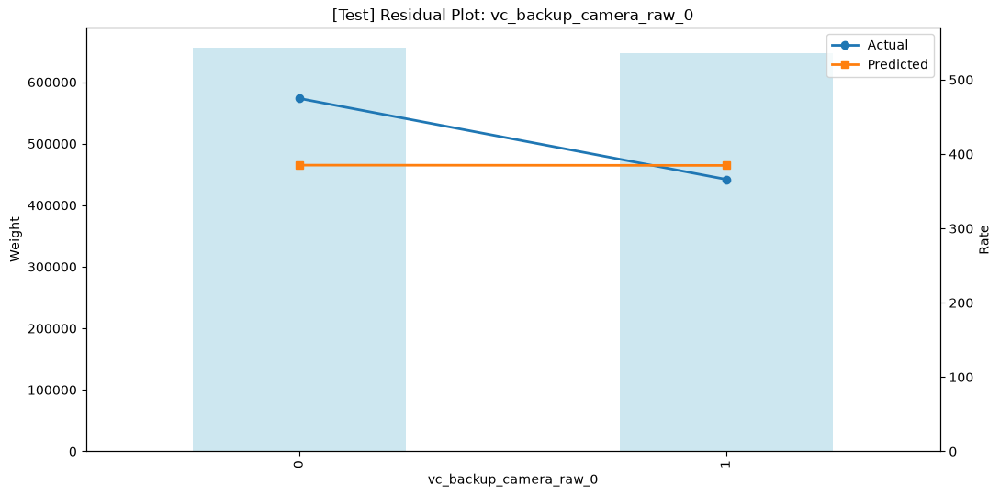

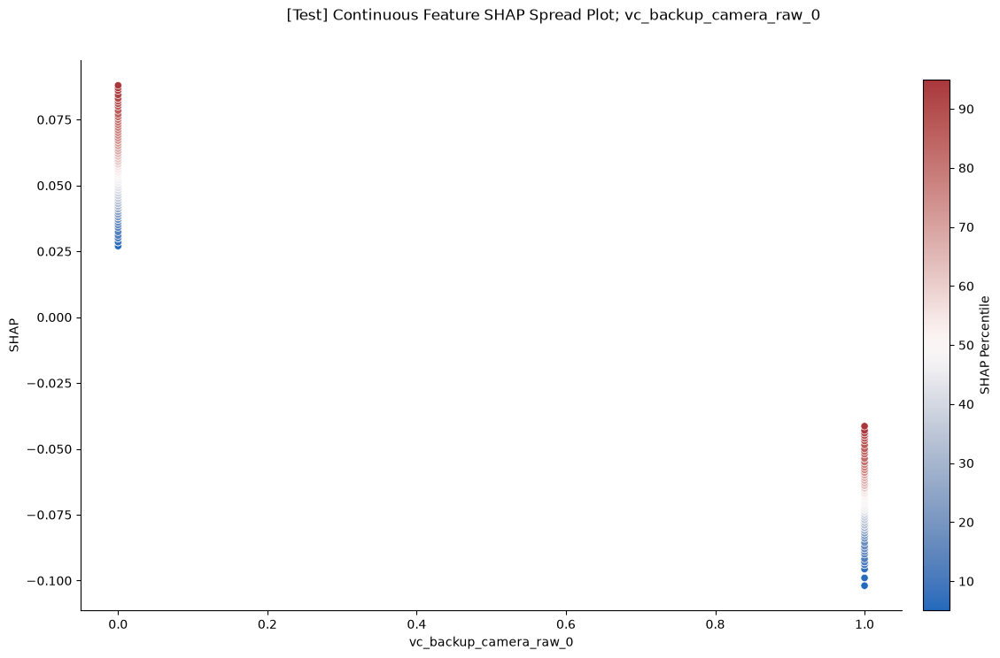


FEATURE: multi_pol_yes_cal


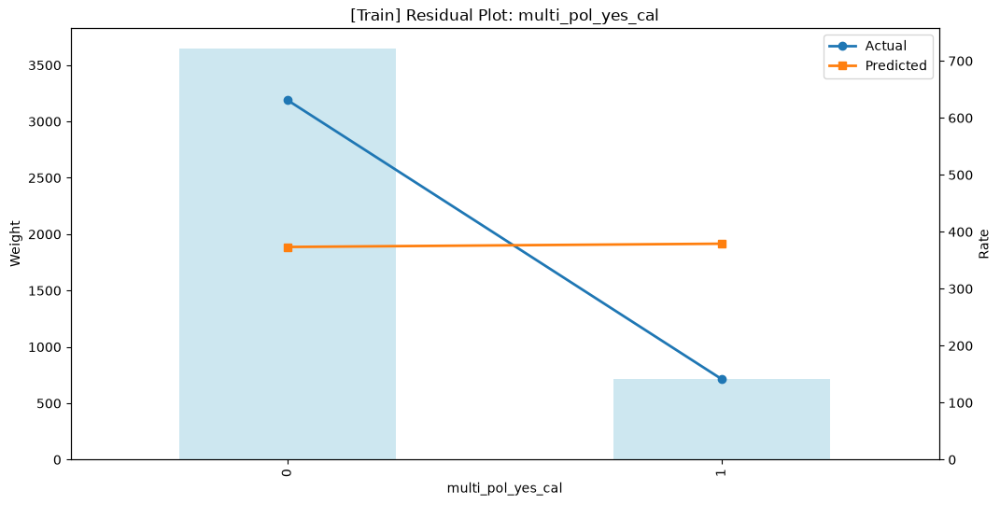

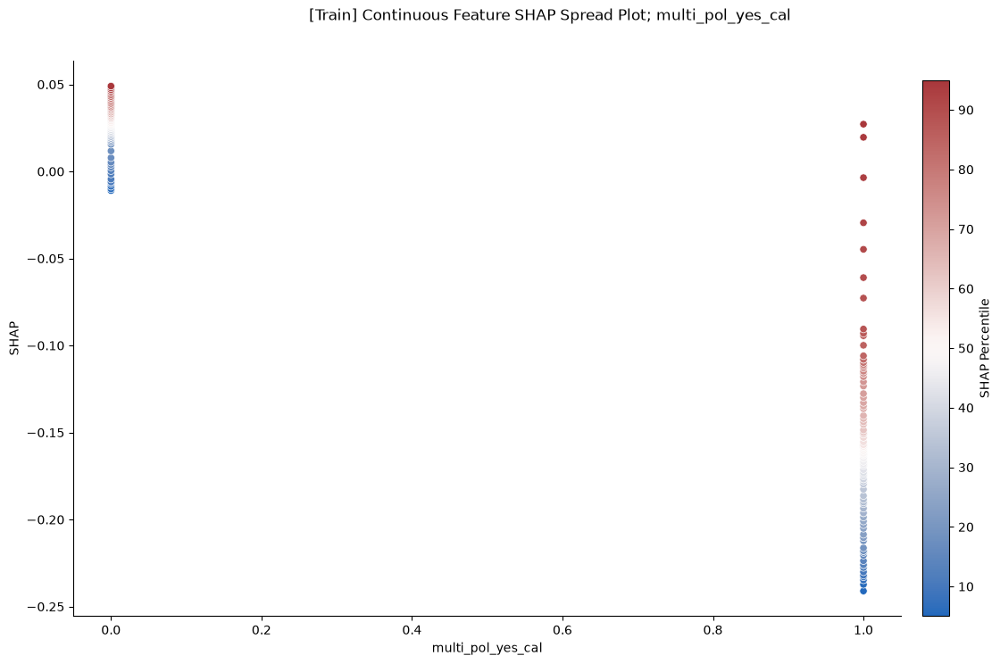

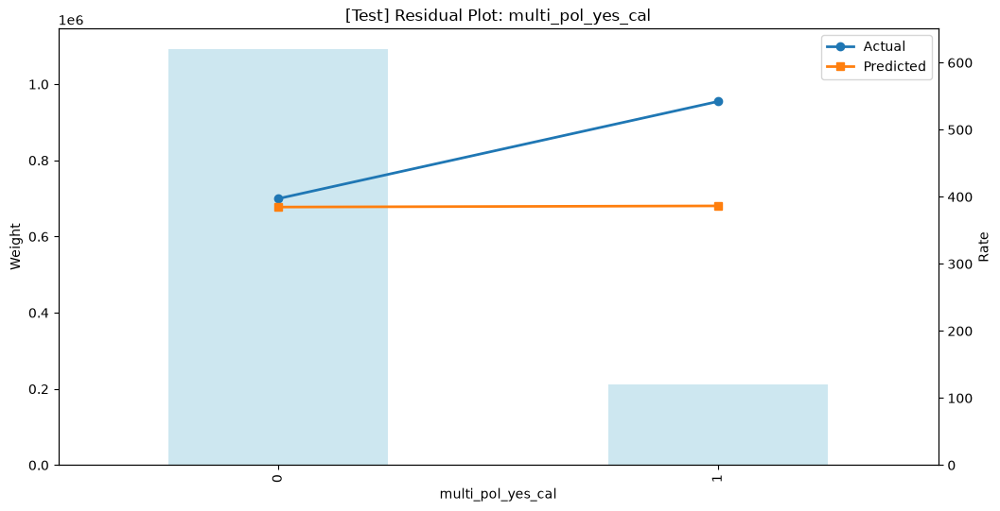

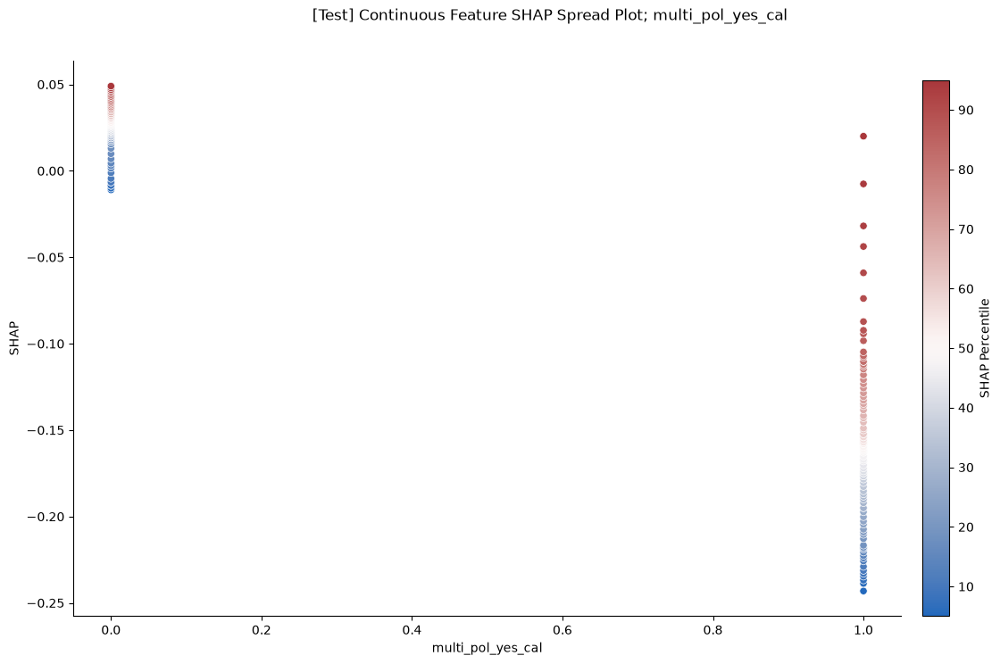


FEATURE: vc_rear_wiper_raw_0


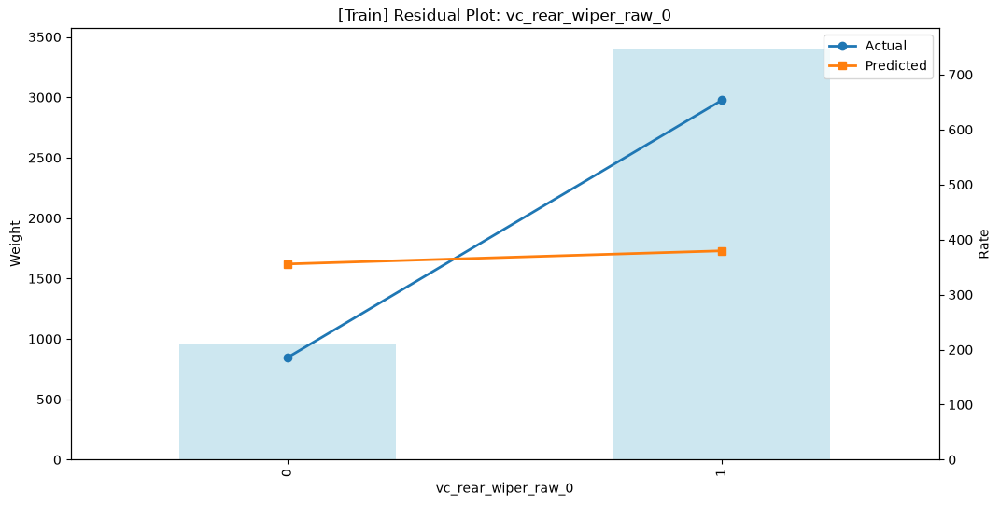

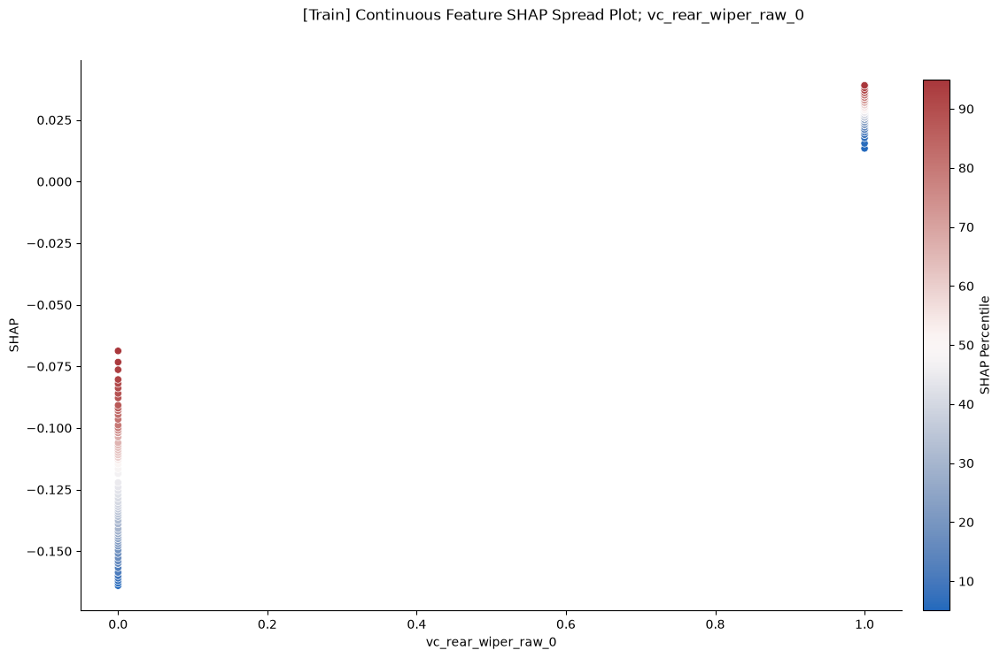

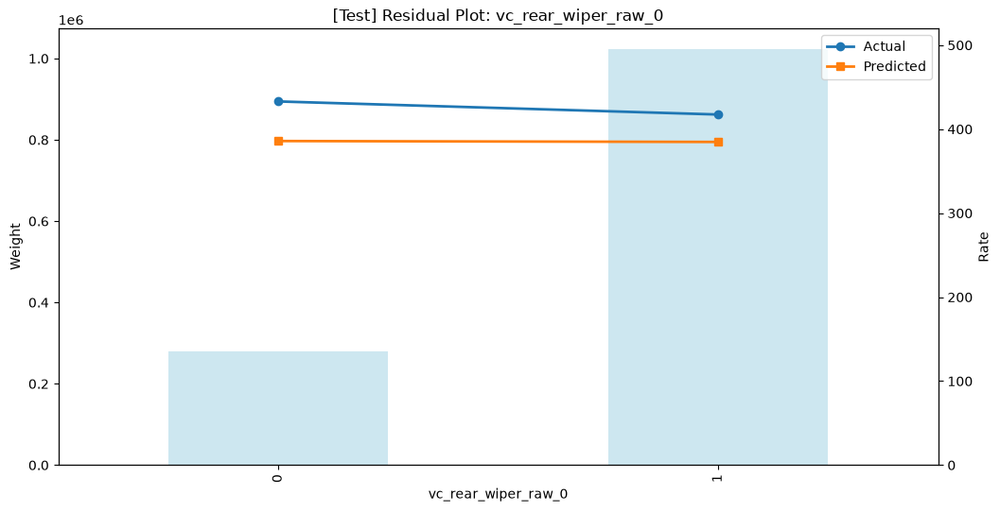

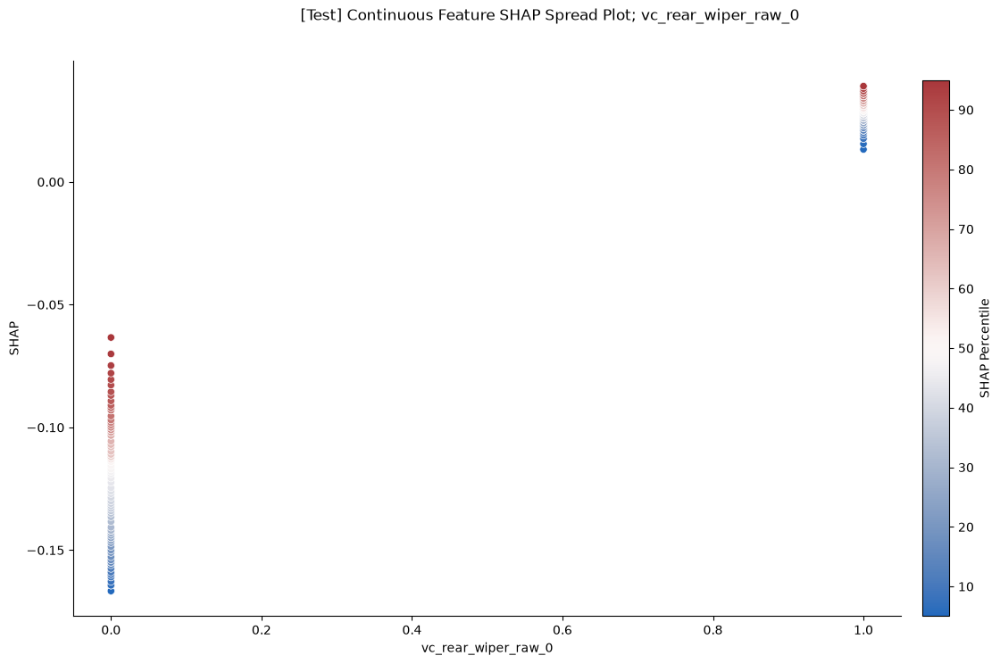


FEATURE: cef_lien_holder_ind


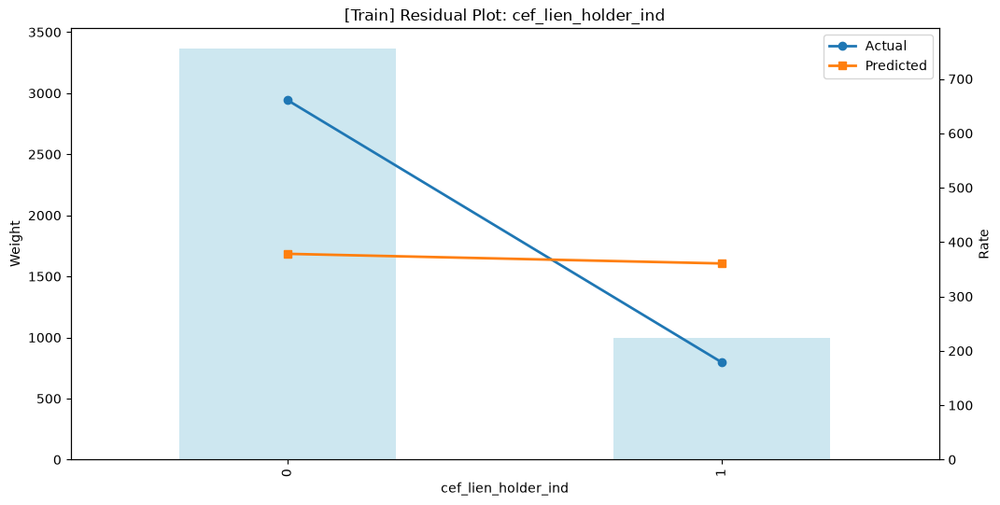

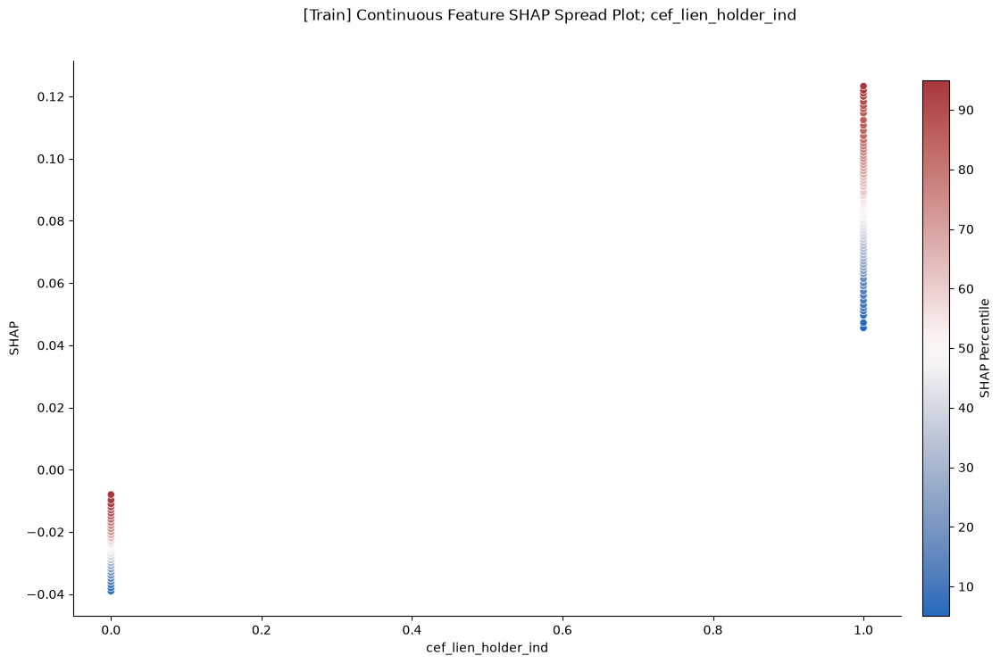

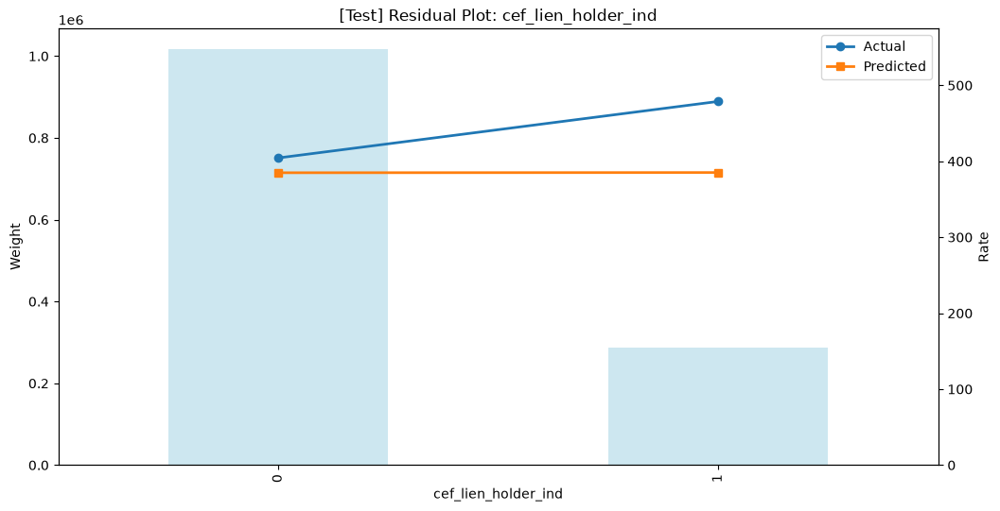

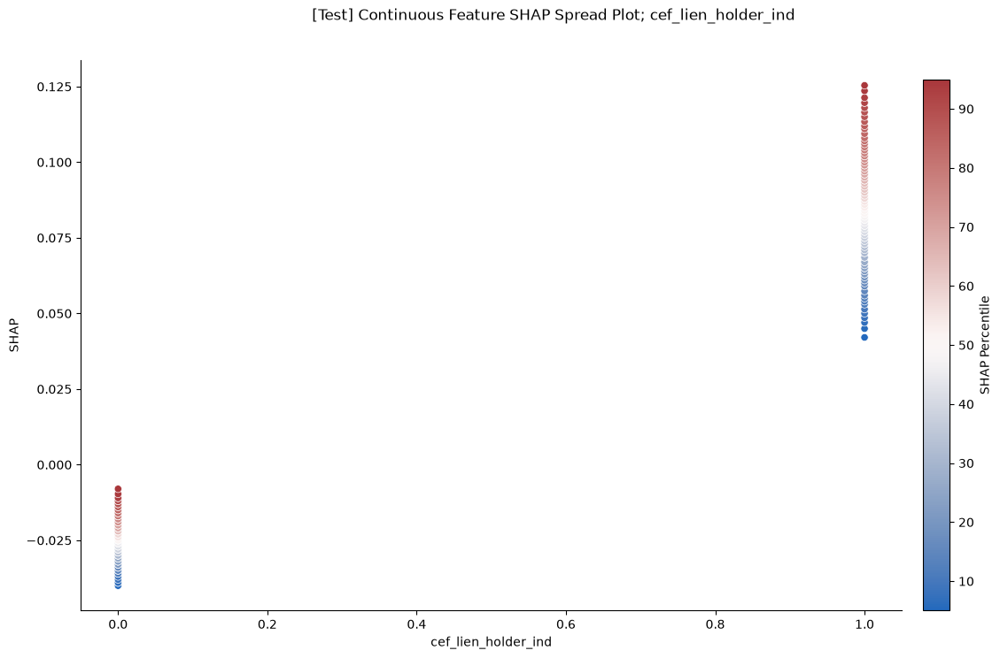


FEATURE: vc_doors_raw


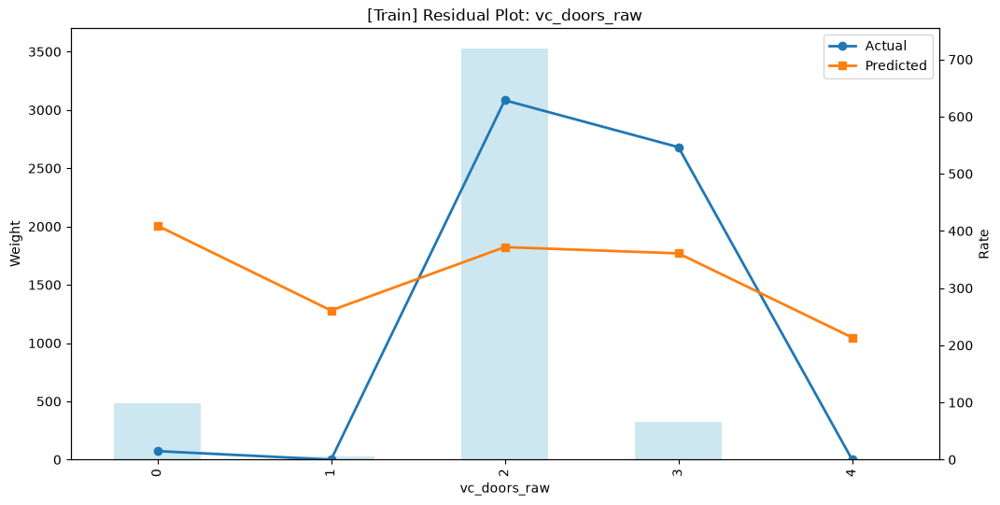

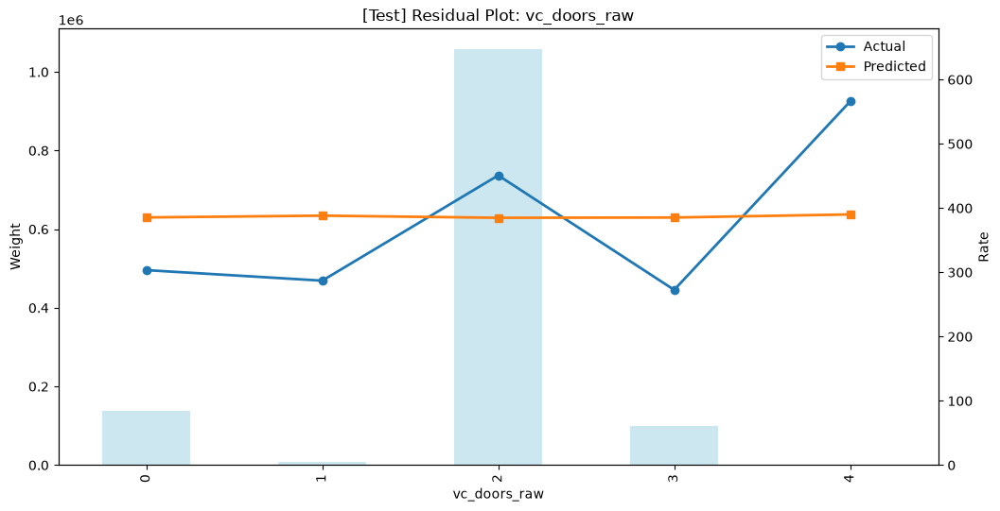

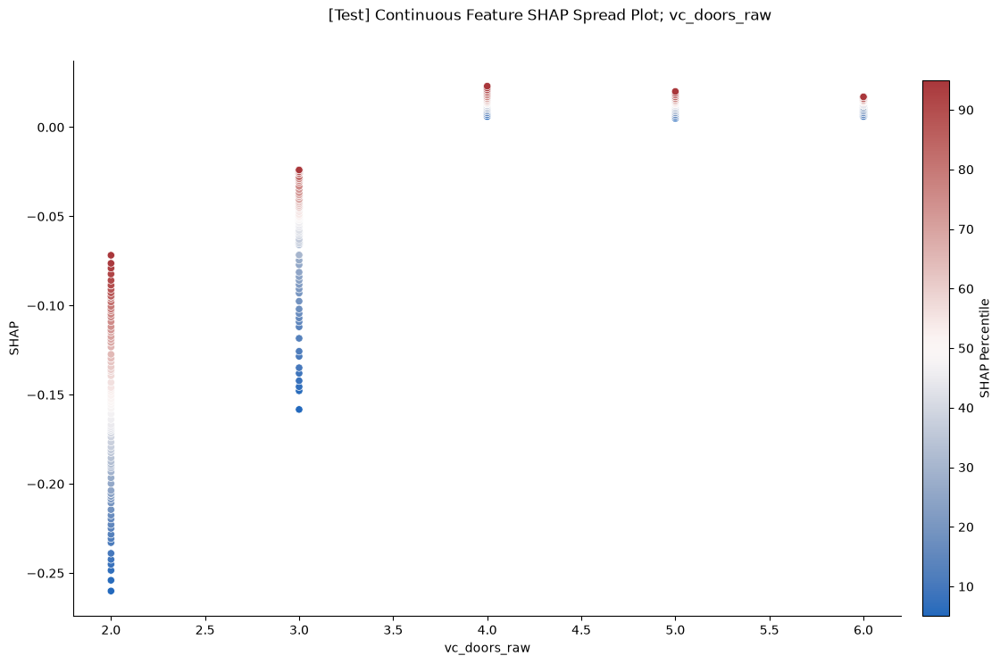


FEATURE: veh_use_commute_ind


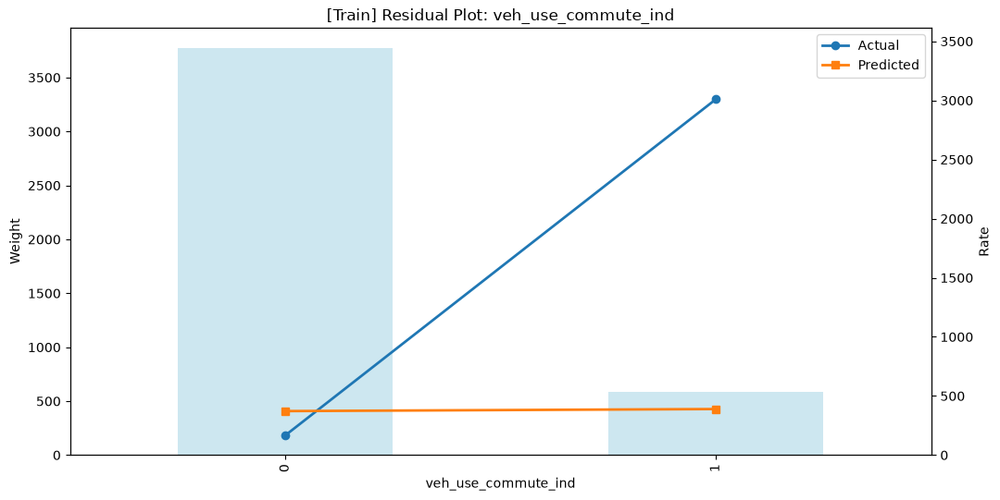

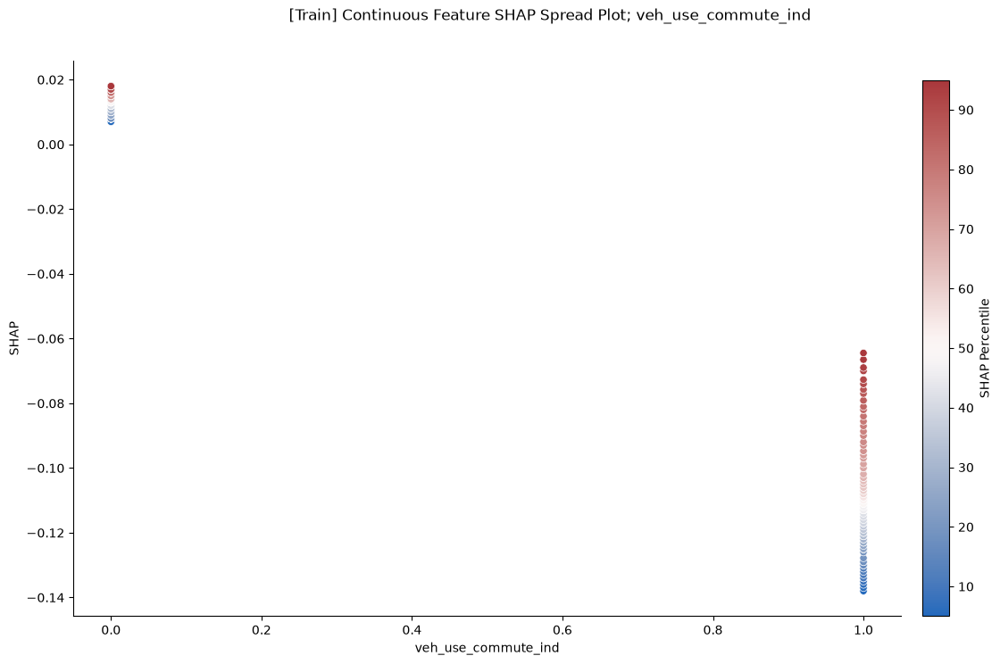

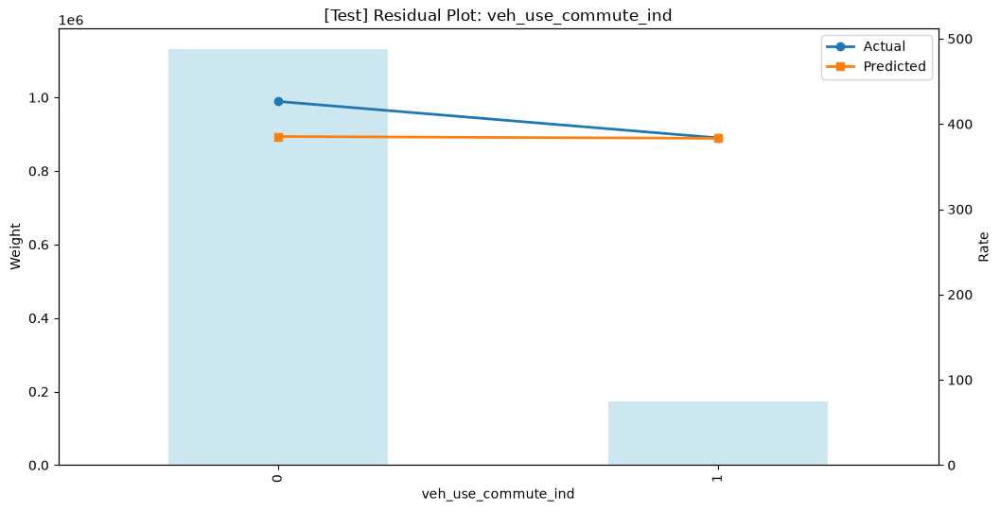

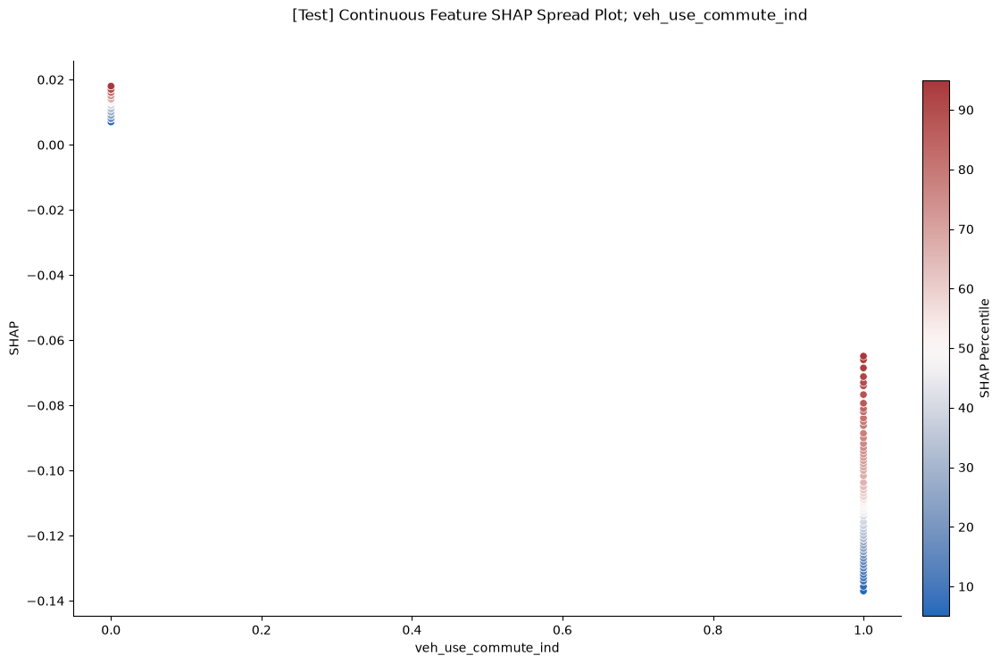


FEATURE: vc_seating_rows_raw


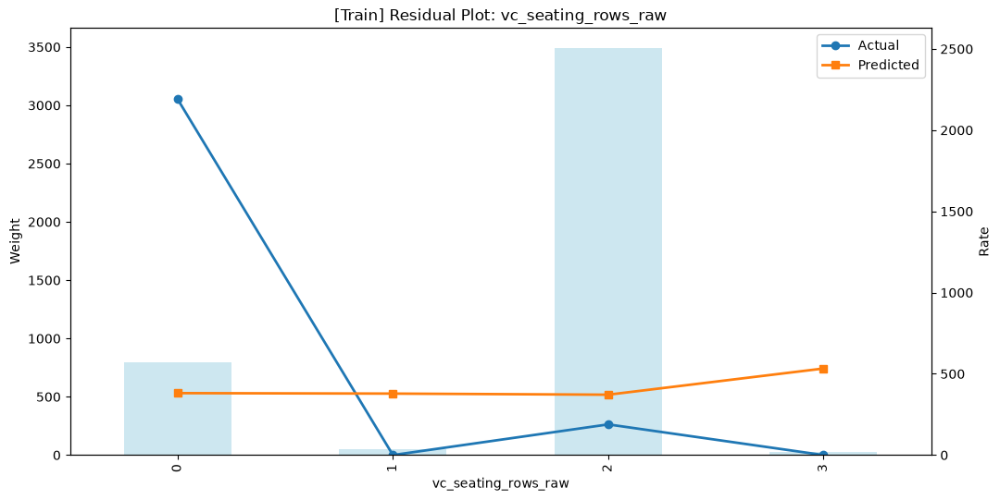

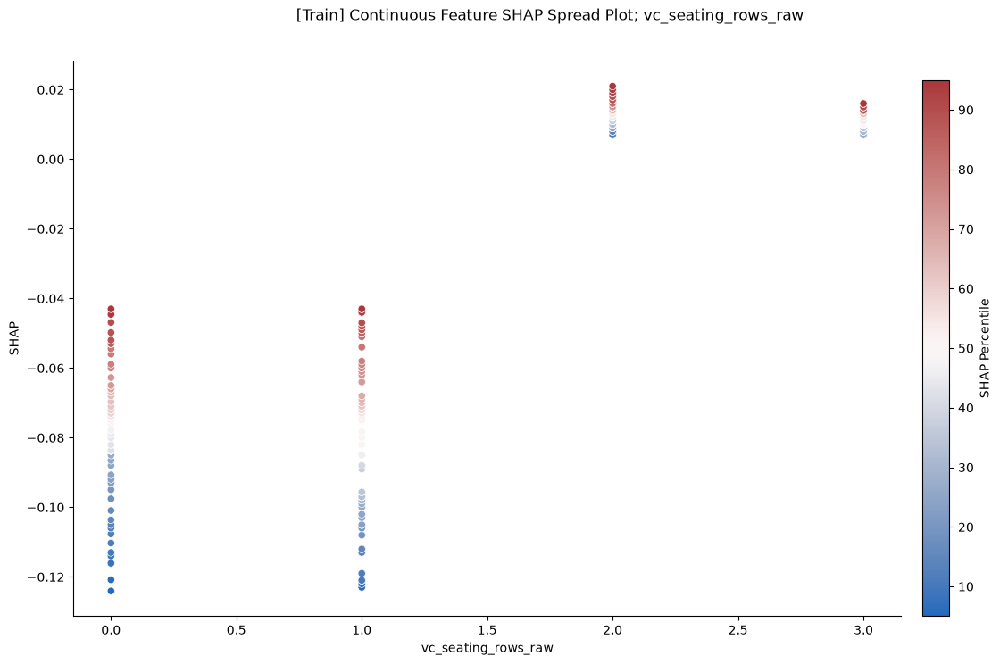

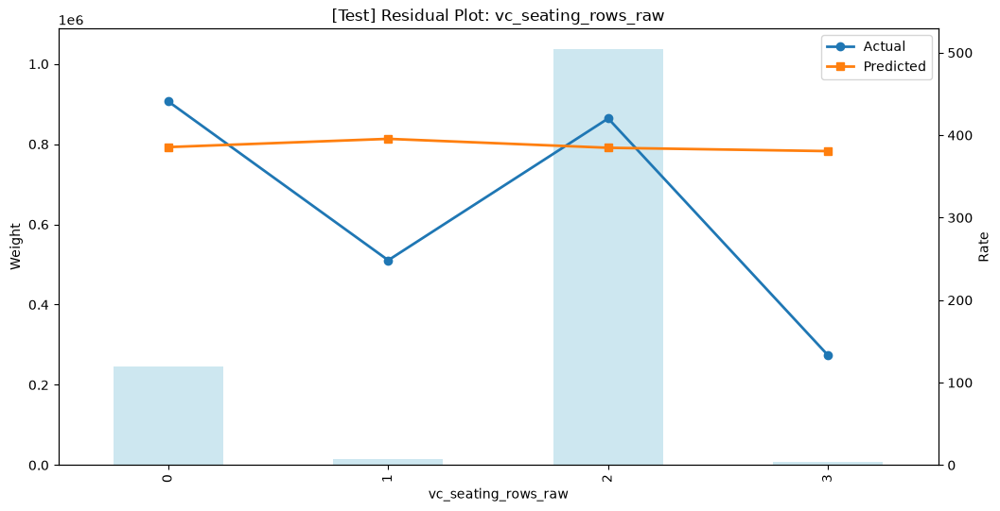

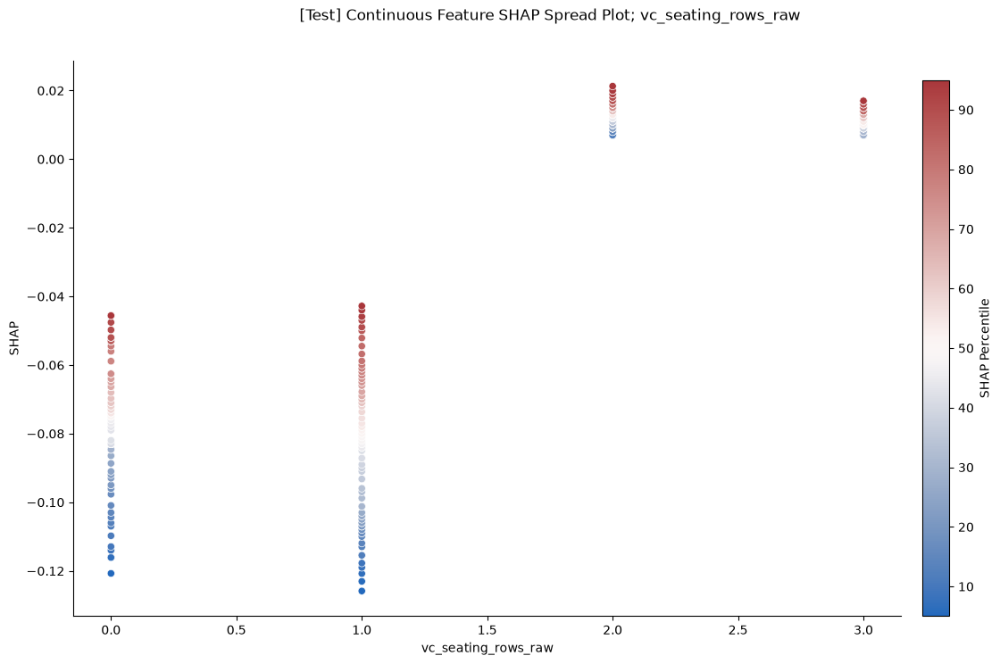


FEATURE: vc_auto_dimming_rearview_mirror_raw_5


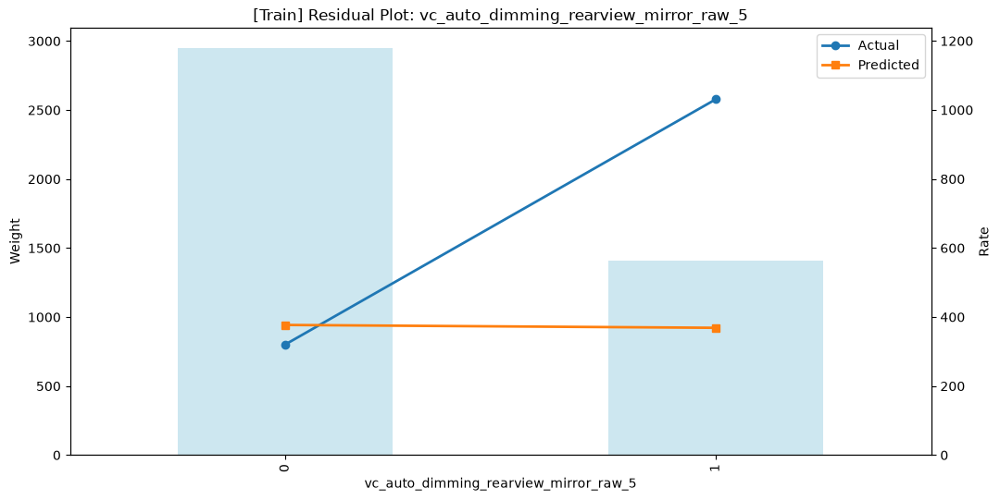

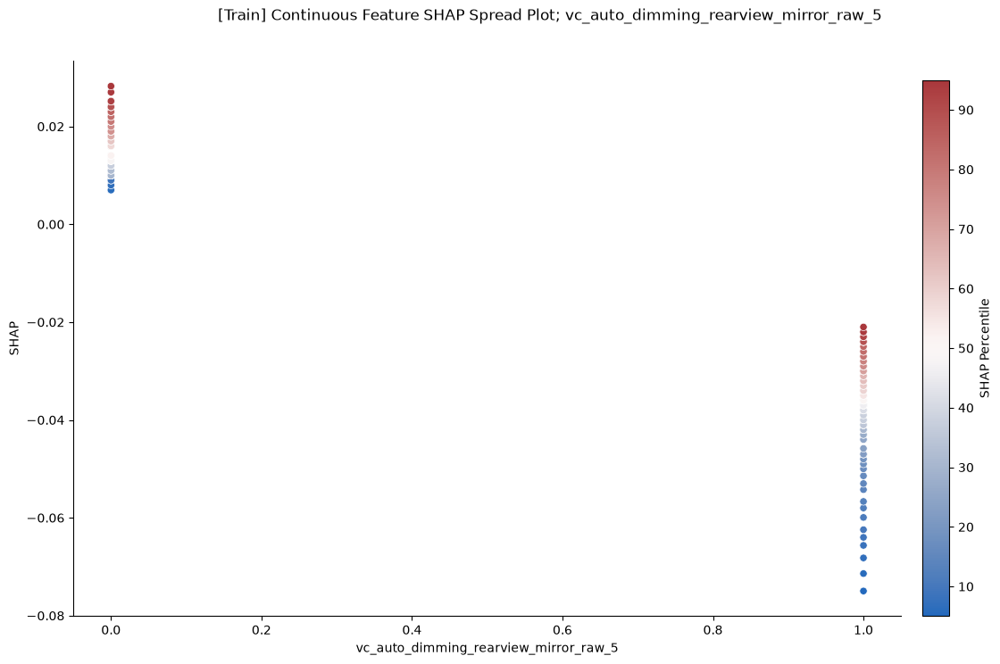

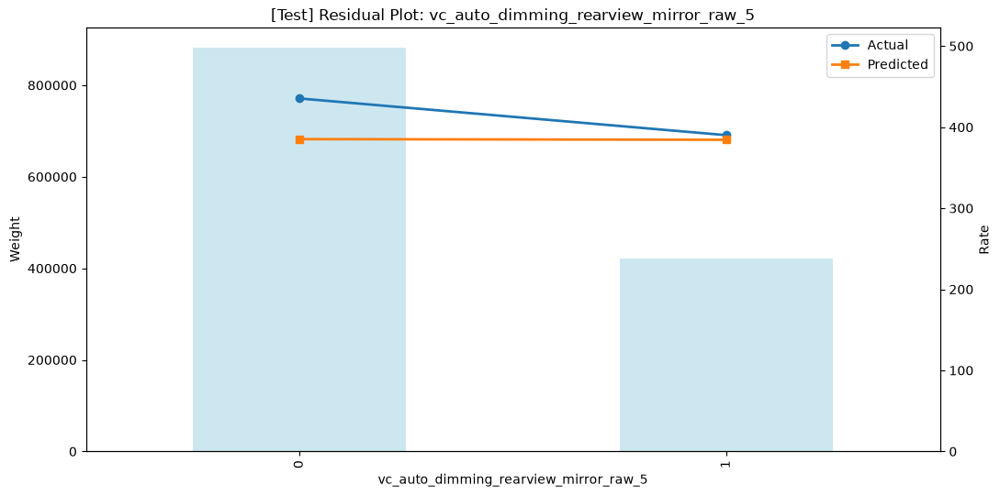

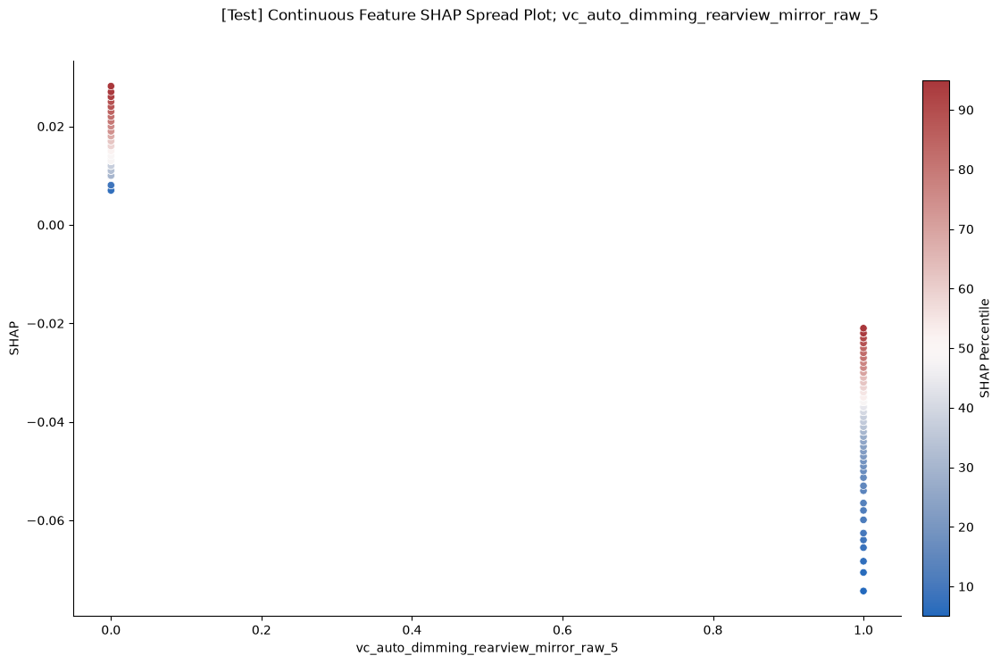


FEATURE: vc_msrp_impa


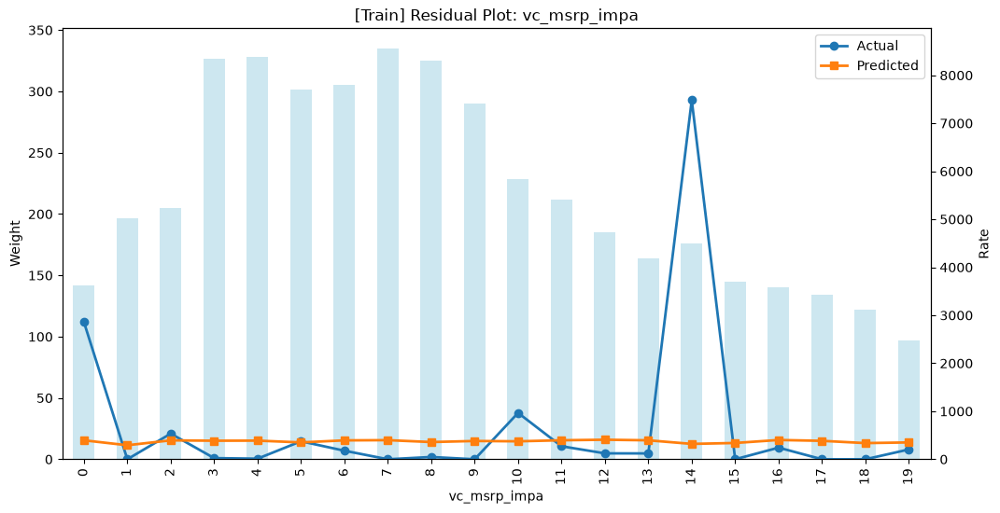

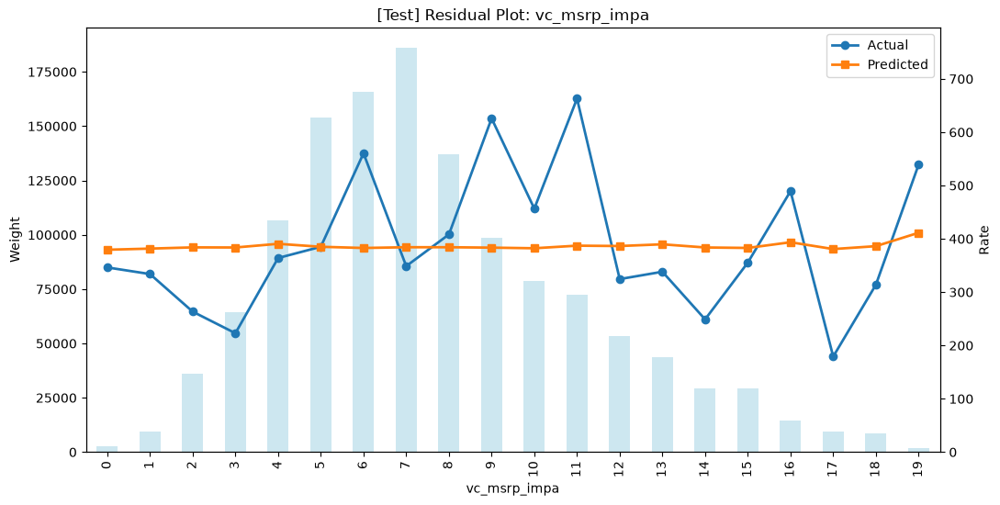


FEATURE: vc_transmission_type_manual_ind


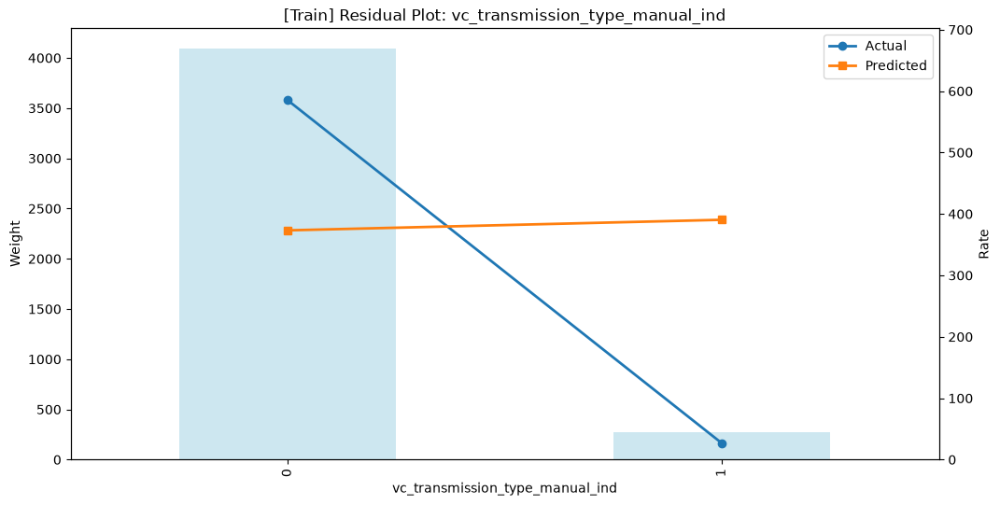

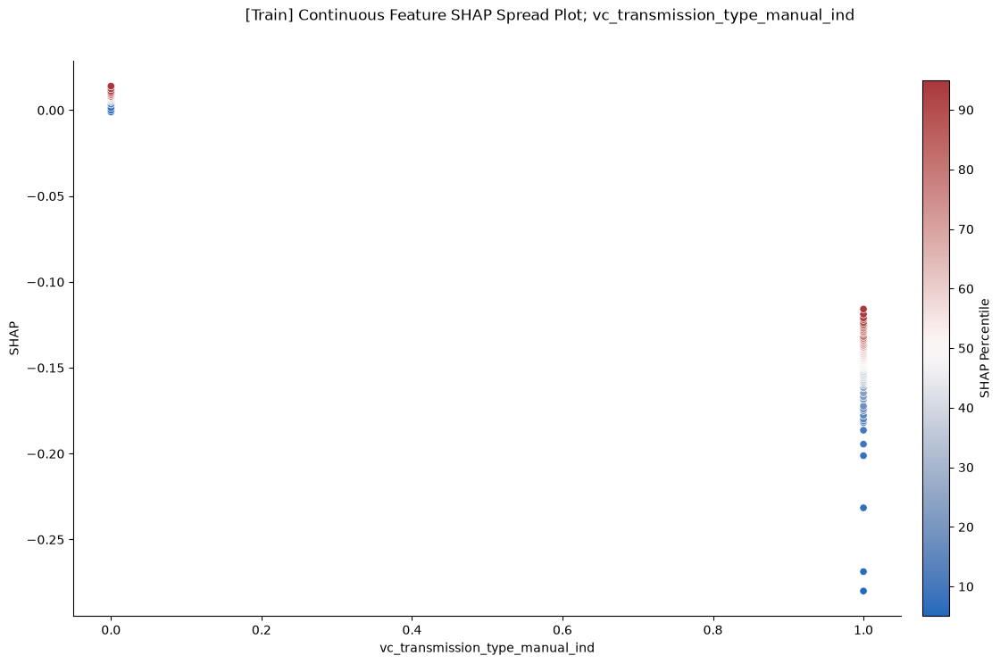

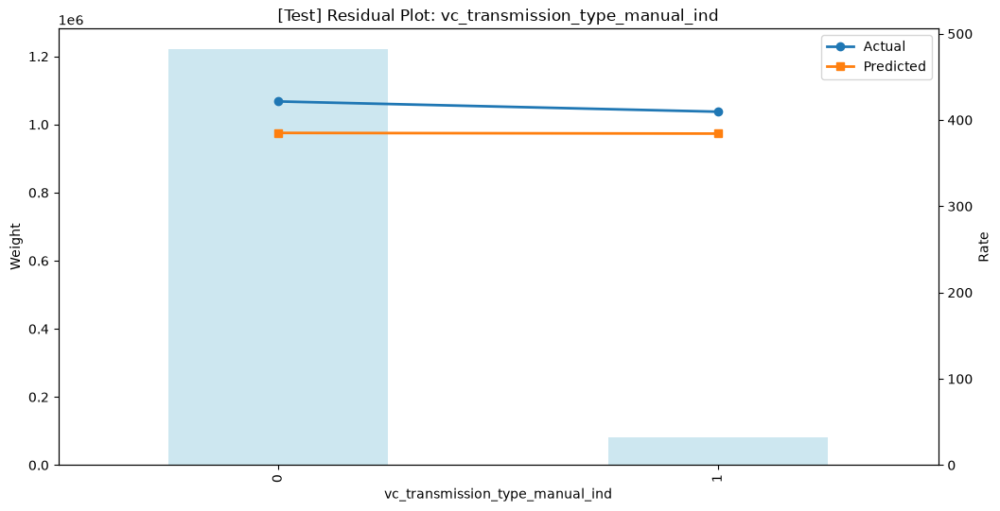

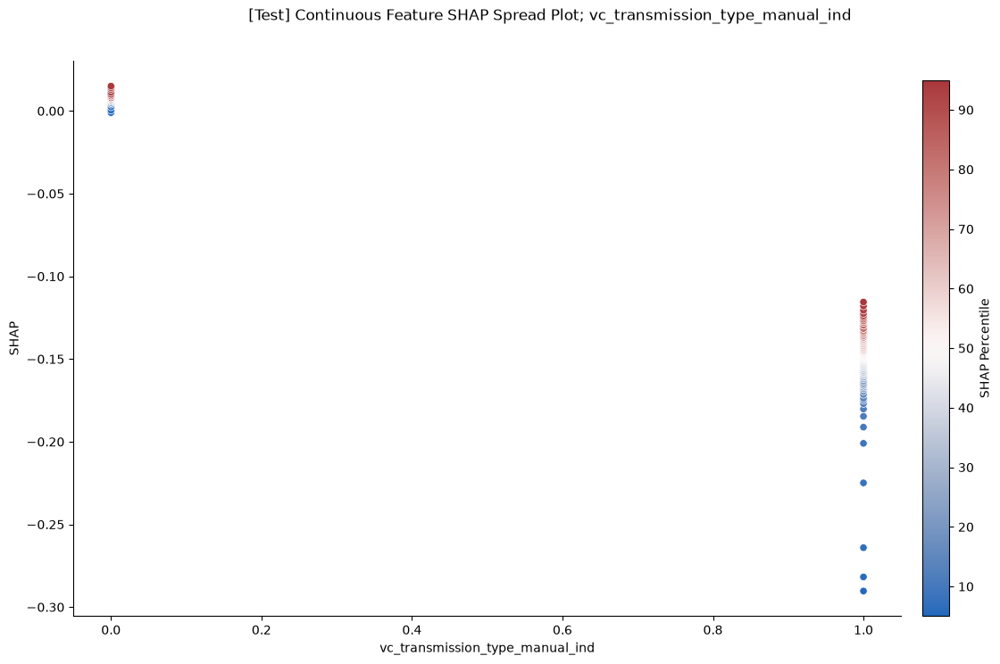


FEATURE: vc_remote_engine_start_raw_0


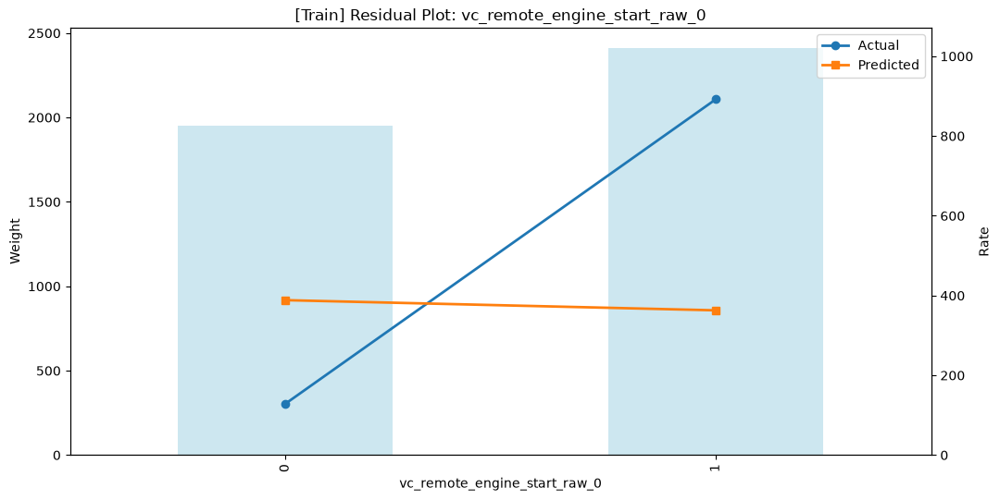

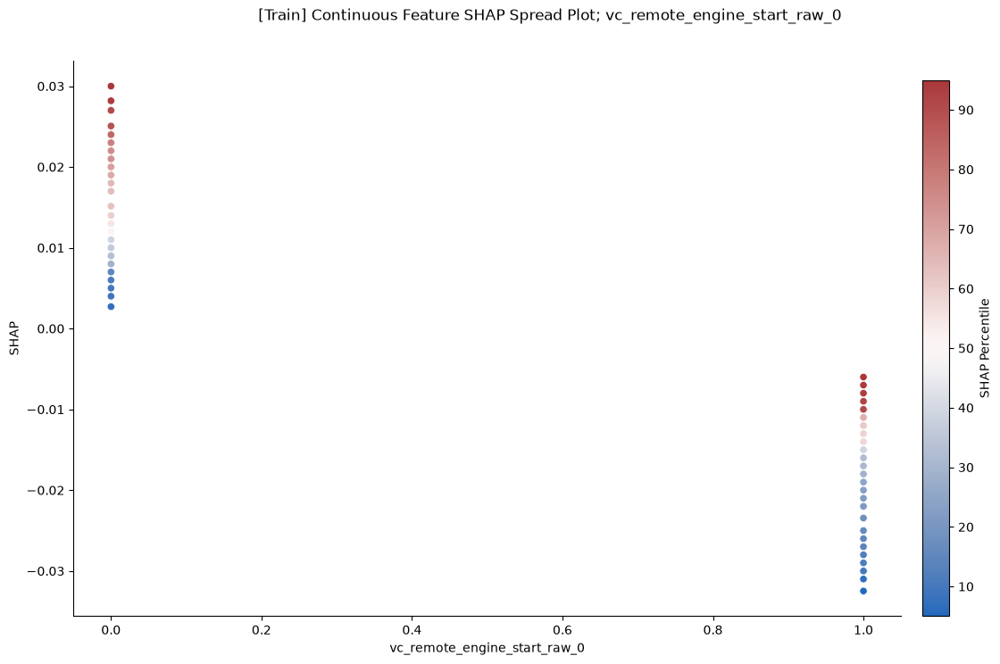

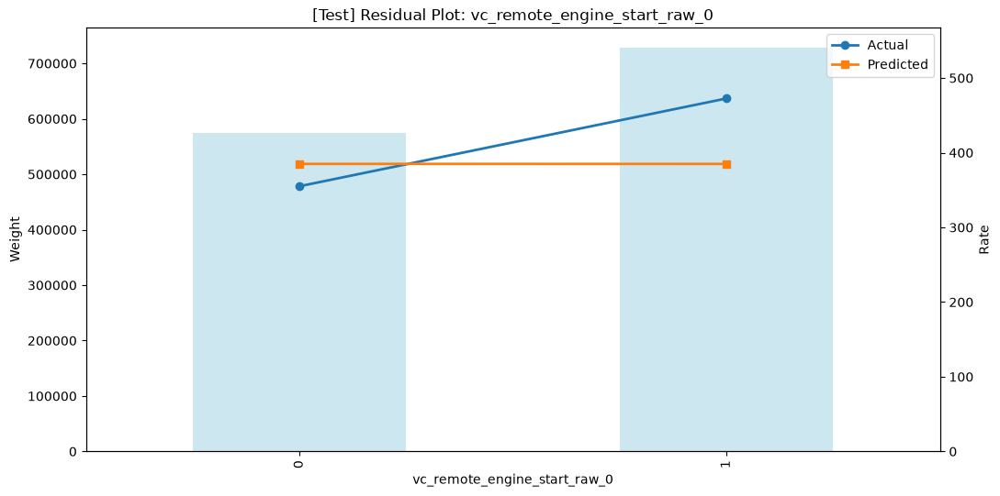

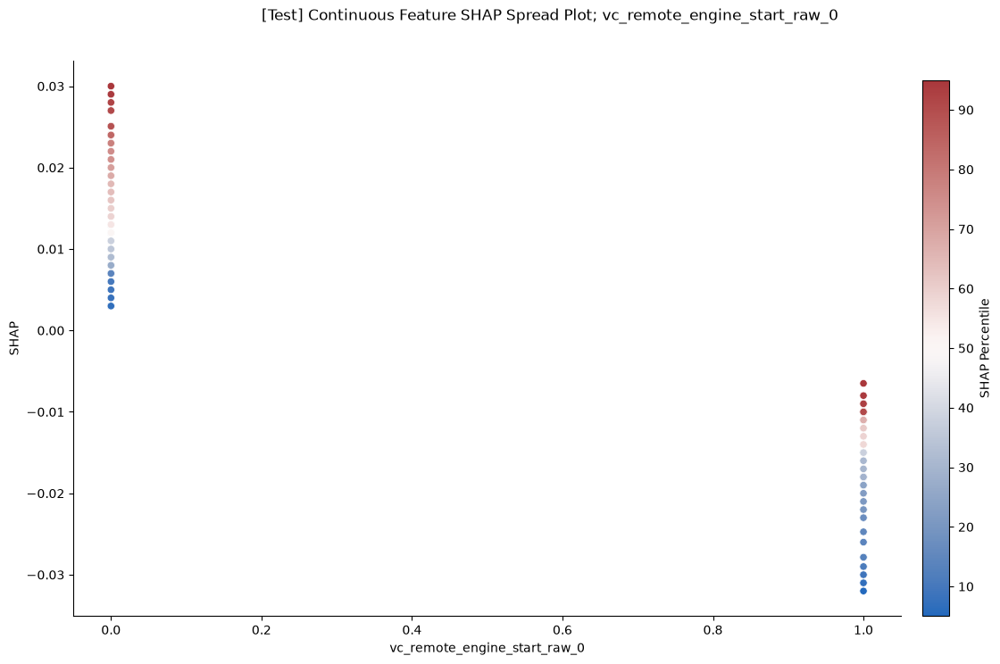


FEATURE: vc_premium_audio_raw


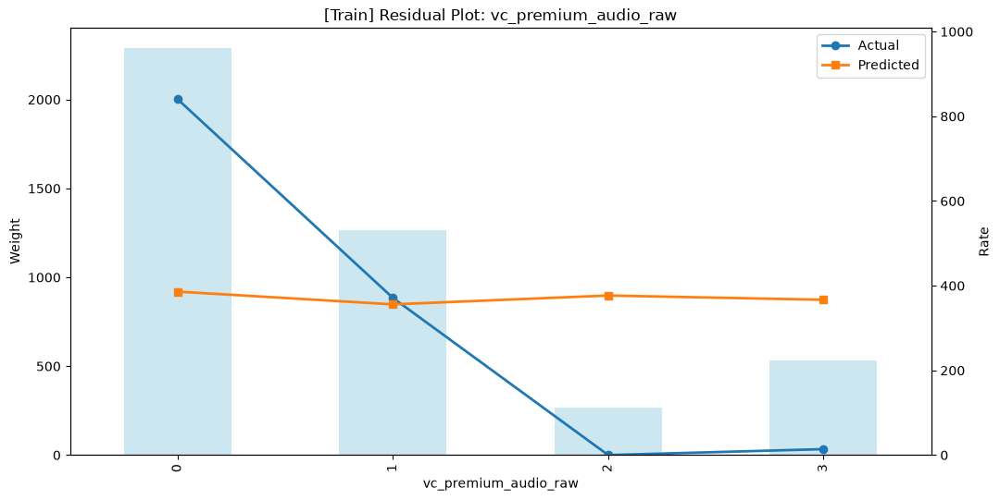

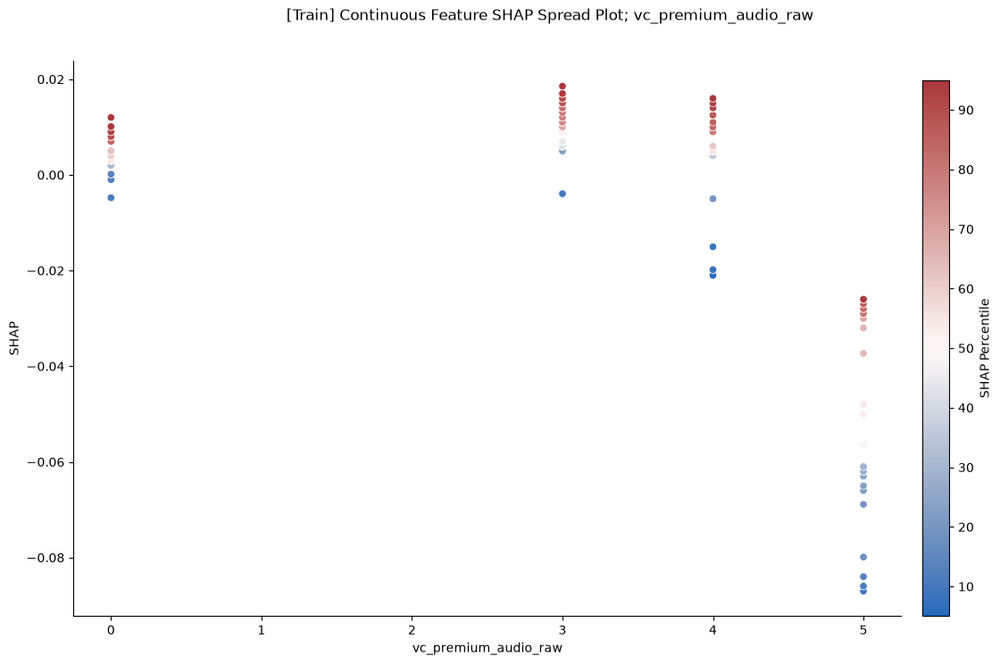

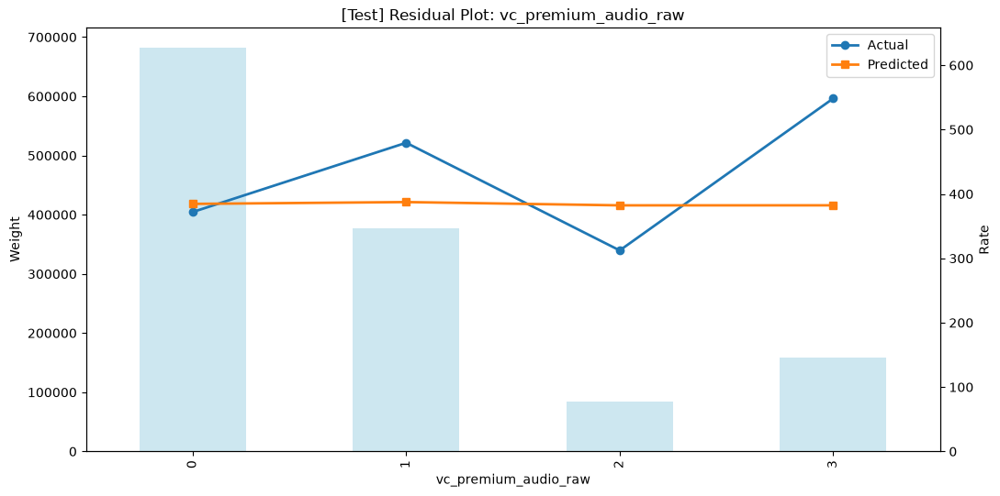

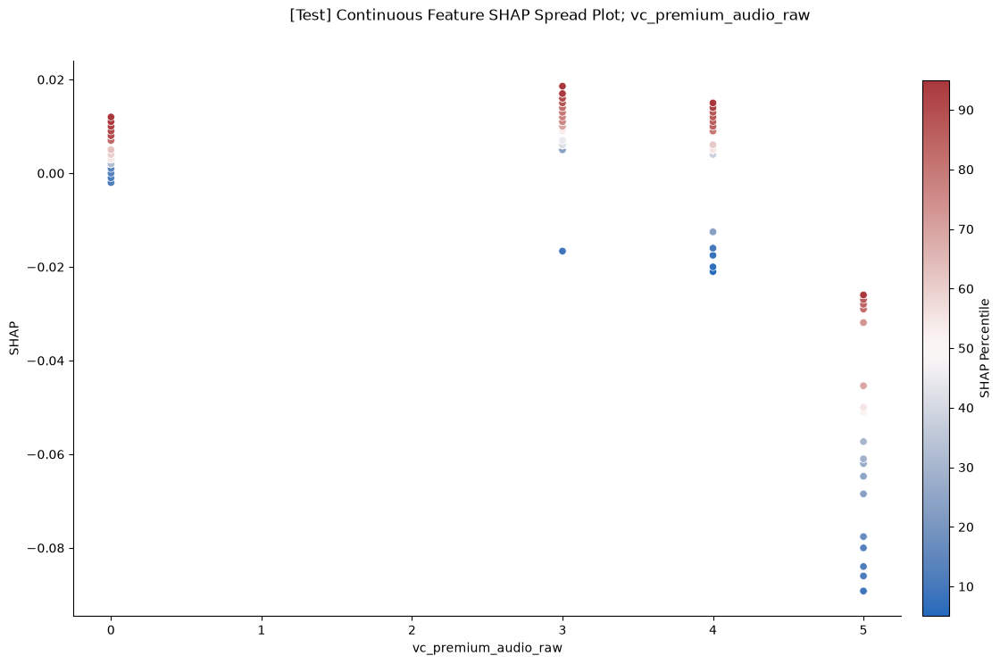


FEATURE: vc_side_mirror_turn_signals_raw


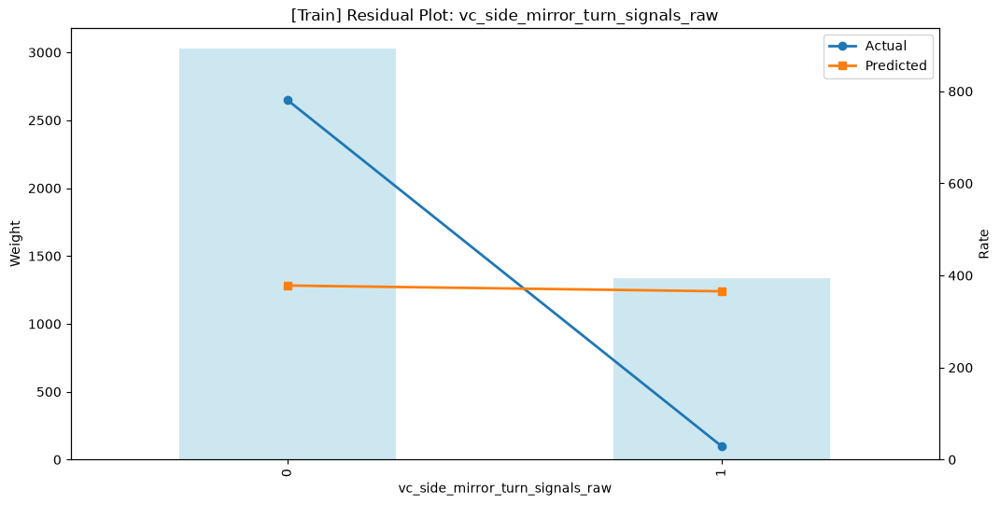

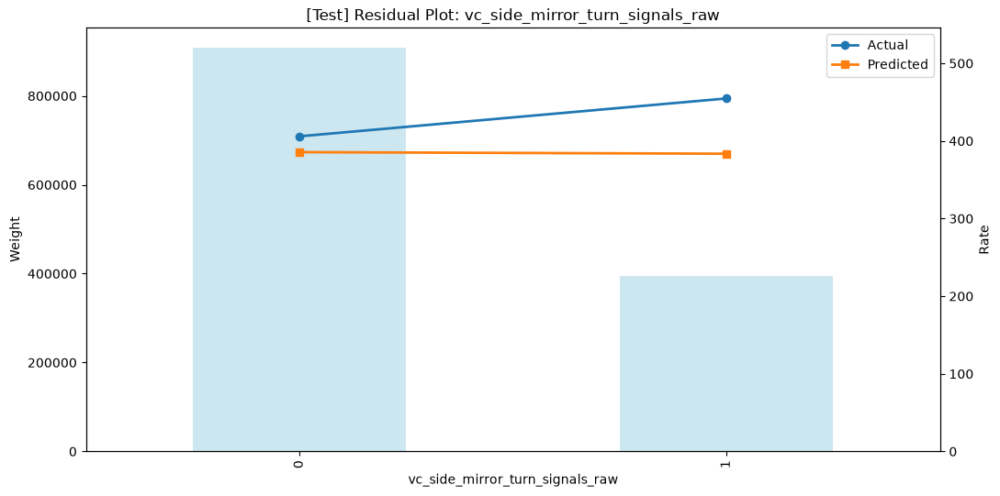


FEATURE: vc_pedestrian_detection_raw_5


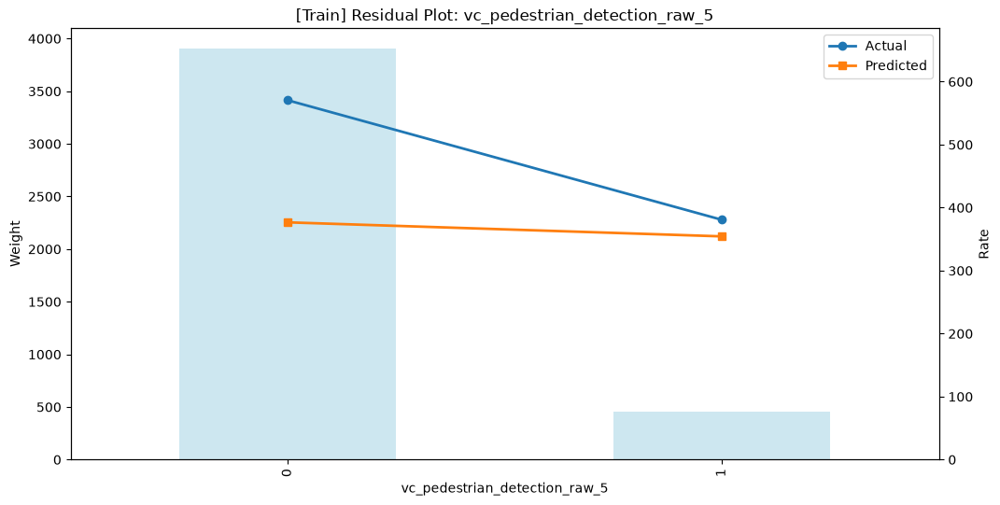

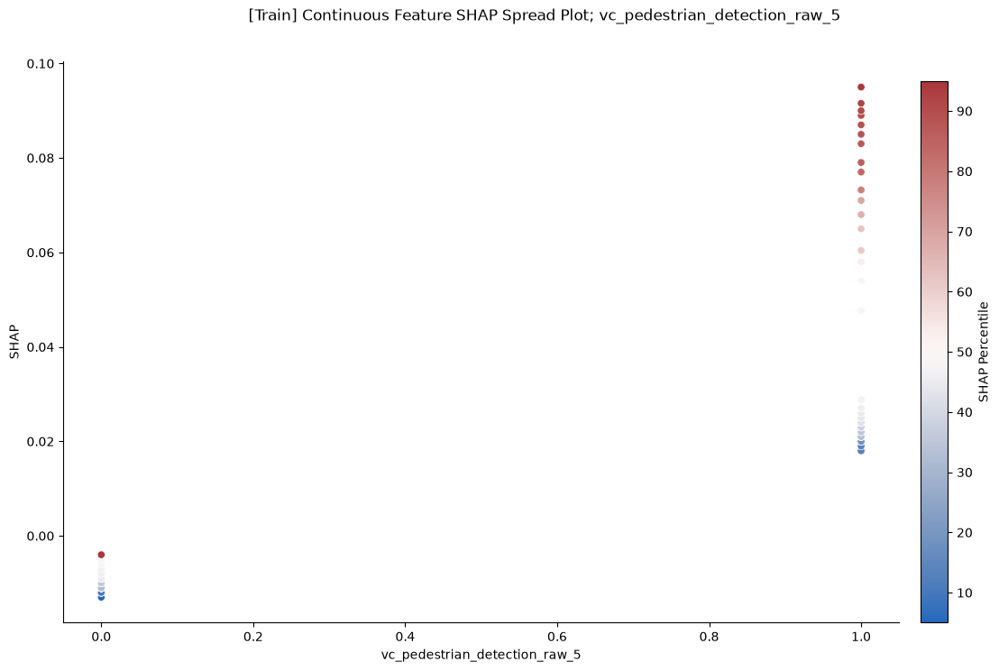

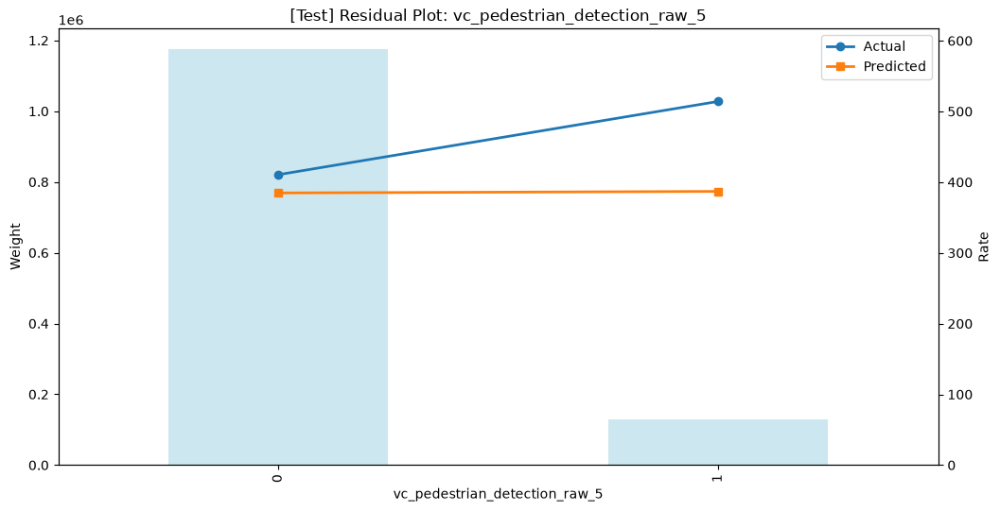

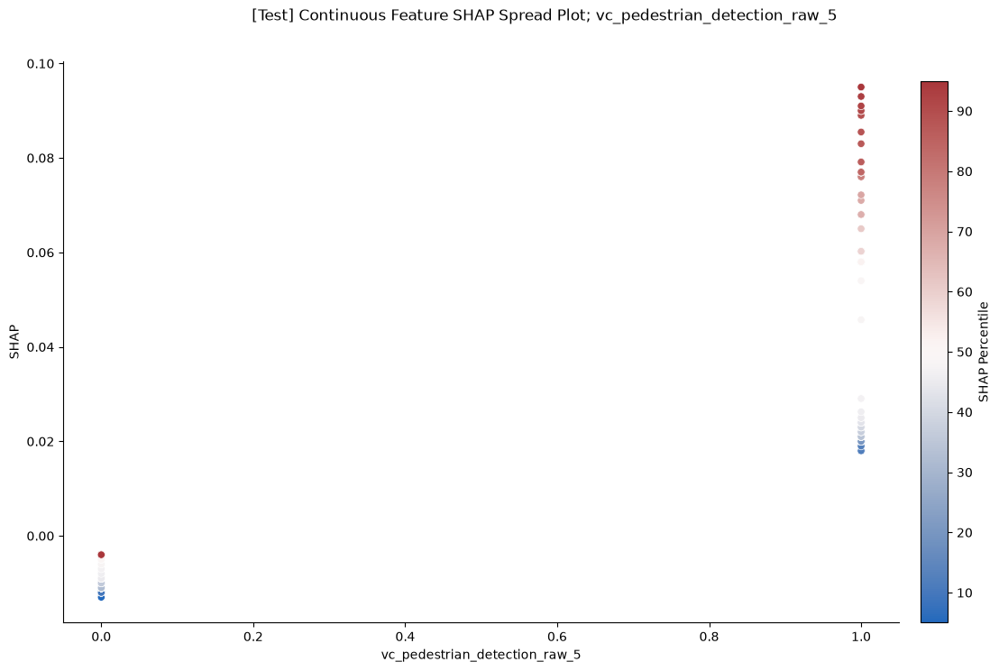


FEATURE: gender_male_ind


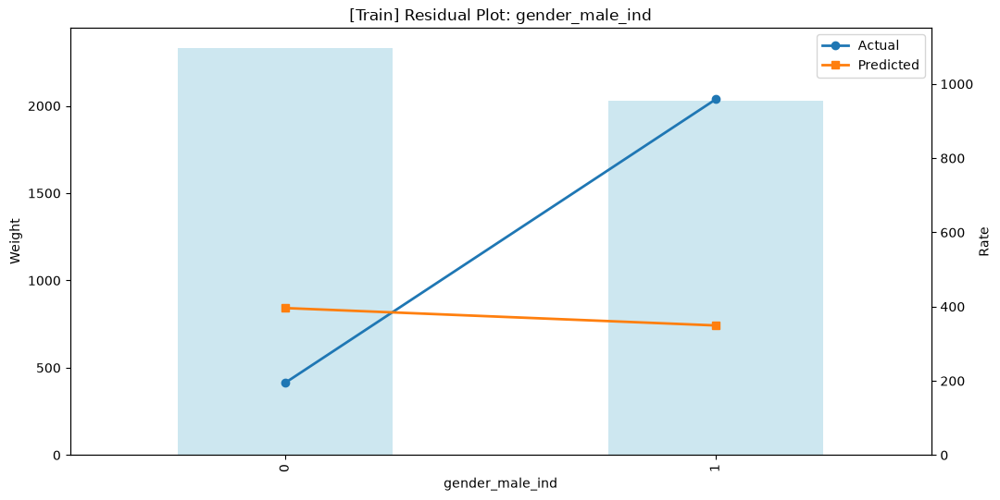

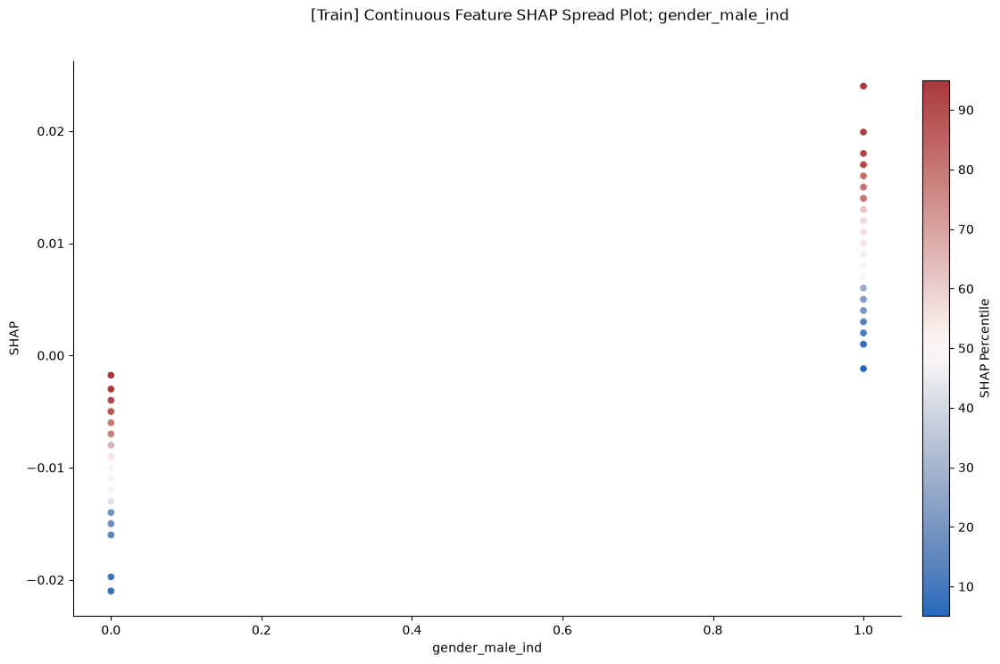

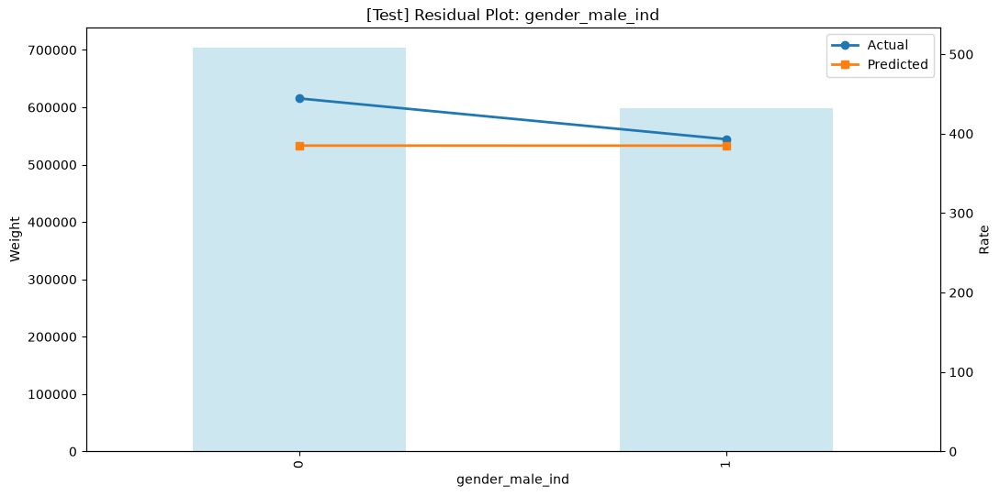

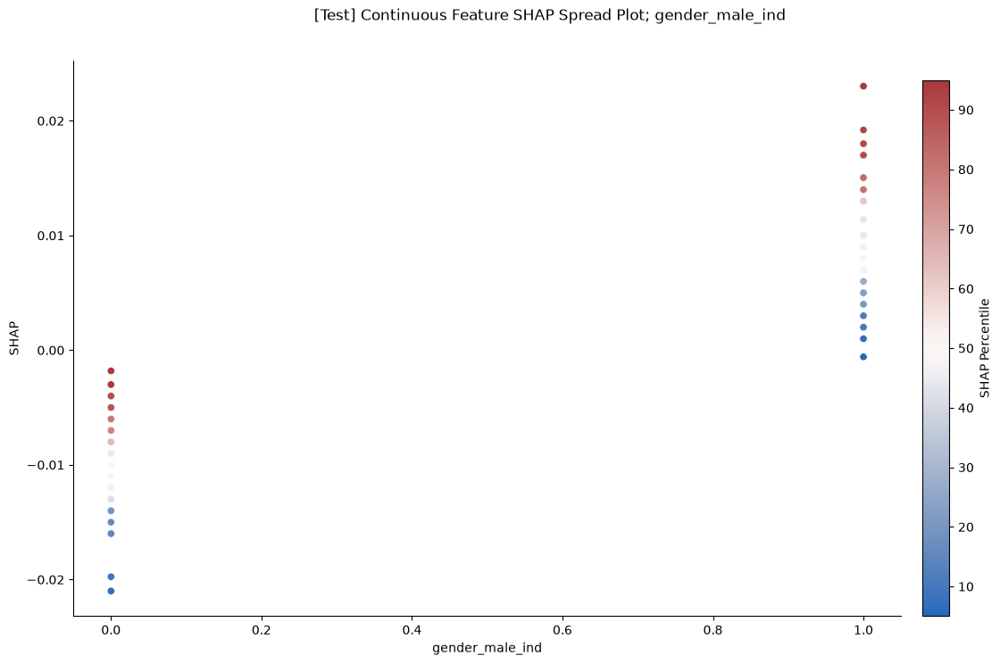


FEATURE: vc_automatic_emergency_braking_raw_3


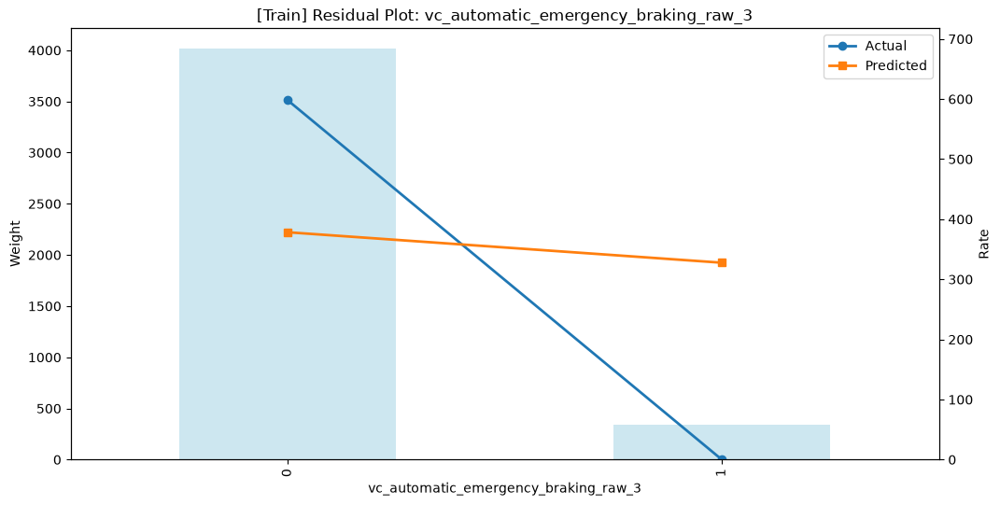

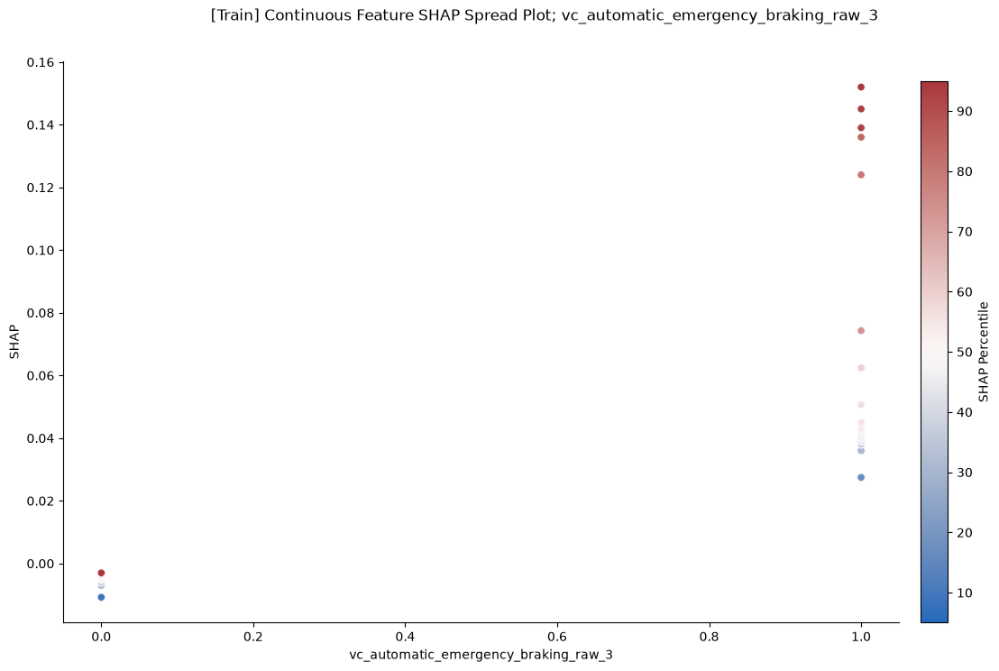

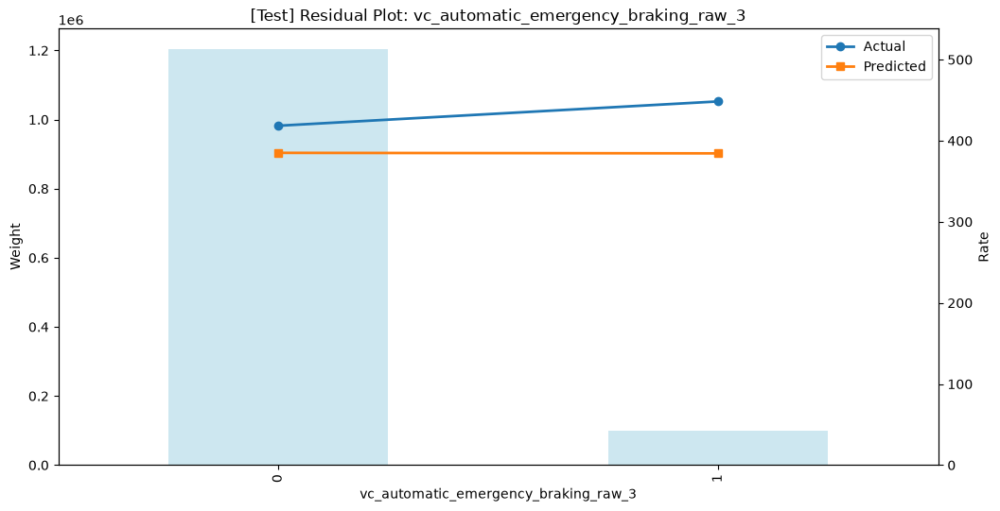

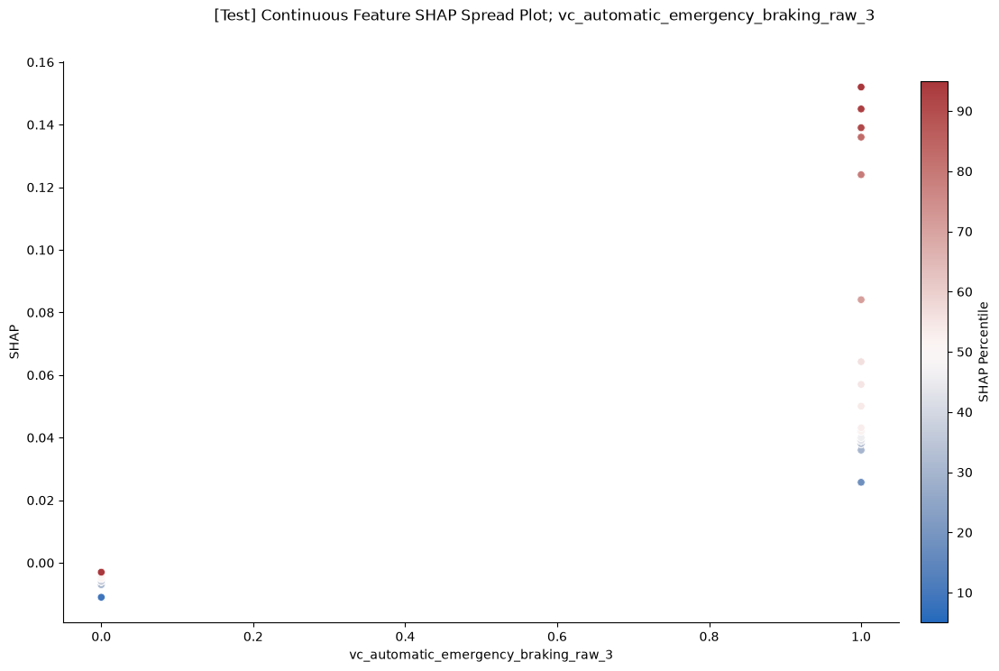


FEATURE: cef_first_sev_prob_ind


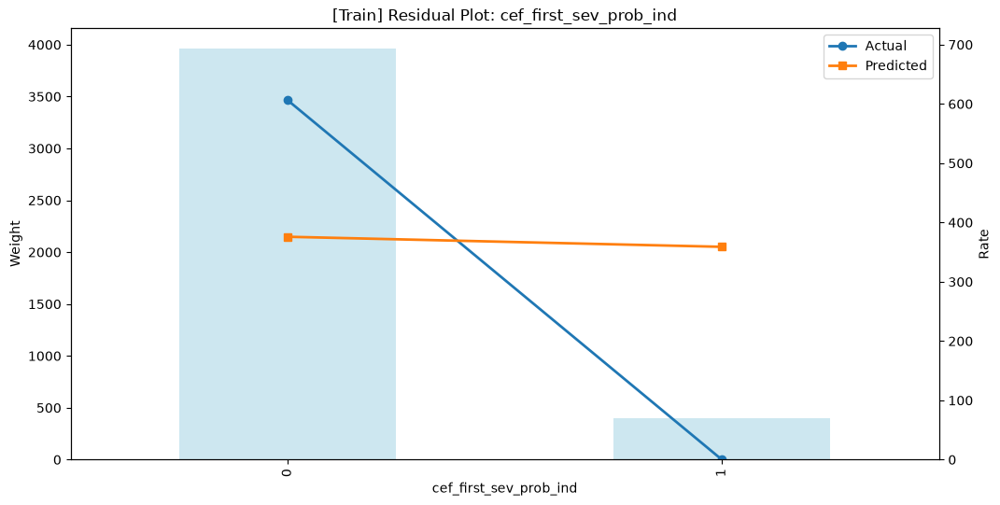

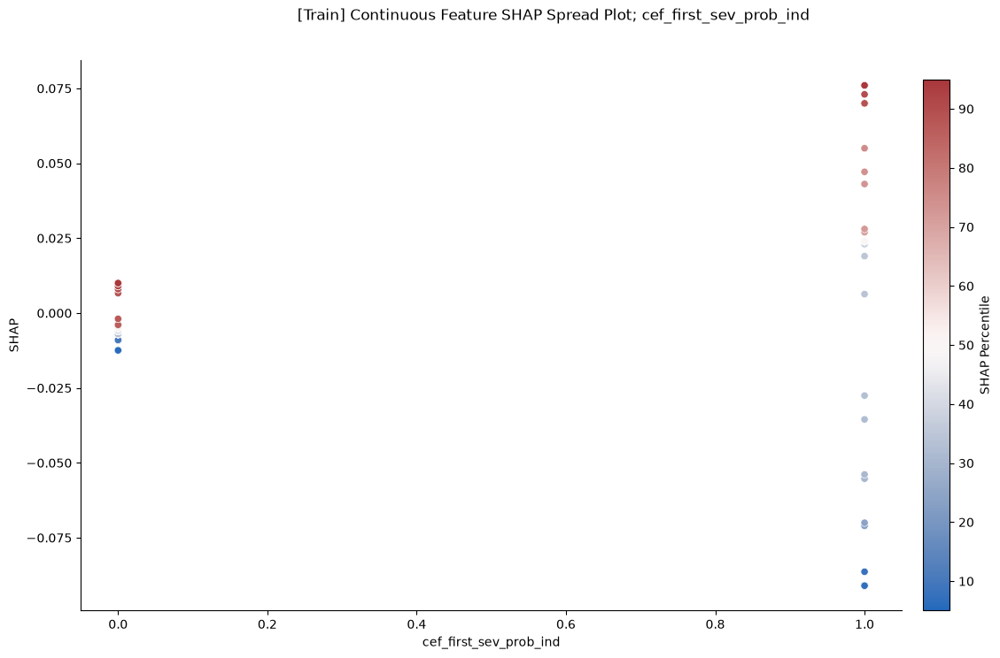

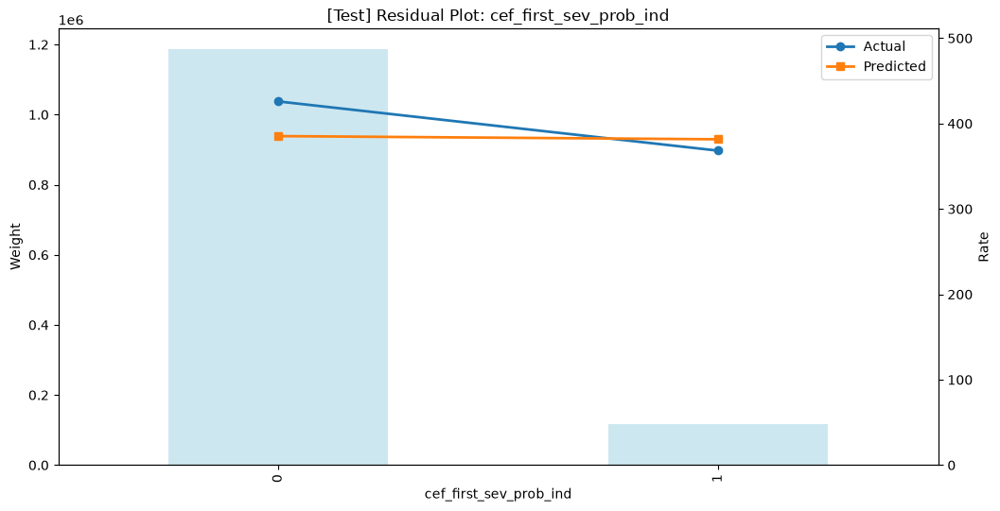

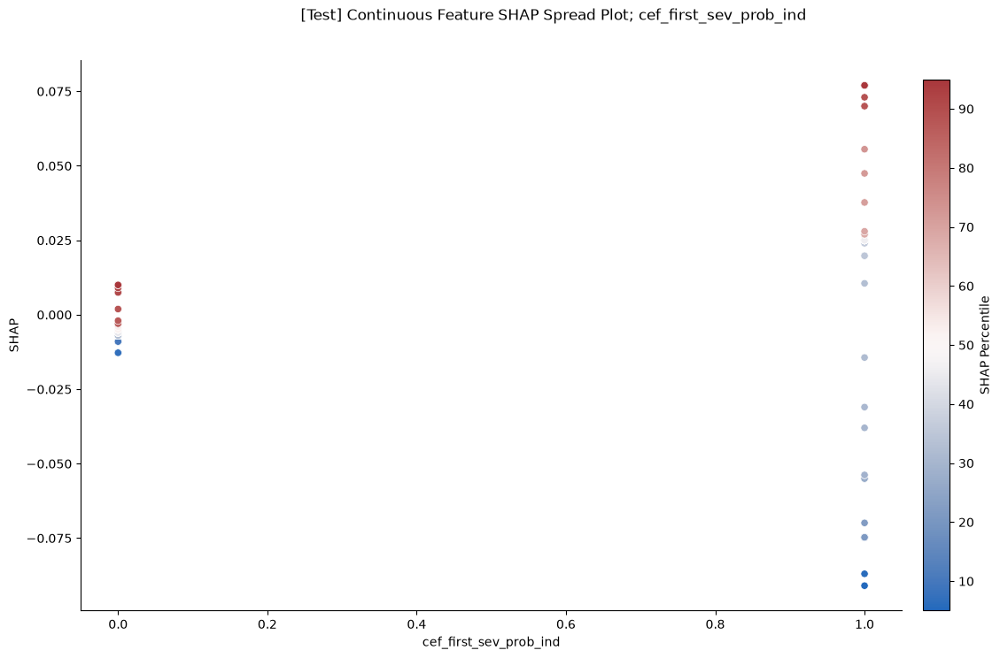


FEATURE: vc_rear_window_defogger_raw


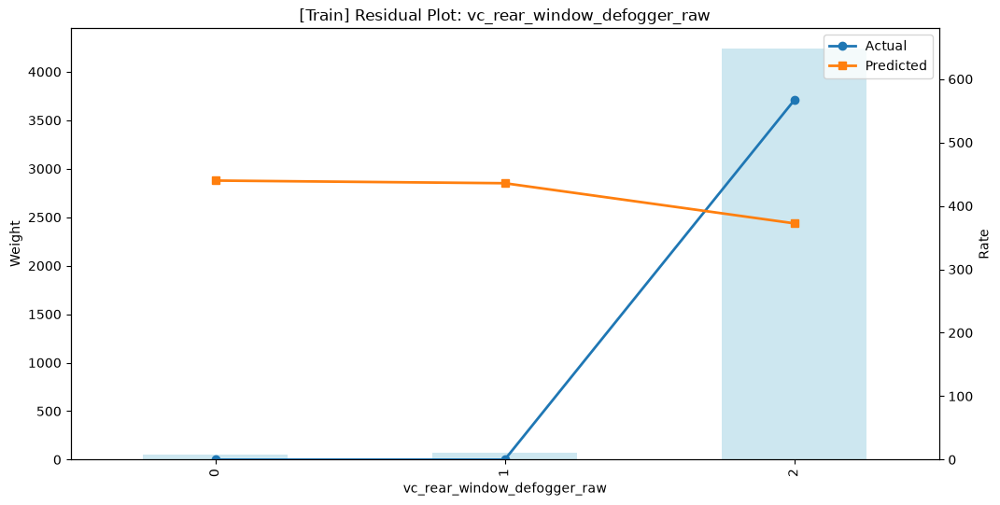

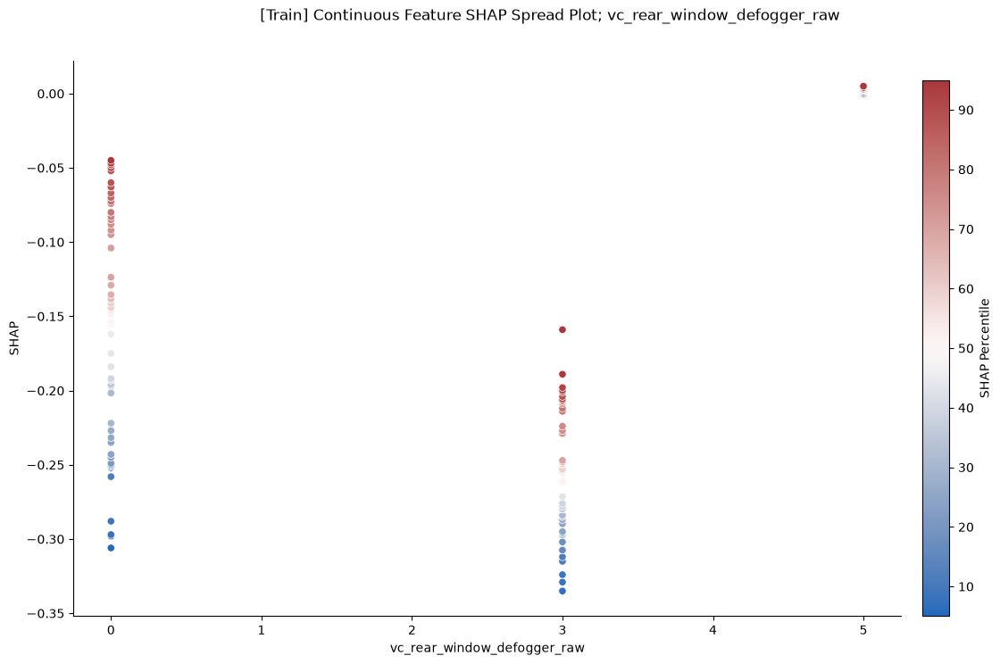

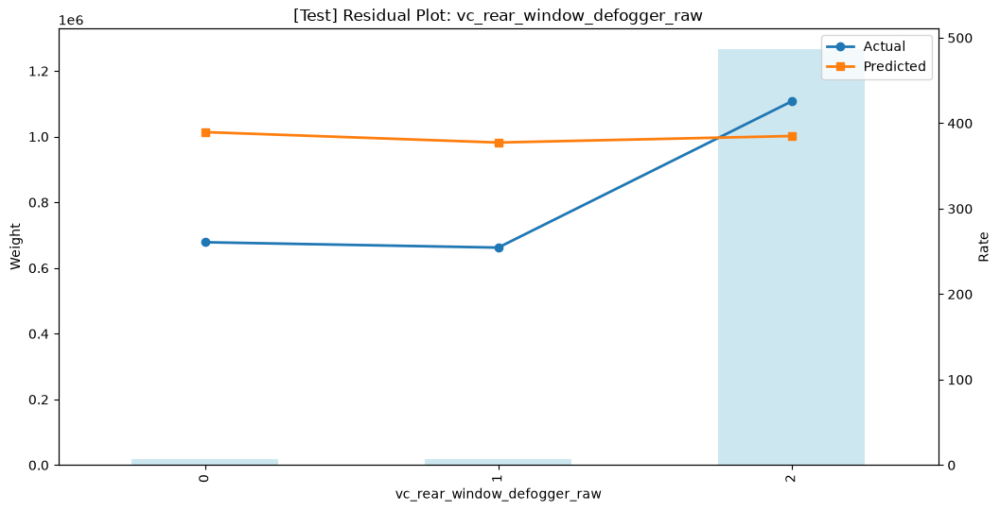

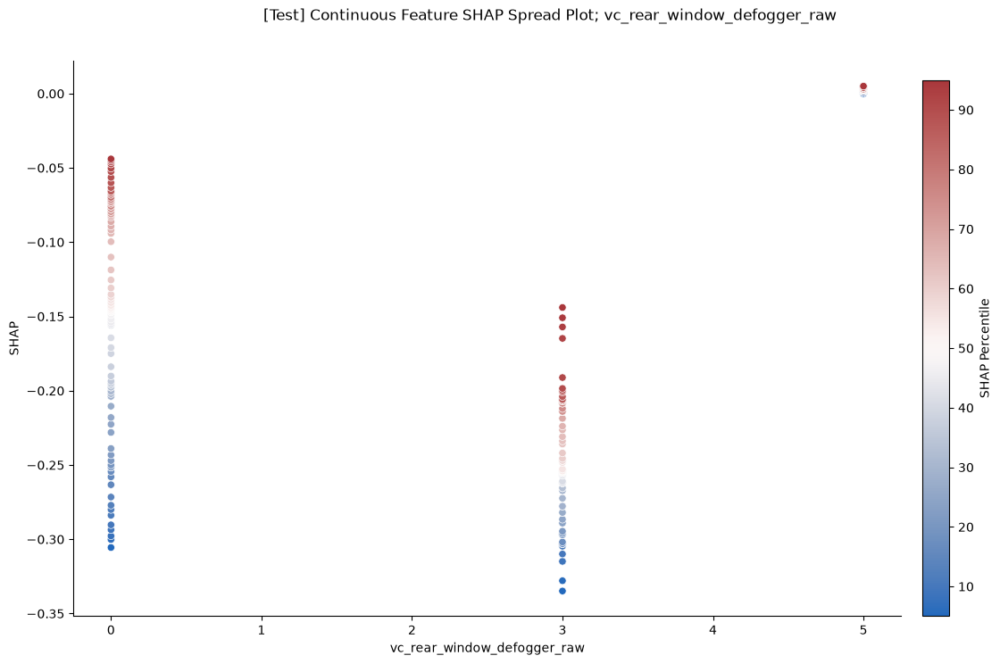


FEATURE: vc_speed_sensitive_volume_raw


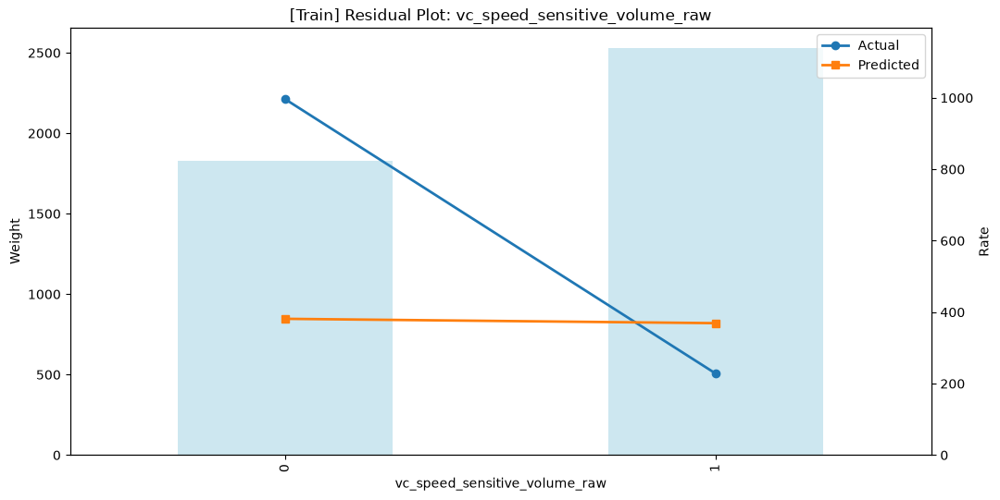

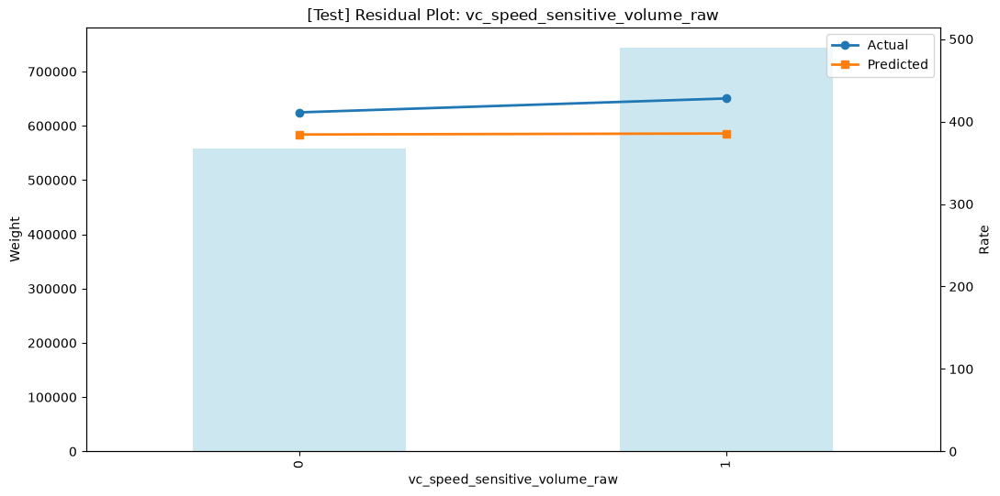


FEATURE: vc_touch_screen_raw_0


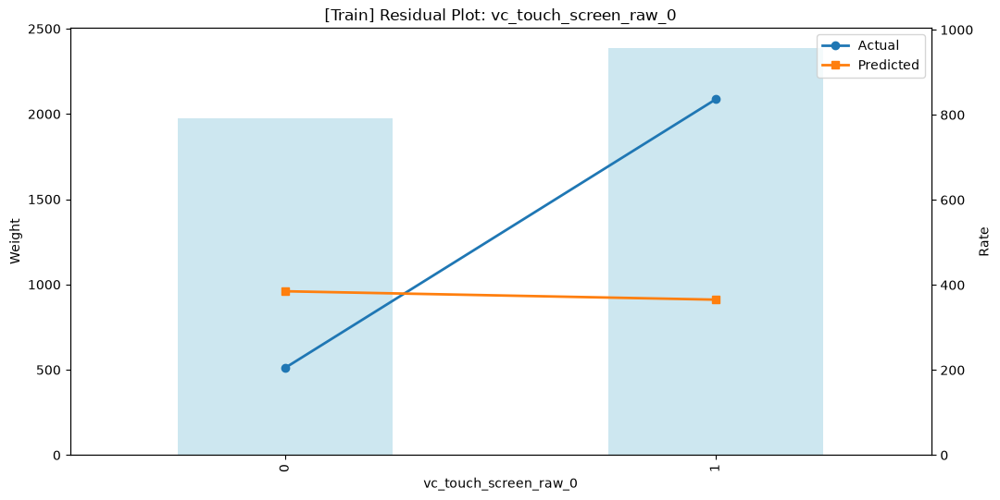

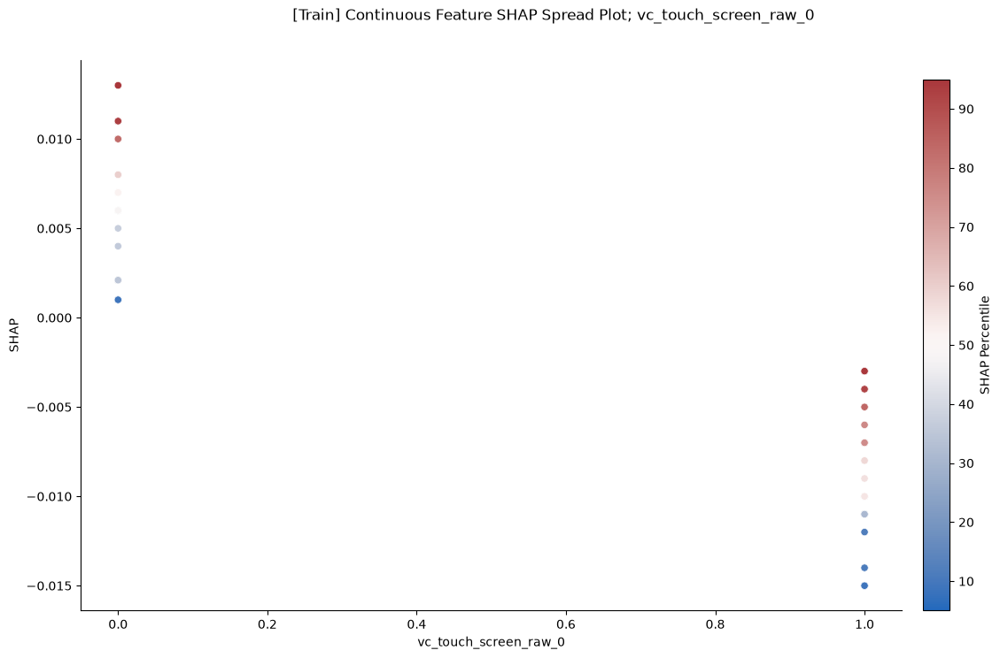

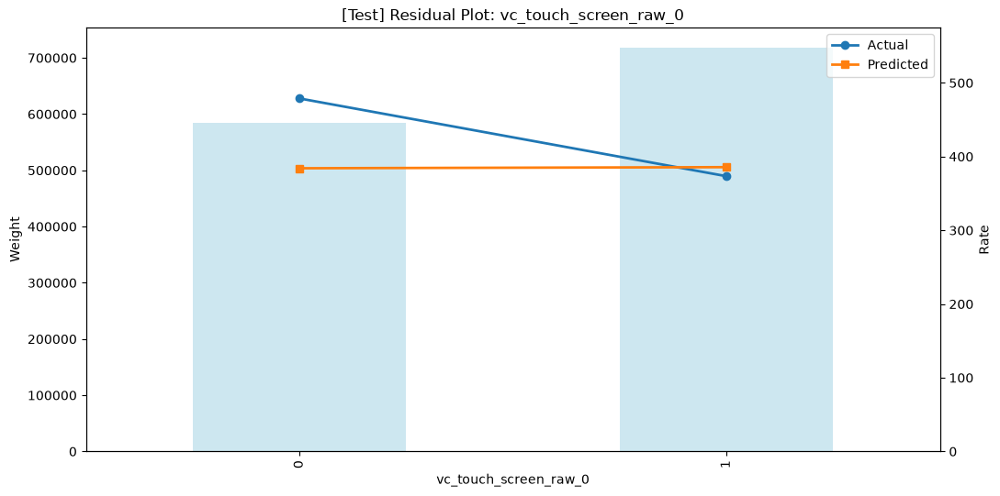

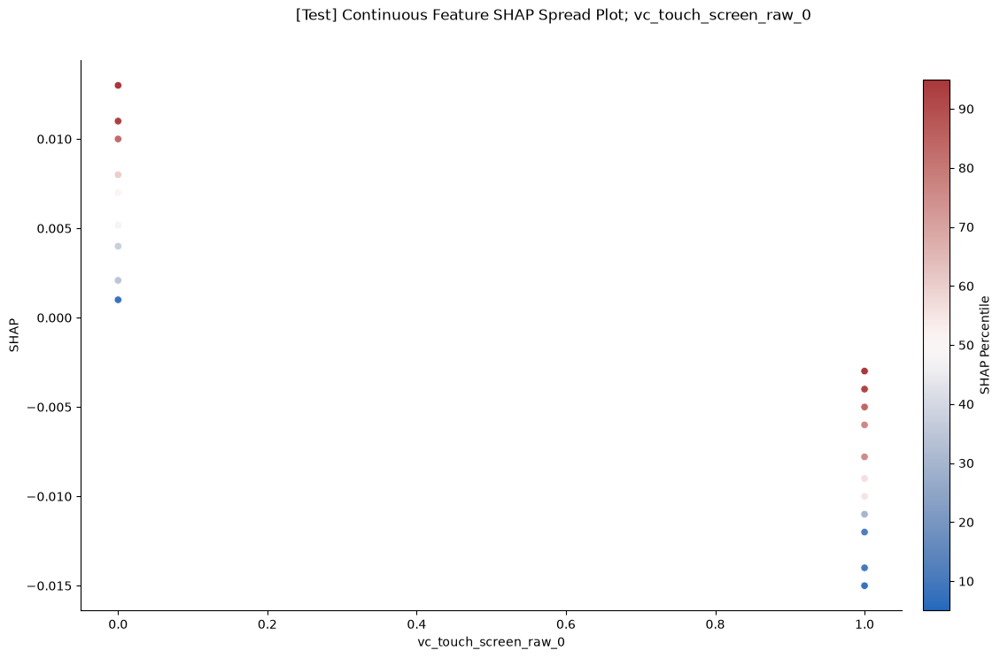


FEATURE: vc_wipers_automatic_raw


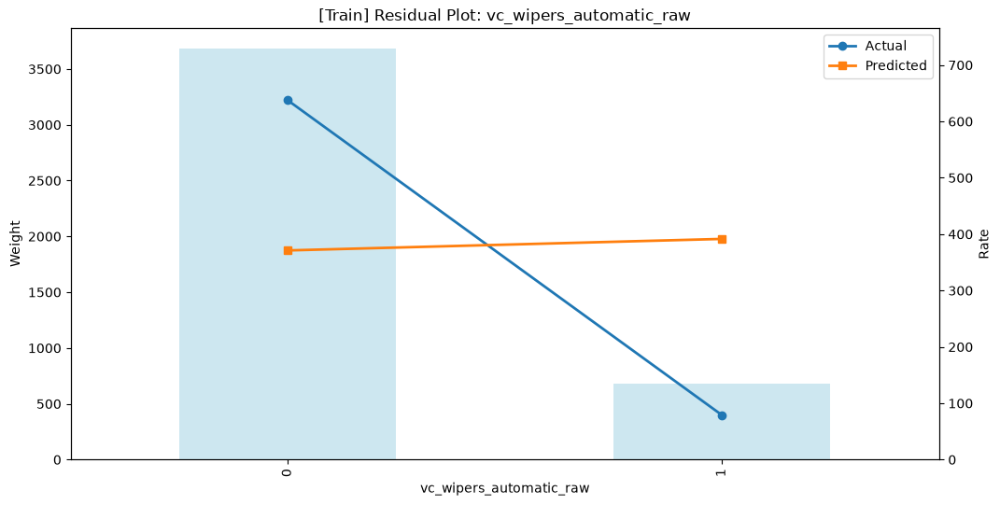

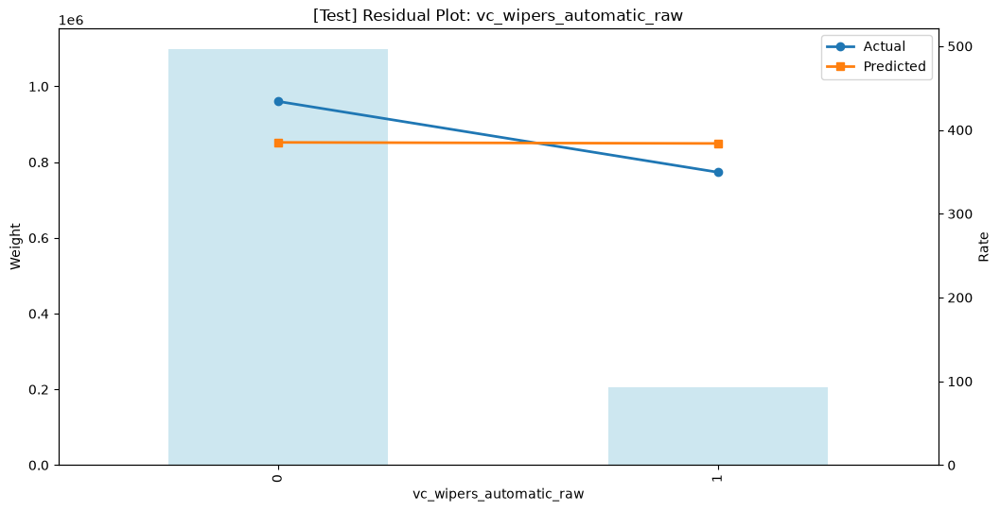


FEATURE: vc_active_driving_assistance_raw_3


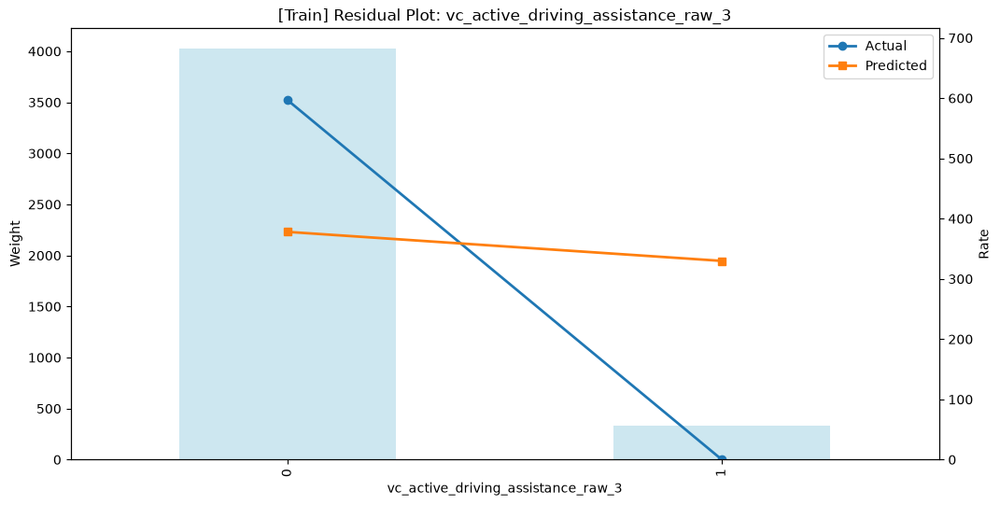

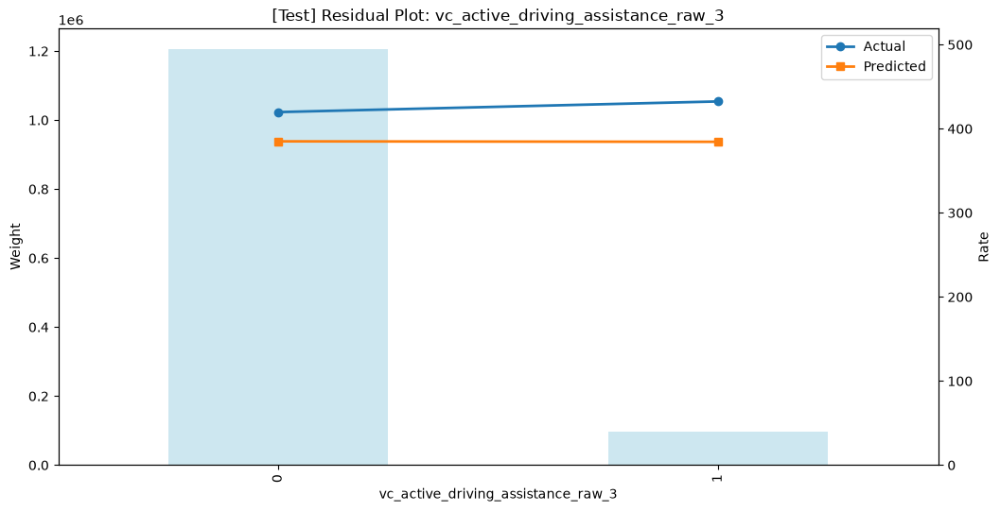


FEATURE: driver_has_acc_any_ind


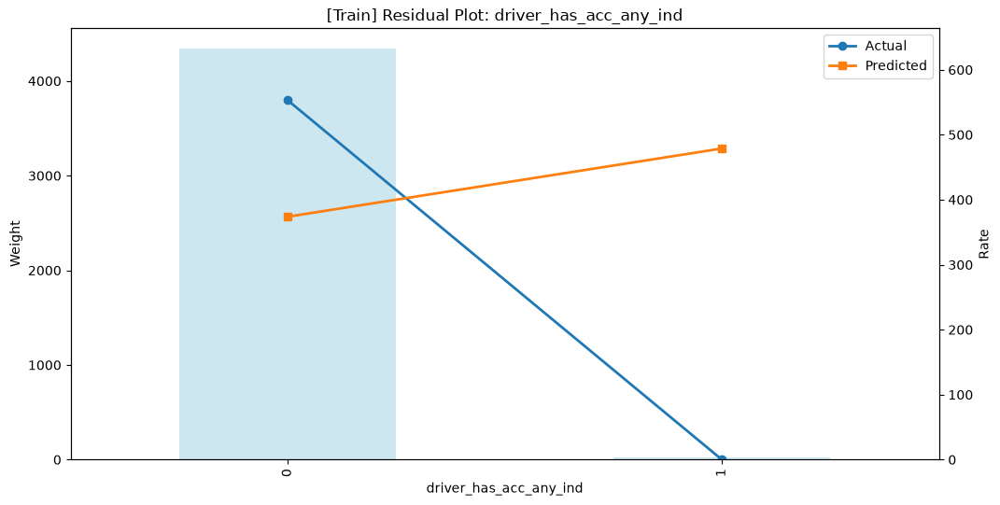

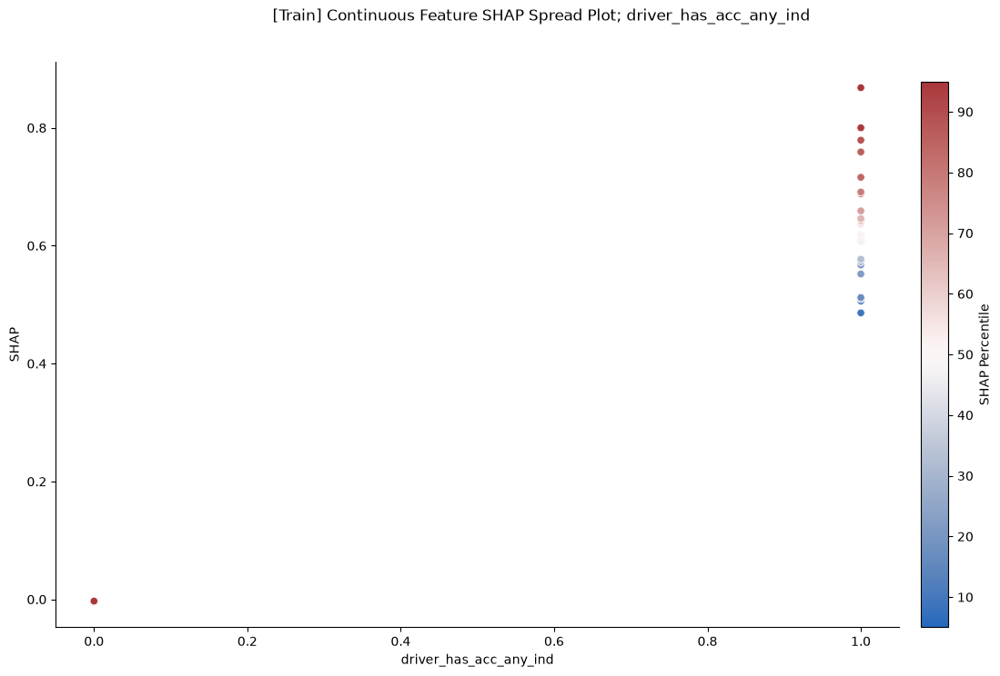

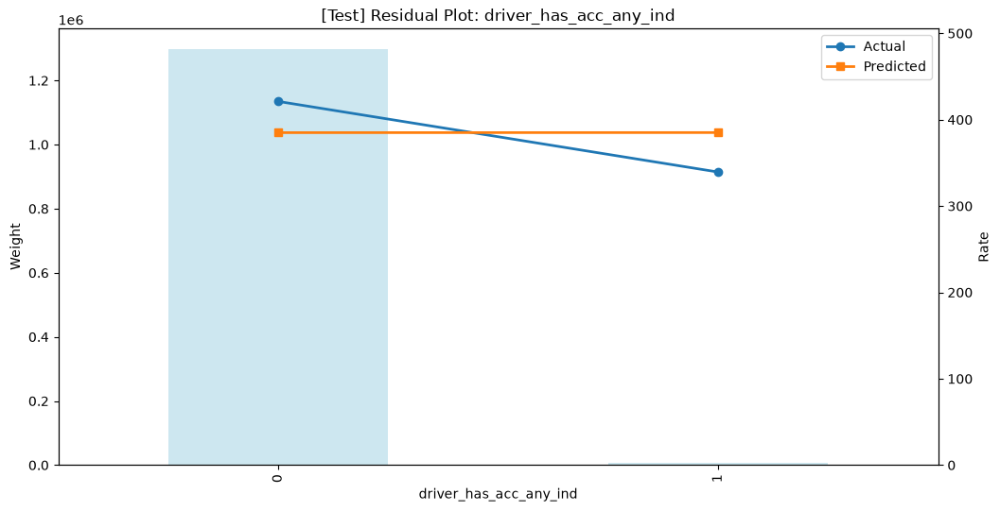

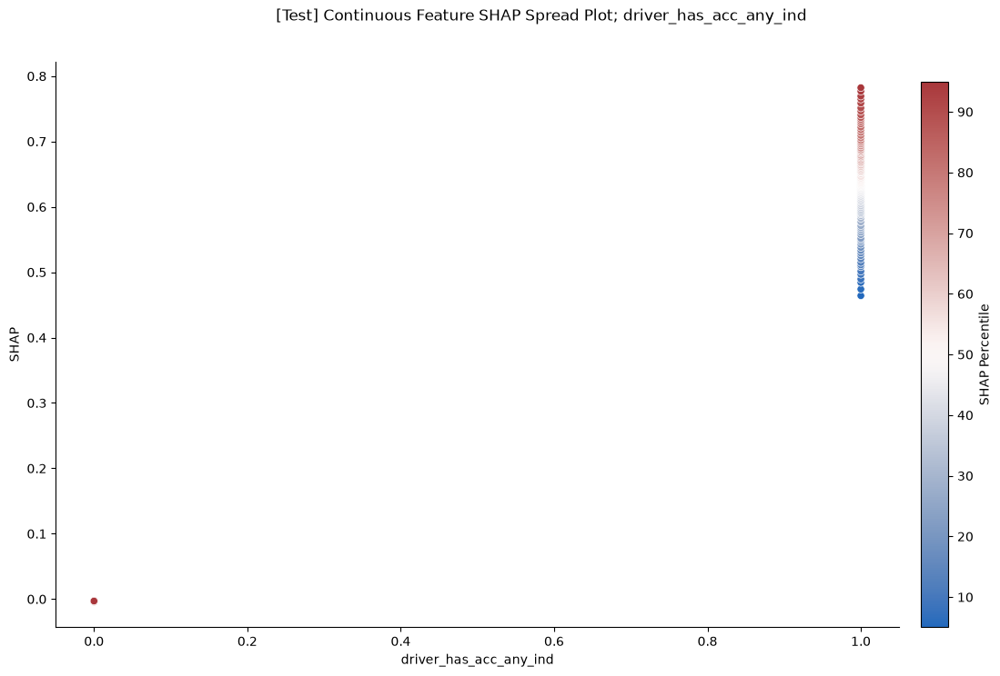


FEATURE: veh_use_business_ind


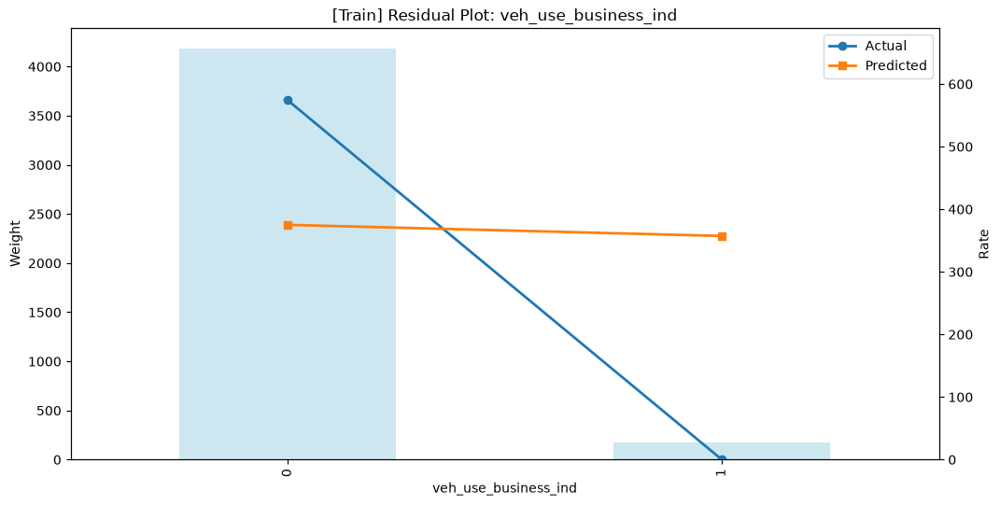

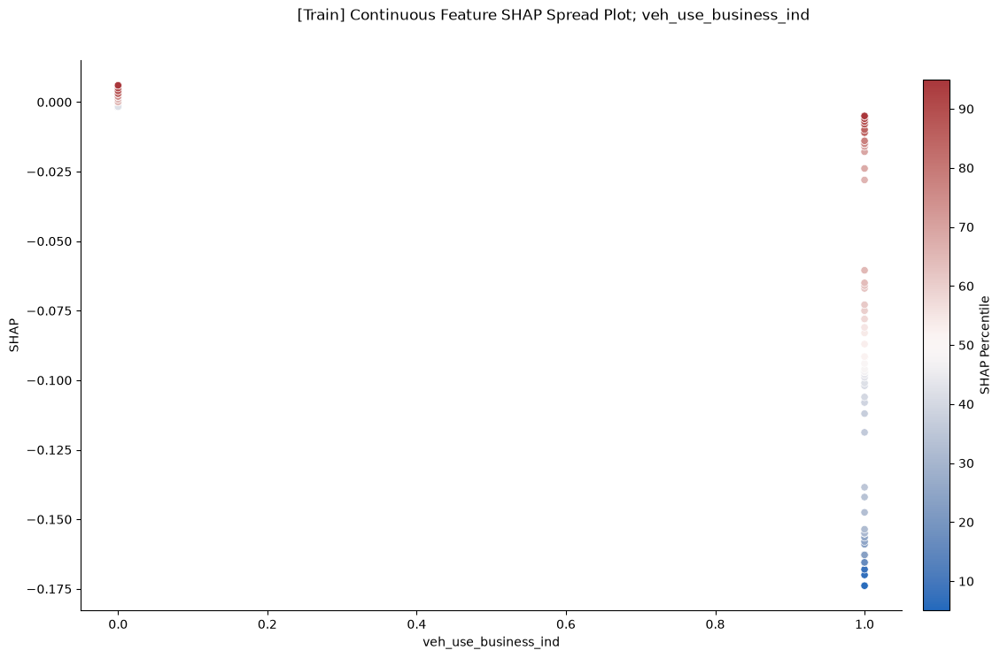

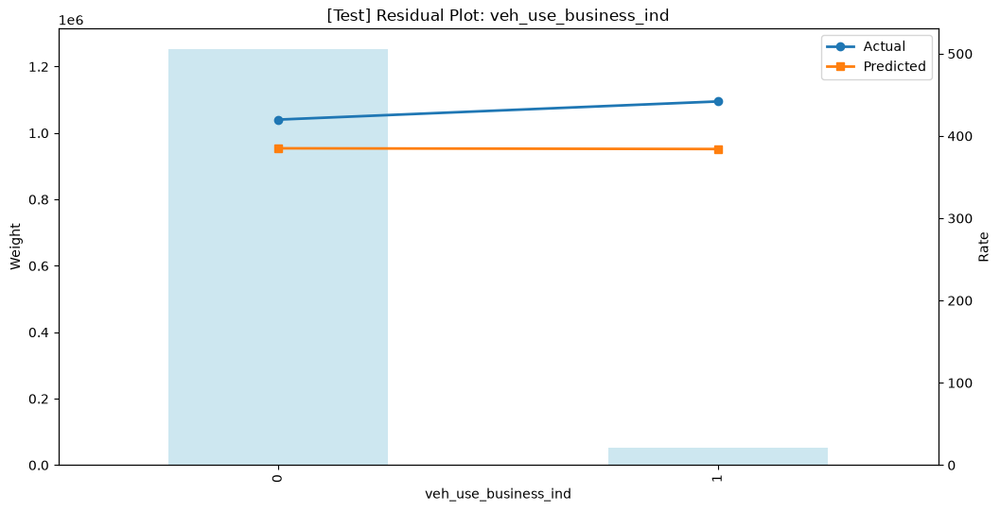

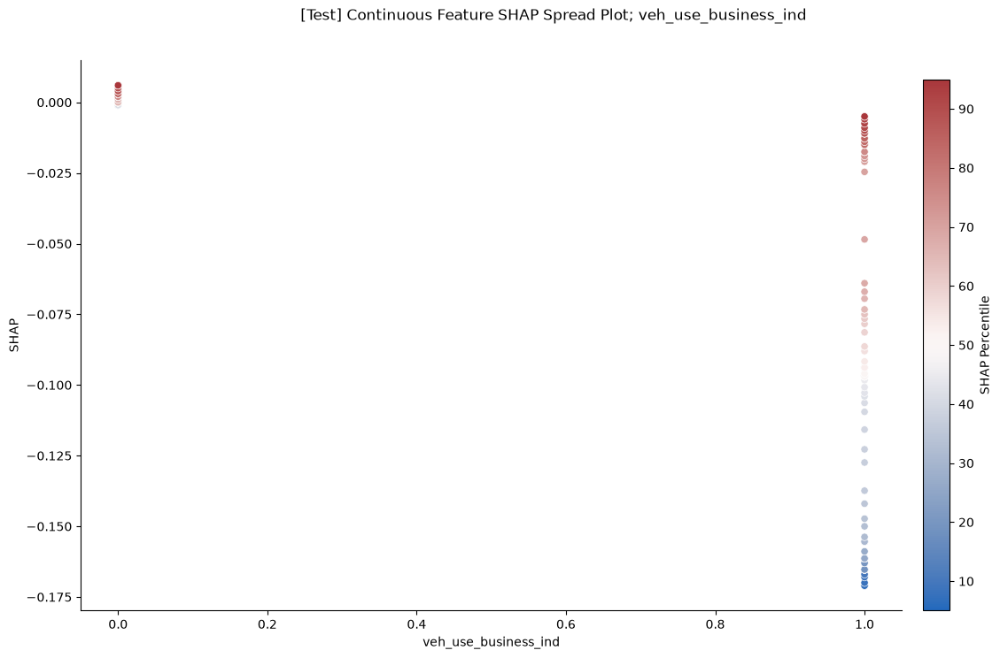


FEATURE: vc_power_folding_side_mirrors_raw


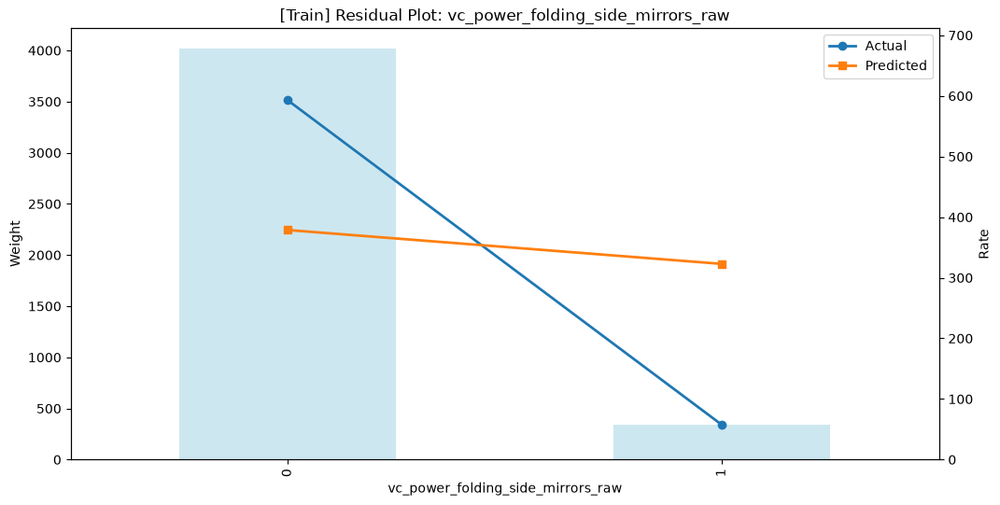

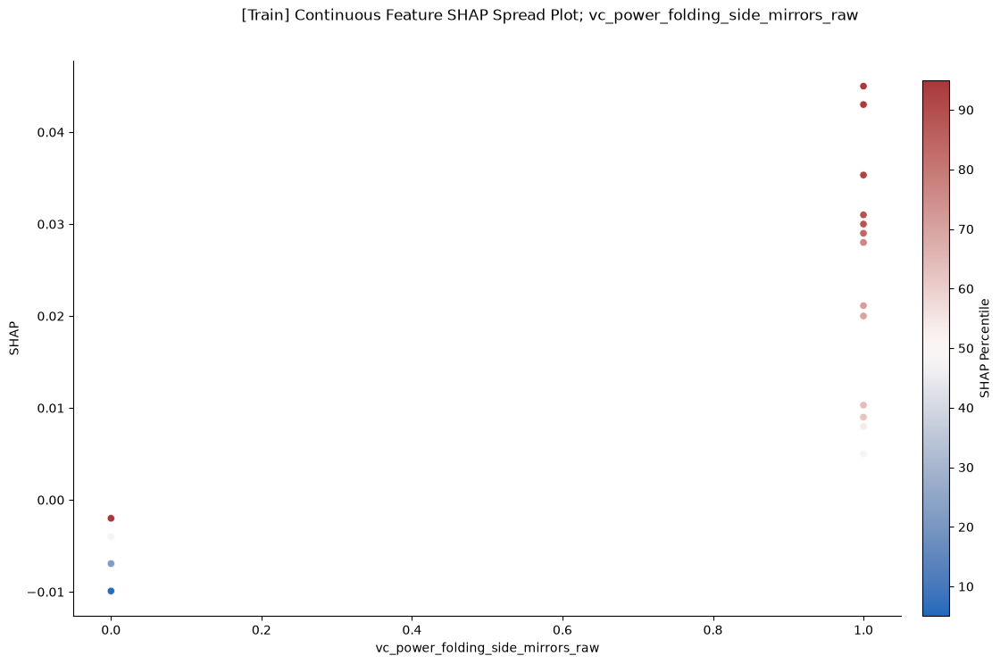

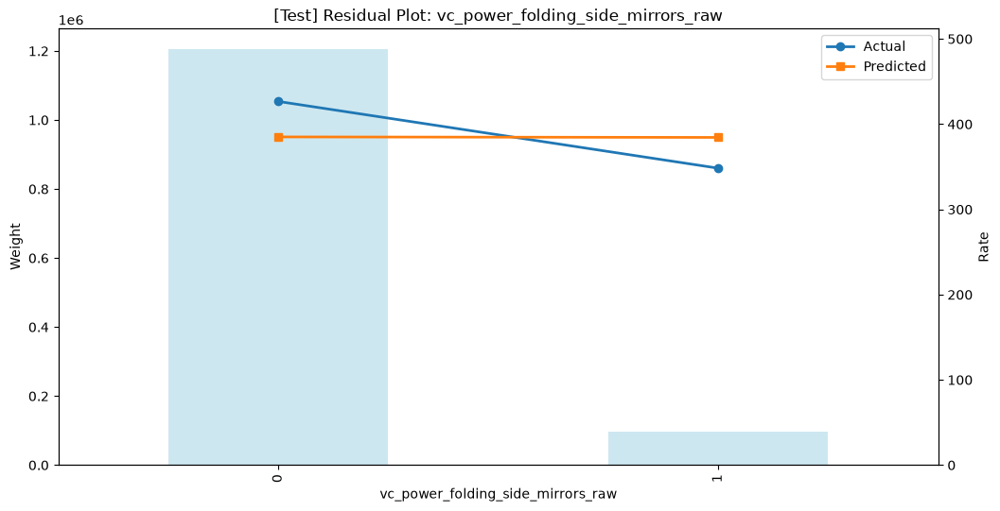

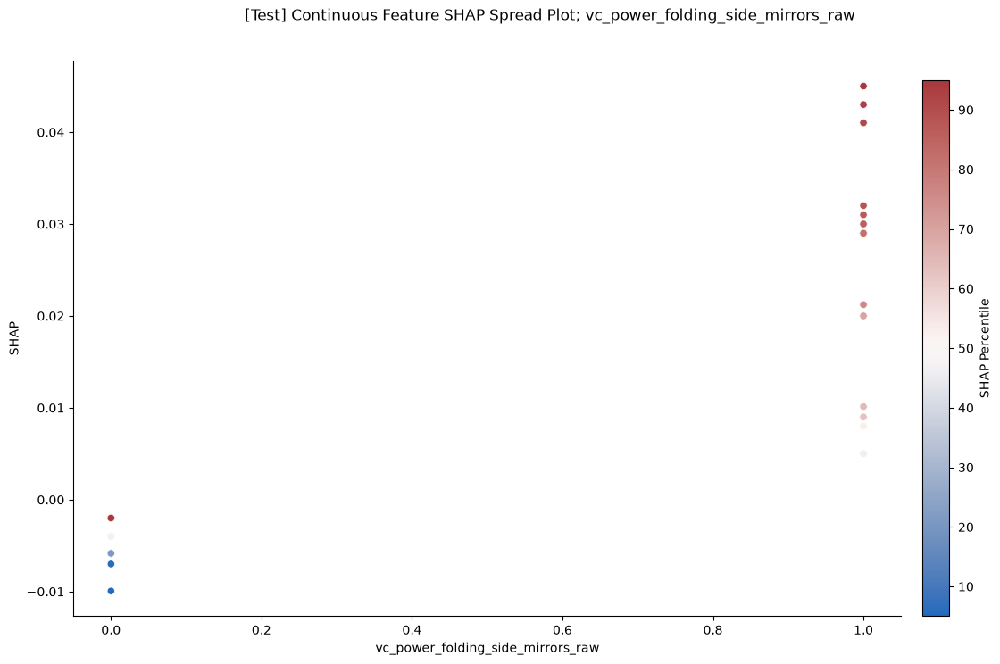


FEATURE: vc_lane_departure_warning_raw


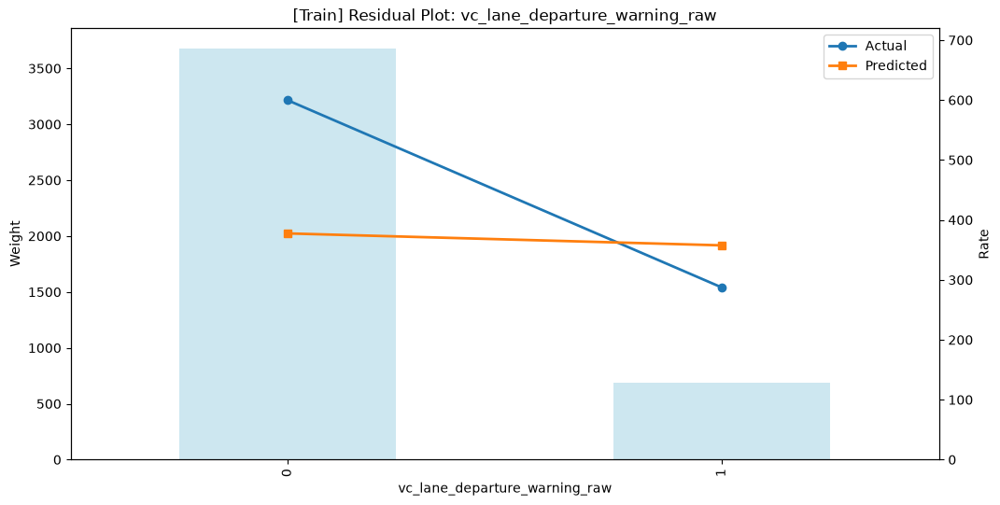

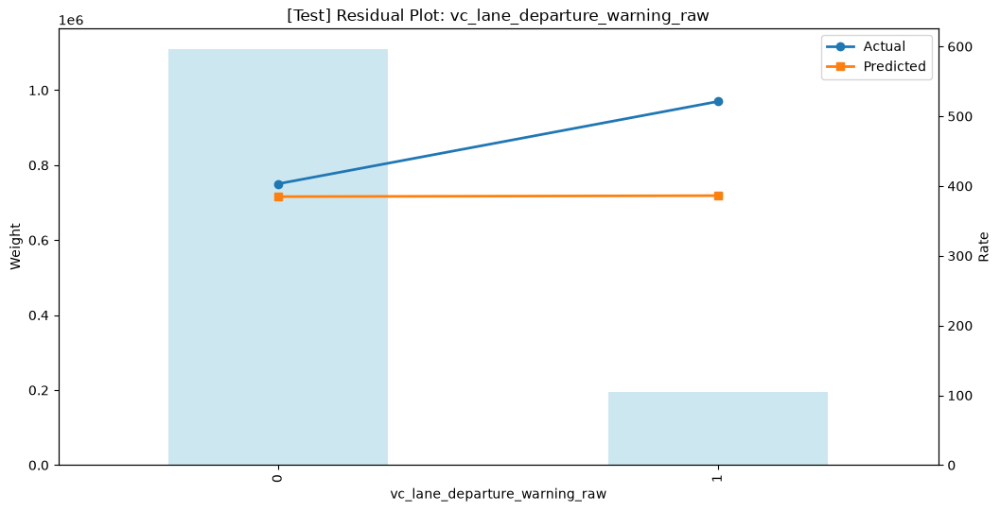


FEATURE: vc_heated_side_mirrors_raw


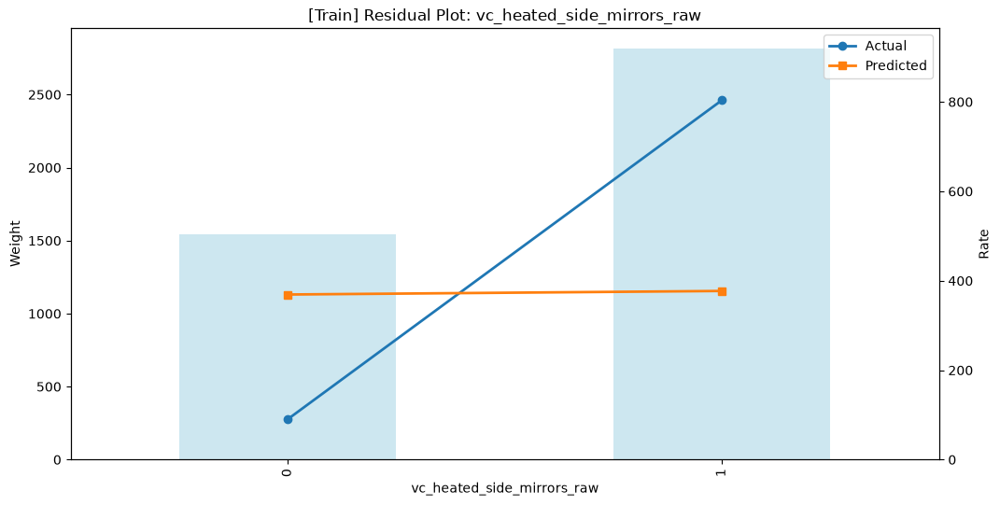

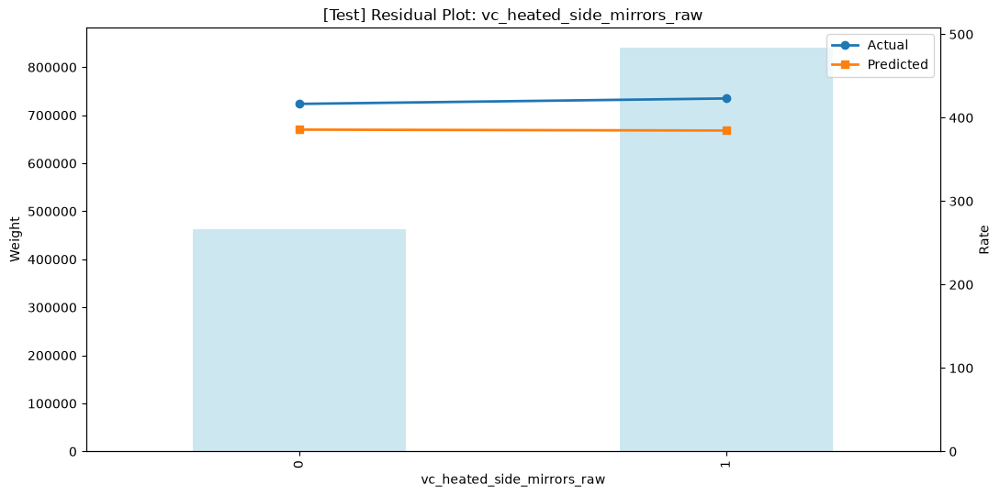


FEATURE: vc_drive_type_rwd_ind


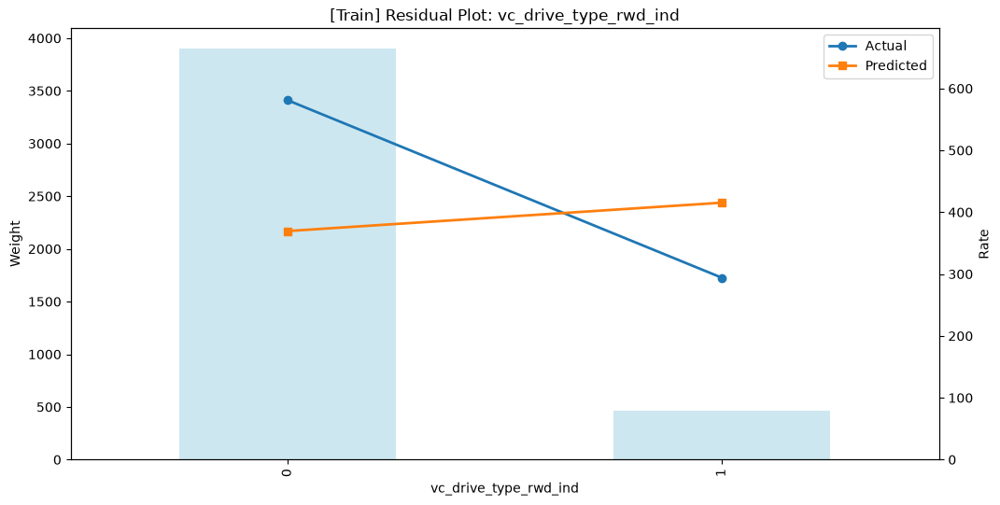

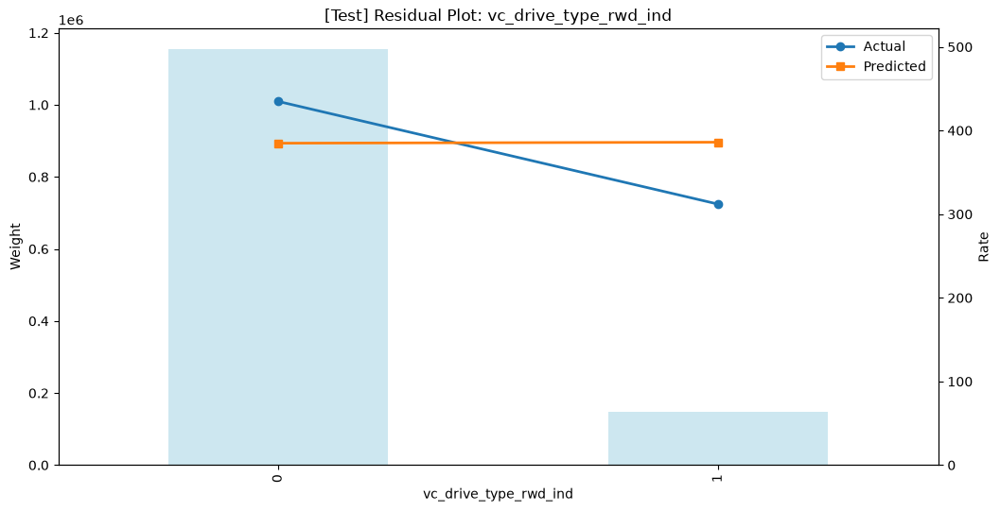


FEATURE: vc_taillights_led_raw


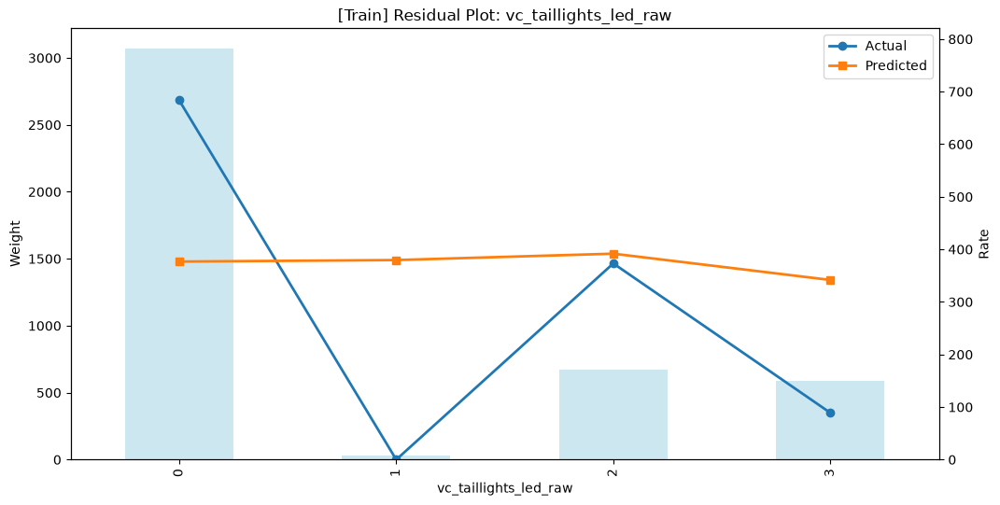

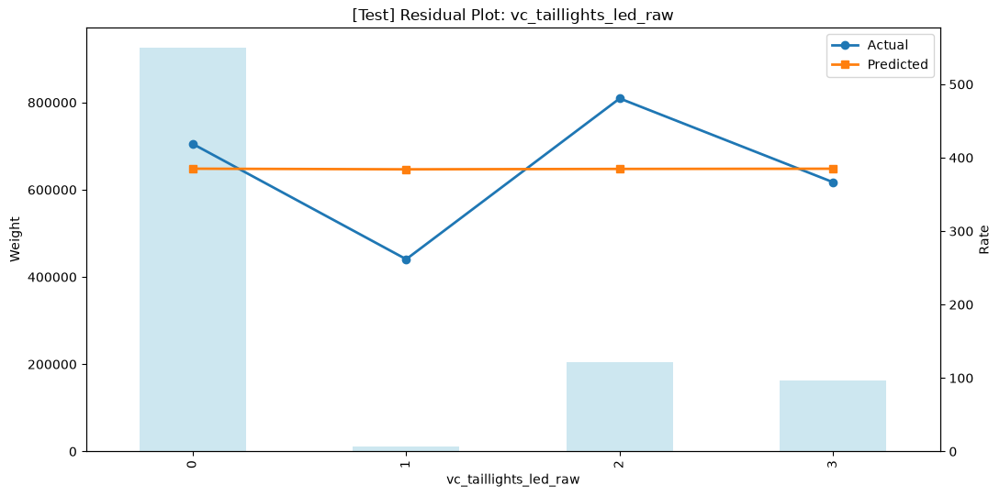


FEATURE: vc_luxury_flag_ind


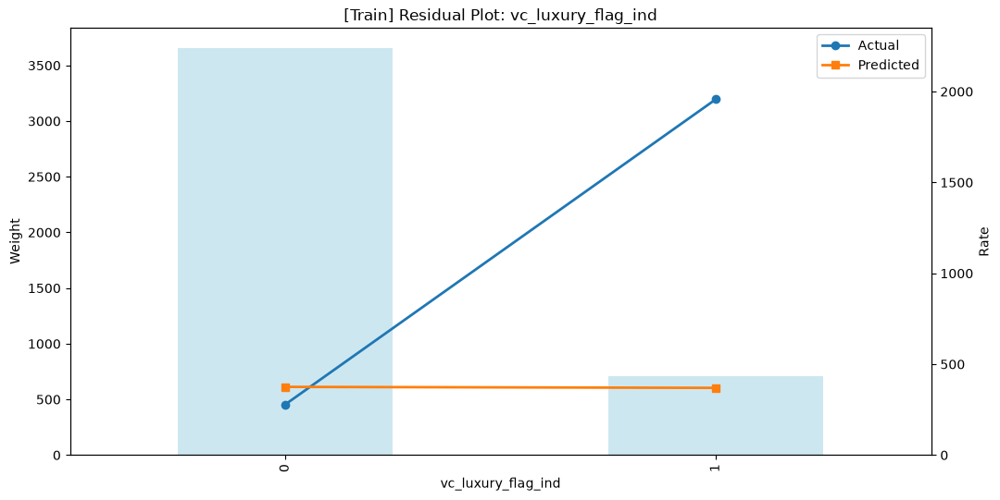

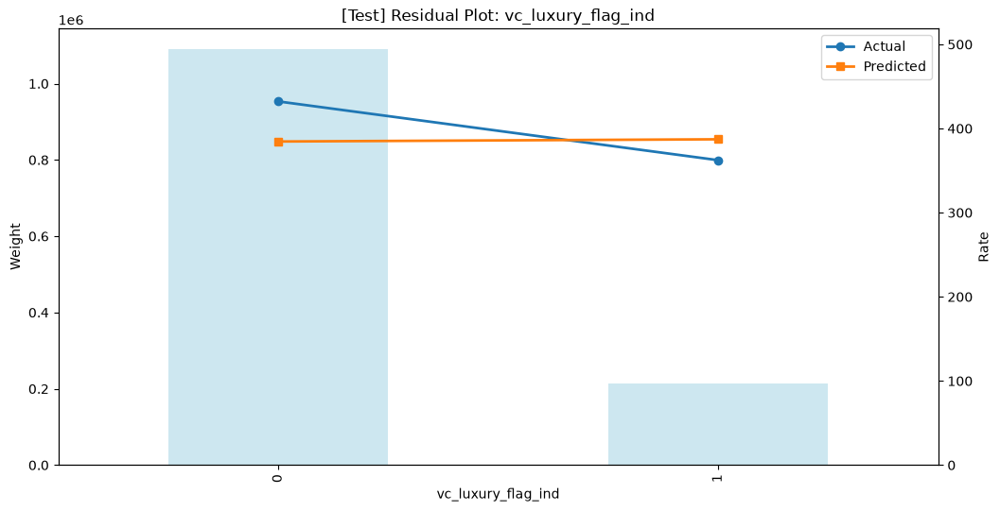


FEATURE: vc_active_collision_avoidance_system_raw_3


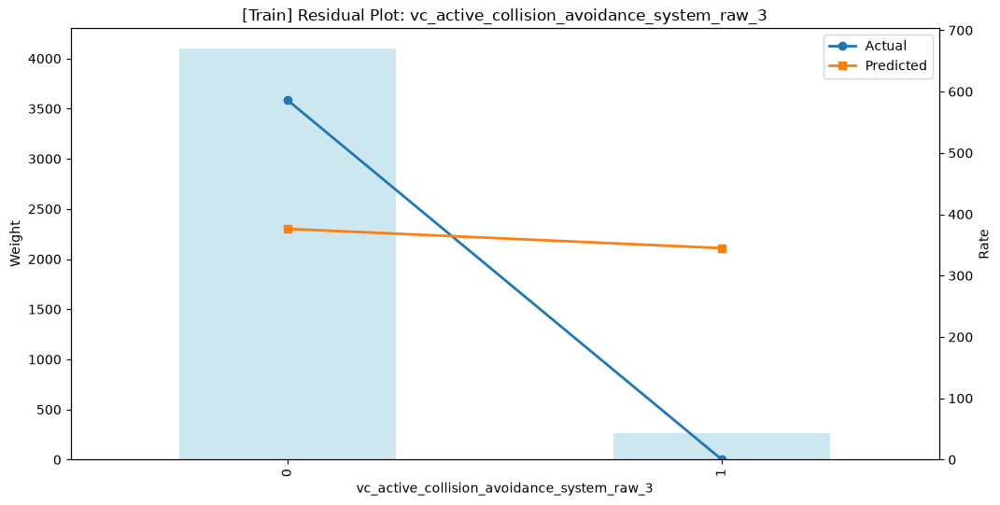

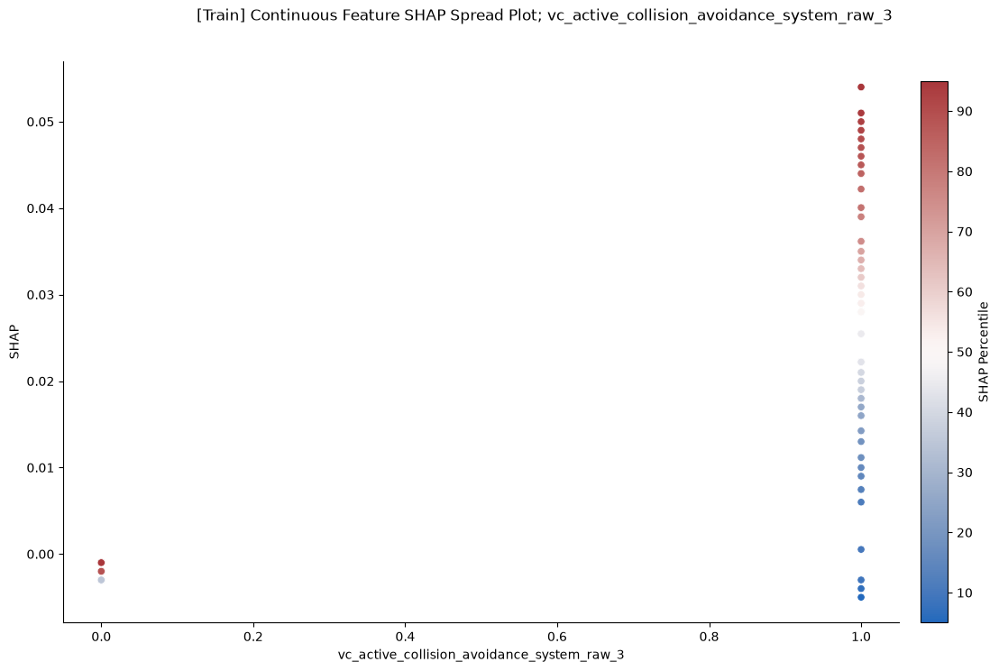

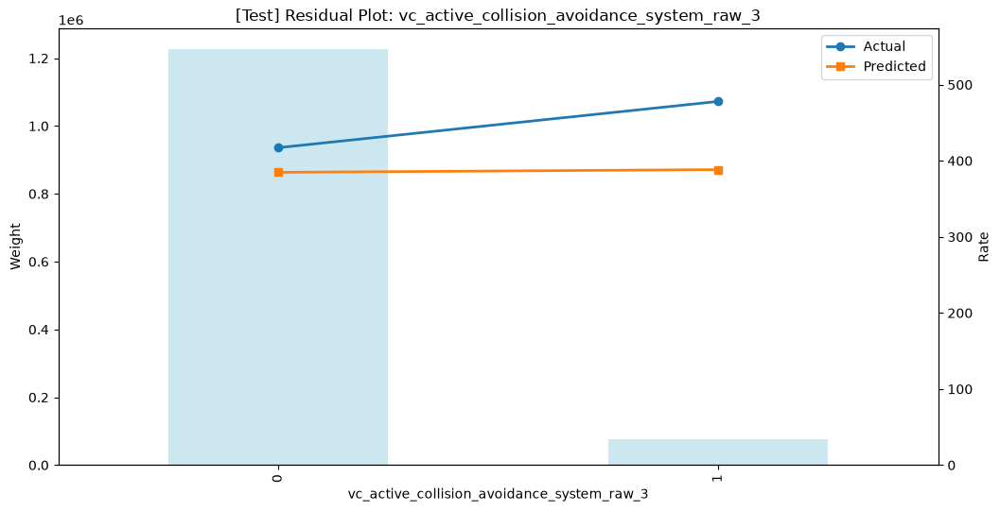

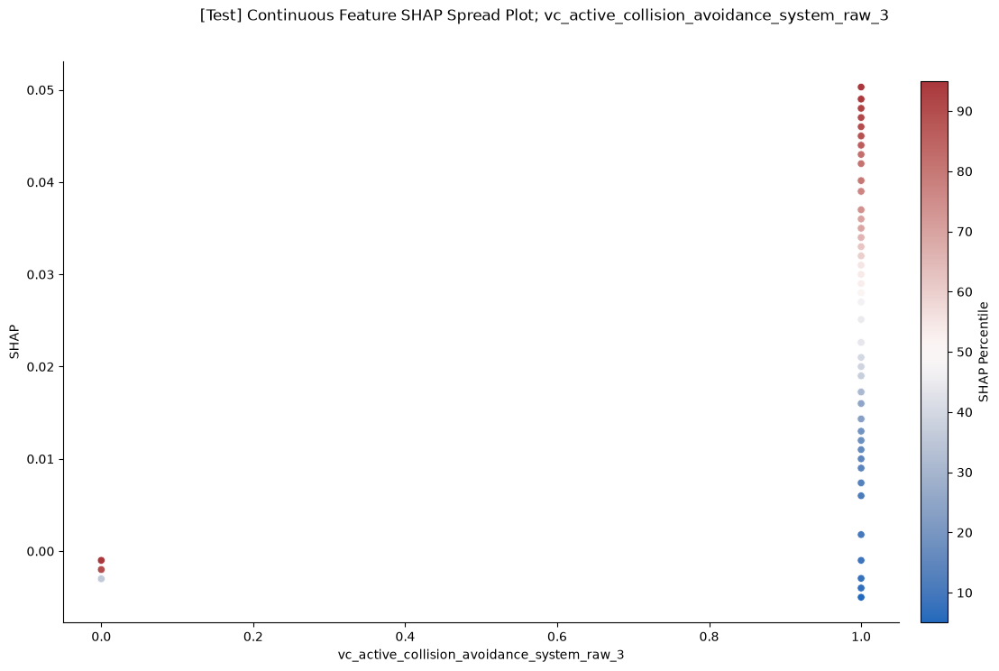


FEATURE: vc_sunroof_raw_0


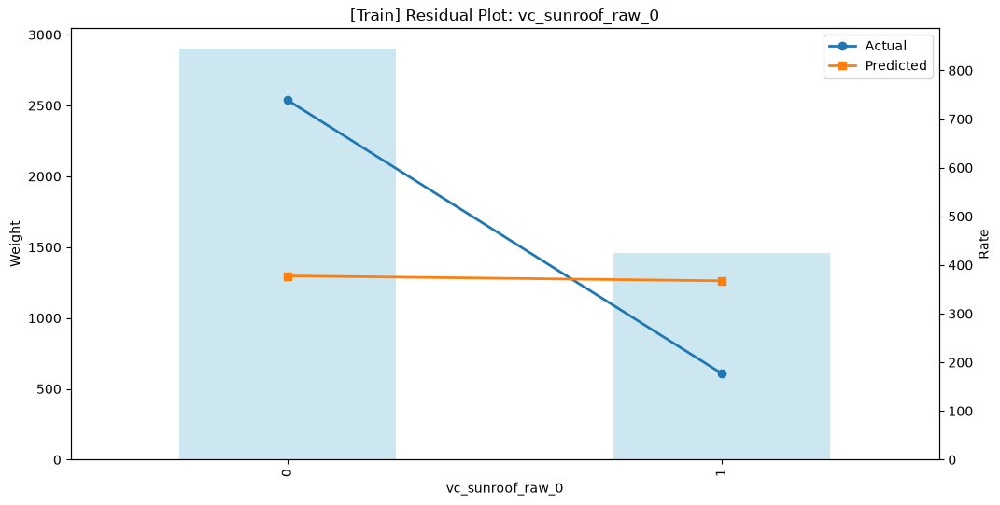

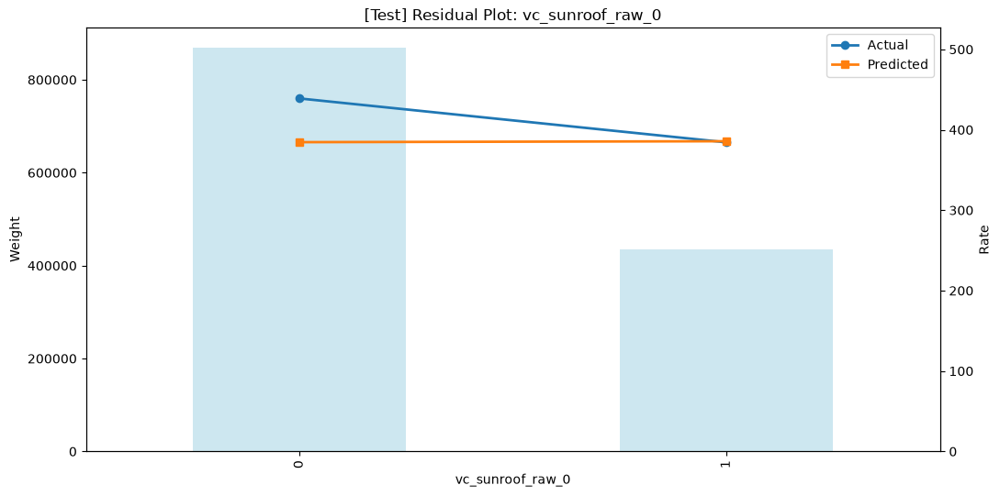


FEATURE: vc_auto_dimming_rearview_mirror_raw_3


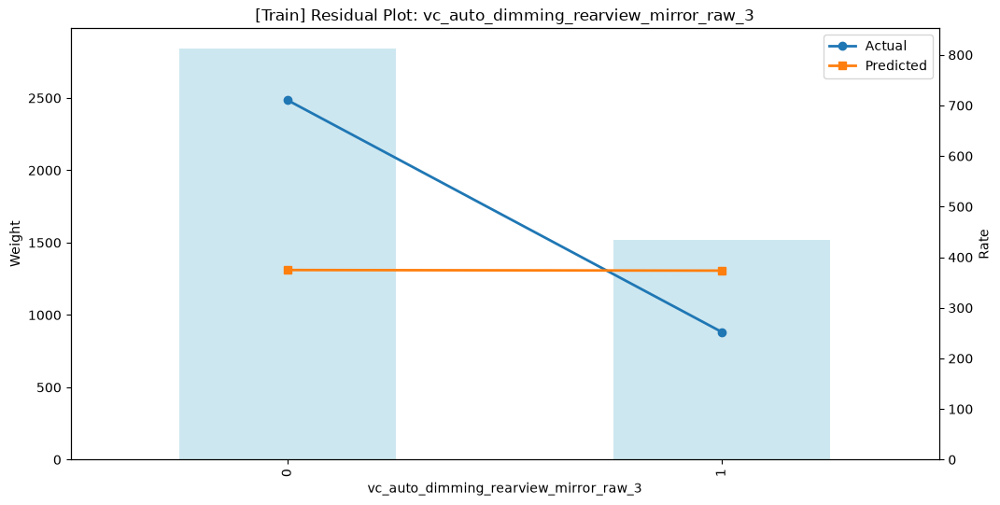

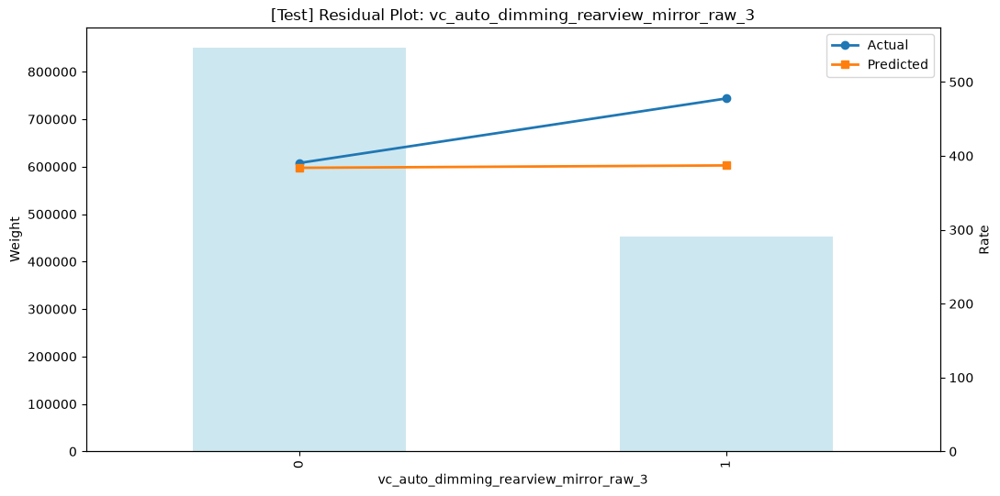


FEATURE: vc_camera_raw_5


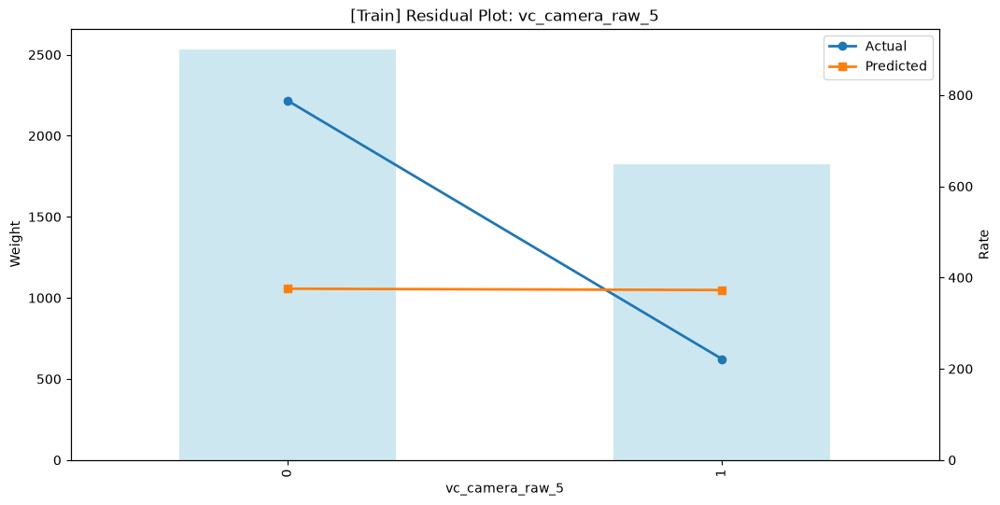

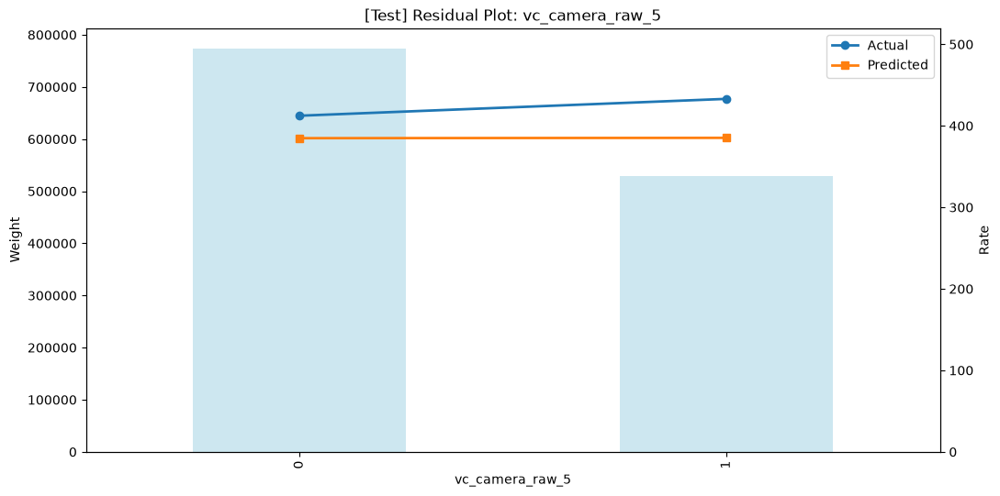


FEATURE: vc_surround_sound_raw_3


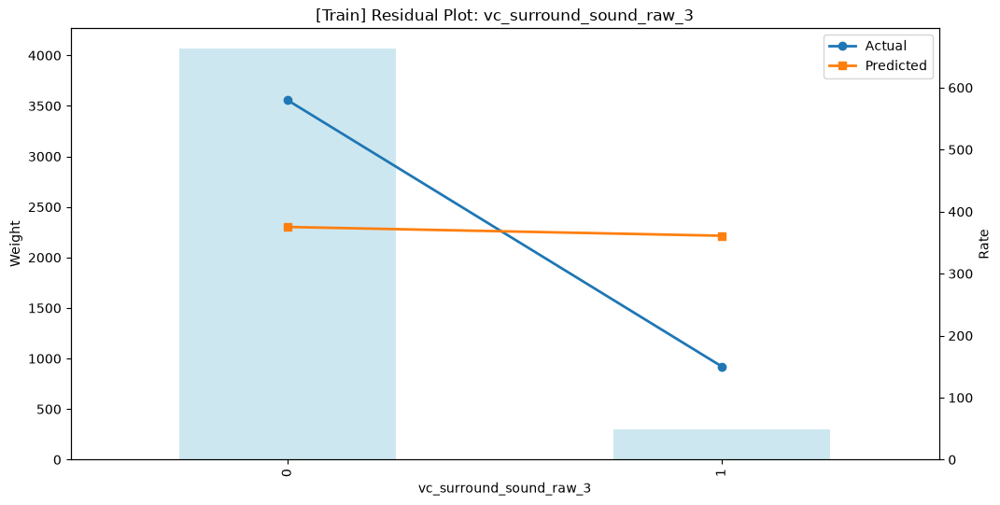

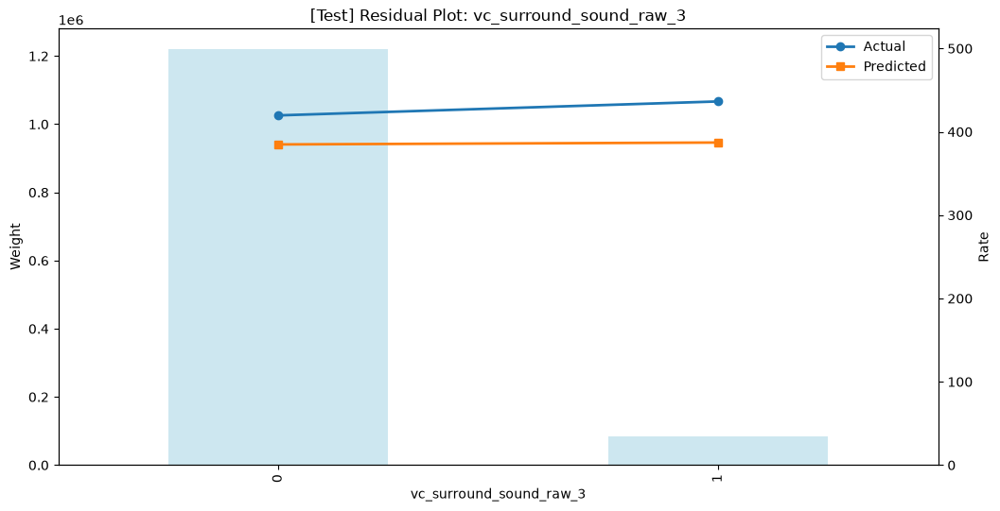


[OK] Displayed 127 plots


In [14]:
from IPython.display import Image, display
print("\n" + "="*60)
print("DISPLAYING ALL PLOTS")
print("="*60)
for f in features:
    if f not in plots_by_feature or not plots_by_feature[f]:
        continue
    print("\n" + "="*60)
    print(f"FEATURE: {f}")
    print("="*60)
    for plot_path in plots_by_feature[f]:
        if Path(plot_path).exists():
            display(Image(filename=plot_path))
        else:
            print(f"WARNING: {plot_path} not found")
print(f"\n[OK] Displayed {sum(len(v) for v in plots_by_feature.values())} plots")

In [15]:
summary["features"] = features
summary["top_n"] = top_n
summary_file = f"{output_base}/results/07_analysis_summary.yaml"
with open(summary_file, "w") as f:
    yaml.dump(summary, f)
print(f"\nSummary: {summary_file}")


Summary: output/car_liab/v1/results/07_analysis_summary.yaml


In [16]:
print("\n" + "#"*40)
print("# STAGE 07: COMPLETE")
print("#"*40)
print(f"Plots: {summary['plots']}")


########################################
# STAGE 07: COMPLETE
########################################
Plots: 127
